# DeiT-Small (patch 16, 224 px, ImageNet-1k) — DIMER image classification and bounded fine-tuning (standalone)

[![GitHub](https://img.shields.io/badge/GitHub-181717?style=flat&logo=github&logoColor=white)](https://github.com/kurtvalcorza/deit-classification-pipeline) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kurtvalcorza/deit-classification-pipeline/blob/main/tutorials/deit_classification_colab.ipynb) [![Hugging Face](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-facebook%2Fdeit--small--patch16--224-ffcc4d?style=flat)](https://huggingface.co/facebook/deit-small-patch16-224) [![Upstream](https://img.shields.io/badge/Upstream-facebookresearch%2Fdeit-181717?style=flat&logo=github&logoColor=white)](https://github.com/facebookresearch/deit) [![arXiv](https://img.shields.io/badge/arXiv-2012.12877-b31b1b.svg)](https://arxiv.org/abs/2012.12877) [![License](https://img.shields.io/badge/License-Apache--2.0-green.svg)](https://github.com/kurtvalcorza/deit-classification-pipeline/blob/main/LICENSE)

**Profile:** `E2E`  
**Mode:** `GUIDED`  
**Notebook specification:** DIMER Notebook Specification 2.2 — **standalone** (§4)  
**Capability:** ImageNet-1k image classification with DeiT-Small, a data-efficient Vision Transformer, and a bounded fine-tune that replaces the 1000-class head with one for your own classes, compares it on a held-out split with the majority-class and zero-shot ImageNet baselines, and exports a reloadable SafeTensors adapter

**This notebook is standalone.** It carries the repository's package (2 modules under `src/deit_classification_pipeline/`, at revision `cf8aa0da5a5f`) verbatim in Section 2, the pinned model identity and the per-file SHA-256 manifest in Section 3, and the exact runtime pins in Section 1, so it keeps working after export even if the repository changes or disappears. Its only external dependencies are the pinned Python distributions and the Hugging Face Hub at the immutable revision `164deee347853469b97442b3817f22eece80c7e3` (~88 MB, digest-verified before loading). It was generated by `tools/build_notebook.py` (build_notebook.py/2.1); edit the repository and regenerate rather than editing cells.

**Run all:** Selecting **Run all** in a fresh supported runtime builds an isolated environment from the hash-locked pins (the kernel's own packages are left alone, so no restart is needed), stages and digest-verifies the pinned checkpoint, downloads and digest-verifies the pinned CIFAR-10 subset, validates it, groups its duplicate images and splits it by group, measures the majority-class and zero-shot ImageNet baselines, probes the model with a blank and a noise image, **runs the bounded fine-tune**, evaluates the held-out split, classifies an unseen split, exports the adapter, reloads it onto a fresh base model to verify the predictions, and writes machine-readable outputs with provenance. Nothing is skipped behind a default-off flag, and no clone, DIMER worker, credential, upload dialog or configuration edit is required (NOTEBOOK_SPEC 2.2 §5, RUN7, FT2). CUDA is used when present; a GPU runtime is recommended. Measured times are listed under Prerequisites.

**Bring Your Own Data:** Two optional BYOD branches are included, and both are off by default (`USE_BYOD_IMAGE = False`, `USE_BYOD_DATASET = False`). `USE_BYOD_IMAGE` runs your own image through the same validation, ImageNet prediction and evaluation-report stages as the sample. `USE_BYOD_DATASET` takes your own class folders through the full adaptation workflow — validate, group duplicates, split by group, baselines, fine-tune, evaluate, export, reload and compare — under NOTEBOOK_SPEC 2.2 DAT14, and writes its own result JSON and predictions CSV. Set `BYOD_IMAGE_PATH` or `BYOD_DATASET_PATH` (a directory or a `.zip`) to read from a location without an upload dialog (EXE2).

DeiT-Small is a Vision Transformer (ViT) of 22M parameters trained on ImageNet-1k alone with the data-efficient recipe of Touvron et al. The image is cut into 16×16-pixel patches; each patch is linearly embedded, a `[CLS]` token and position embeddings are added, and 12 transformer layers of width 384 with 6 attention heads process the 197-token sequence. A linear head on the final `[CLS]` token outputs a softmax over the 1000 ImageNet classes. The `facebook/deit-small-patch16-224` checkpoint is the Hugging Face conversion of that model; this notebook loads it as `ViTForImageClassification`.

**Preprocessing note.** The checkpoint's `preprocessor_config.json` specifies a plain 224 px resize with mean and standard deviation 0.5, but the DeiT training code and the upstream model card describe a bicubic resize to 256 px, a 224 px centre crop and the ImageNet mean and standard deviation. The pipeline applies DeiT's own evaluation transform.

**The default path really adapts the model:** it downloads a pinned 400-image CIFAR-10 subset (`frog` and `truck`), groups the archive's duplicate and darkened copies so that no photograph lands on both sides of a split, measures two baselines on a held-out split — always answering the training majority, and mapping the ImageNet head's frog and truck classes to the two labels without any training — then replaces the head with a two-class layer, fine-tunes, scores the result on the same held-out split, classifies a further unseen split, exports the changed tensors as a SafeTensors adapter, and reloads that adapter onto a fresh copy of the verified base model to check that it reproduces the same predictions. Every number you see is measured in this notebook runtime. One result is worth knowing in advance: **frog versus truck is easy for this model.** The zero-shot ImageNet mapping already classifies 59 of the 60 held-out images correctly in the recorded run, so the fine-tune can gain at most one image, a difference the 95% intervals cannot separate; Section 9 says so in the reading it prints from the counts, and the notebook does not claim a fine-tuning gain it cannot measure. The lesson is the workflow, not a gain.

**Who this is for.** A learner who knows basic Python and PIL and wants to see how a pretrained image classifier is re-headed and fine-tuned for new classes, and how the result is measured without fooling themselves: baselines first, a split that keeps copies of one photograph together, and an honest reading of a tie. No prior experience with DeiT, vision transformers, PyTorch training loops or fine-tuning is assumed; each term is explained where it is first used and again in the **Glossary** at the end.

**Input → Model → Output.**

| | Inference (ImageNet head) | Adaptation (two-class head) |
|---|---|---|
| Input | one RGB image, sides 8..4,096 px, and `TOP_K` | 280 labelled CIFAR-10 thumbnails (`frog`, `truck`, 32×32 px, upsampled to 224 px) |
| Model | DeiT-Small with its 1000-class ImageNet head | the same network with a fresh 384-to-2 head; every weight trained by default (`FREEZE_BACKBONE = False`) |
| Output | the `TOP_K` ImageNet labels with softmax scores, and a `sample-sanity` report | held-out accuracy and balanced accuracy next to three baselines, unseen-split predictions, and a SafeTensors adapter that reloads to the same predictions |

**How to use this notebook.** Choose a runtime (a GPU runtime is much faster; CPU works), then **Runtime → Run all**. Sections 1–3 are **infrastructure** — the isolated environment, the carried code (collapsed) and the model verification — and can be run without study. The learning path starts in Section 4. Form fields (`# @param`) are the only values meant to be edited; the defaults reproduce the recorded path. Before Sections 4, 5, 6, 7, 8, 9 and 10 run you are asked to **predict** what they will print; the following section opens with **What to notice** and a collapsible **Check your reasoning** block with a worked answer from a recorded run. Section 8 always starts training from the freshly re-headed model, so re-running it after a change compares the new setting against the same starting point. Section 14 is a **change-one-thing activity**; it and each optional experiment name the field to change and the cell to re-run from (**Runtime → Run after**). **Troubleshooting**, a **Glossary** and a **Conclusion** template are at the end. Your notes are optional and are not required submissions.

**Roadmap:** 4 download, verify and validate the sample, and group its copies → 5 split by group, ImageNet top-5 and the zero-shot baseline → 6 blank and noise probes → 7 re-head and measure the untrained head → 8 bounded fine-tune → 9 held-out comparison, and what a tie means → 10 unseen split → 11 export and reload the adapter → 12 outputs → 13 optional BYOD → 14 **change one thing: freeze the backbone** → conclude.

**Learning objectives:** by the end you should be able to (1) describe the path *image → resize and crop to 224 px → 196 patches of 16×16 px, a `[CLS]` token and position embeddings → 12 transformer layers → the 384-wide `[CLS]` token → a softmax over the head's classes* and read a top-5 list (Section 5); (2) explain why copies of one photograph must stay on one side of a split, and check it from the pixels (Sections 4–5); (3) build a zero-shot baseline by mapping ImageNet classes onto task labels, and say why it must be measured before any fine-tune (Section 5); (4) explain why a closed-set classifier labels a blank or noise image confidently (Sections 6 and 10); (5) say what an untrained head's score does and does not tell you (Section 7); (6) read a training loss as optimisation evidence and held-out accuracy as task evidence, and state what a tie at the ceiling shows (Sections 8–9); (7) check that an exported adapter reproduces the evaluated model (Section 11); and (8) predict and then measure what freezing the backbone changes when both runs start from the same re-headed model (Section 14). Along the way the notebook builds a locked runtime, stages and digest-verifies the immutable upstream model revision and the pinned dataset, and writes machine-readable outputs with provenance.

**This notebook does not demonstrate:** a fine-tuning gain over the zero-shot baseline (frog versus truck is at or near ceiling for the pretrained model in the recorded runs, so the default comparison cannot show a measurable gain); ImageNet benchmark results (nothing here re-scores the ImageNet validation set); CIFAR-10 benchmark results (the tutorial uses two classes and a few hundred images); real-world frog or vehicle recognition (CIFAR-10 images are 32×32 thumbnails, upsampled here to 224 px); open-set recognition or a reject option (every image receives one of the known classes); calibrated probabilities; object detection, segmentation or multi-label tagging.

## Prerequisites

- **Learner:** basic Python and PIL, and Colab or Jupyter familiarity; no prior experience with DeiT, vision transformers or fine-tuning. The notebook explains softmax, the zero-shot mapping, re-heading, accuracy, balanced accuracy and the adapter where they are first used; the Glossary repeats them.
- **Runtime:** a fresh supported runtime (Google Colab, Kaggle or Linux Jupyter — **Linux x86_64 only**; the notebook builds its own isolated Python 3.12.12 environment, so a Windows or macOS kernel is not supported). A CUDA GPU such as a Colab or Kaggle T4 is recommended for the fine-tune and is used automatically when present; the notebook also runs on CPU, more slowly. Measured, each figure with its environment: a Kaggle Tesla T4 run of the earlier in-kernel-install revision (notebook blob `1a0317f0`, 2026-09-26) took 348.7 s in two passes — 264.6 s until the install cell stopped for a restart, then 84.1 s for every cell after the restart, about 15 s of it the fine-tune; a local CPU run of the same blob (24-thread Windows workstation, 2026-10-03, install skipped, files pre-staged) took 87.1 s of cell time, 72.3 s of it the fine-tune; a local CPU run of this revision (same workstation, 2026-10-04, install skipped, files pre-staged, host shared with other jobs) took 257 s of cell time, 216 s of it the fine-tune. This revision's isolated-environment build has not yet been timed on a hosted runtime; expect it to add several minutes (an estimate). The locked install (PyTorch 2.14.0 with its CUDA libraries) is the largest download; the checkpoint is about 88 MB.
- **Knowledge:** basic Python and PIL; what a softmax over classes is; the idea of an image transformer operating on patches; accuracy, balanced accuracy and a confusion matrix; why a baseline is needed before a score means anything.
- **Data:** the default path downloads one pinned archive, `CIFAR-10-subset.zip` from the Hugging Face dataset `Cleanlab/cifar-10-subset` (MIT licence, 986,707 bytes, verified by SHA-256 before it is opened), and keeps its `frog` and `truck` folders. BYOD is optional and off by default. Expected BYOD input: one image, or a directory or `.zip` of class folders, `<class>/<image>`, with at least 2 classes and at least 2 images per class that are not copies of each other (more is better: 4 or more independent images per class also gives an unseen split). A `.tar` or other archive is not read; unpack it or re-zip it.
- **Privacy:** Do not upload confidential or restricted data to a hosted notebook environment unless you are authorized to do so; uploaded inputs stay in this runtime and are not sent to any inference API. The default path uploads nothing.
- **External access:** the Hugging Face Hub only, to fetch the pinned `facebook/deit-small-patch16-224` snapshot (~88 MB in total) at revision `164deee34785…`. No repository access and no credentials are required; nothing is installed from this repository. The isolated environment also needs PyPI (`pypi.org`, `files.pythonhosted.org`) for the pinned `uv` wheel and the 46 hash-locked packages, and the managed CPython 3.12.12 build (python-build-standalone) that `uv` downloads.

## 1. Install the pinned runtime (isolated environment)

> **Infrastructure.** You may run this section without studying its implementation; the learning activities start after Section 3.

Hosted runtimes such as Colab import some packages, NumPy among them, before the first cell runs, and Python cannot swap a module that is already loaded. Installing the pins into the notebook's own Python would therefore leave mixed versions or require a manual restart. Instead, the next cell builds a separate environment (`dimer_isolated_env/`) and leaves the kernel's packages untouched: it downloads the pinned `uv` 0.12.15 wheel and refuses it unless its size and SHA-256 match, has `uv` install the managed CPython **3.12.12** (whatever Python the kernel itself runs), and installs the 46 packages of the carried hash-locked requirements (`tutorials/requirements-colab.lock.txt`, compiled from the pins below) with `--require-hashes --only-binary :all:`, so every package, direct or transitive, is the exact file that was locked. No repository code is installed. The lock holds manylinux x86_64 wheels, so the notebook supports **Linux x86_64 runtimes only** (Google Colab, Kaggle or Linux Jupyter); on any other platform the cell stops with that message. The printed dictionary names the isolated Python version and the kernel's.

In [ ]:
# @title Infrastructure: install the locked runtime into an isolated environment
# dimer: kernel cell (runs in the notebook kernel, not in the isolated environment)
import hashlib
import io
import os
import platform
import subprocess
import sys
import time
import urllib.error
import urllib.request
import zipfile
from pathlib import Path

PINS = [
    'torch==2.14.0',
    'torchvision==0.29.0',
    'transformers==4.57.6',
    'safetensors==0.8.0',
    'numpy==2.5.3',
    'pillow==11.3.0',
    'huggingface-hub==0.36.2',
]
MANAGED_PYTHON = '3.12.12'
UV_URL = 'https://files.pythonhosted.org/packages/1e/fd/432451d732917c49152a291de3ef171aa6b0f1a22d39780fb2c1f085ca4c/uv-0.12.15-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl'
UV_BYTES = 20081404
UV_SHA256 = 'aee9802f46bae436bd91751bb33ddeb379ef1596b5c19df193219d545d244b60'
LOCK_NAME = 'requirements-colab.lock.txt'
LOCK_SHA256 = 'df15f23bb9dd4c1d8c5df79494f2c645af121b0c51da74a1c86dfd400477e378'
LOCKED_PACKAGES = 46
# The hash-locked requirements, compiled from the PINS above with `uv pip compile --generate-hashes` for manylinux x86_64.
LOCK_TEXT = r'''# This file was autogenerated by uv via the following command:
#    uv pip compile pyproject.toml -c <depth-anything lock versions> --python-version 3.12 --python-platform x86_64-manylinux_2_28 --generate-hashes --only-binary :all: -o tutorials/requirements-colab.lock.txt
# Direct pins: the pyproject.toml dependencies at this revision, unchanged (torch 2.14.0, torchvision 0.29.0, transformers 4.57.6,
# safetensors 0.8.0, numpy 2.5.3, pillow 11.3.0, huggingface-hub 0.36.2). Every transitive version is constrained to the lock of
# kurtvalcorza/depth-anything-depth-estimation-pipeline (tutorials/requirements-colab.lock.txt on main, already run one-pass on a Colab T4),
# which pins the same direct dependencies plus torchaudio.
certifi==2026.7.22 \
    --hash=sha256:62f22742b58a1a33014a2b6b706588a8d7e2a88ae7bd1a6ebe8c992928483775 \
    --hash=sha256:741e2c3b351ddf169a738da9f2c048608ff7f2c5cc02f1ebc6b118bb090d5d55
    # via
    #   -c <depth-anything lock versions>
    #   requests
charset-normalizer==3.5.1 \
    --hash=sha256:00668ebb0609751758682eb0b5857e7c35b9f00e84dfdef062e103244ec94d45 \
    --hash=sha256:012a22b88a77ca2e59b98ac5889b0deb604147666032f45e6d6e217634d2550d \
    --hash=sha256:01e93745f7f219b703b60ba7afead36cfc4242782be5af484673fc500df12da5 \
    --hash=sha256:04368edf83514385ffc3e1cfd4546e595f4f1272dd23ba437a93a9cc3741d47b \
    --hash=sha256:0722590aabf9dc6a6c0343d523c05458fa2b5047dbe6302fd526bb570600753f \
    --hash=sha256:07ffd07412fc5d5e84cd8952acf9ff7e4ed7a708e69d1bada19d8ba91711353f \
    --hash=sha256:09a7bba9f739468c8e78c36a75c33768e53cb1959fc638f510454c14683f00d5 \
    --hash=sha256:0b2b1b3fa5670c127b246df1d0c059defd41f689a868a3b9d79df9b1cac42d22 \
    --hash=sha256:0c6dfb5ca6723eeed15aa8e564a014d69fcb8812f94eef11fe3631e0508199f5 \
    --hash=sha256:0d929fc574b4d6fd9e7c0f5c2ede8716a41911923aa7fa5fce38e0818aa4a1ac \
    --hash=sha256:13e3afe97712e8887cd516e960c63f0b93122971e5b5e4b2622fe7701771e838 \
    --hash=sha256:15f024313246a4ed976c60f440bb8d257815513a681d212ff74fd46f7d715a90 \
    --hash=sha256:195ce897c6153c0700078142cf8efe3e6454ca4cf4357499e4078dfd83396626 \
    --hash=sha256:19a3dd5aa73cef1c99687c4fc57db016a9c17104ae1185da88ba566a5d3bebe4 \
    --hash=sha256:1d1c7a53a6c2103925cdd6d7229f8c567379f211c869793df679f2e9f738c369 \
    --hash=sha256:1f5883d77fd409a261abb5dc8ccbe335720d798b1de4abb3b1d47ccbbc76b53b \
    --hash=sha256:21b82d8082f6f5e7f456ef0bd16323d08de1266efbfeb476e64b2a91d1471a4e \
    --hash=sha256:252d099029bcbea642f2a06c4ed5046bdf8b5a8150b64afa5e027e88b106e5ee \
    --hash=sha256:256dd4d85d9e4dc595e2bc983c980e73f62ddeb3165c58b4c3dfe78c5c8548c1 \
    --hash=sha256:26422d45fd13551cf564c58932f7d72b4f58b93b0fcf18c35ba6be12b46bb102 \
    --hash=sha256:2679de311c7946dde5d3b6f44941844133ff5c7cb86099c0061ab1e8901c20a8 \
    --hash=sha256:29880d17a8eb0b5cfdfd8944b468322928059aa35f1f5fa8ff22b149ec0b42f8 \
    --hash=sha256:2bced4061f000f7187254a02ad3433ae17eaf991747ceea2f478422590a5bba9 \
    --hash=sha256:2e9cf9253119d8e5d111f05d71626786fd3d6193817316eab1ca088cdb8593cf \
    --hash=sha256:2f06b7eae9dbe77fe1d644ca244dad508de8d302870a43f3c559b521270938a0 \
    --hash=sha256:2f293479cce755c75f1697e87c409b7ae4c555c7dfecb6e988ad13abba943031 \
    --hash=sha256:329fc3ccb63ad22d867d84c2adea759a64079a37ba4a343433b02c7a2816871e \
    --hash=sha256:343fb4f2821043bd87095f7b08a1a181febc8e36ac64212143bbfd0a0e1bc235 \
    --hash=sha256:3588e376b3ea2eea84976f67273d679f229e24c66dce7b82ae45aef04ff6e072 \
    --hash=sha256:35aea775dc2bd5f54cd84a1cd2696cc3207c479cb9cf0bd346f0d343e4300ddb \
    --hash=sha256:35fe081843b35aad20ffeccec3eeffbe637b15d14f3fb22cc1b59cd8ec17e93c \
    --hash=sha256:36047af20e17097c3bb9476c2b7655f2f7aa51322c0ba58c07695bedf755a950 \
    --hash=sha256:3617ac3cfd8b9888f145ad89dd6e692285834b0201c6074a5eeaad3fd4d668c2 \
    --hash=sha256:366ec70f5547c640d3ce1985722490f23faf4eb5216a7eeba78277490e78dacb \
    --hash=sha256:394fea06235c8543390050ed5f529187074b029fb027213f6c46ac11ab5d950e \
    --hash=sha256:3d27167433c0d5f18dc850f07d0b3816221984fecdc405d6c157a6f0b8f8e9e6 \
    --hash=sha256:3e5e1224c0a6a90e05843e07adfec669edebec17801c67072f51e59561d63c0b \
    --hash=sha256:41876ee62a3dddf48ff1121ad8f0798032aa03f2fd35f21f34a4cab14f18d8d2 \
    --hash=sha256:433c5a81eade63b47e522303bad236f59dba55ea6951746f5558355eeed8c75d \
    --hash=sha256:4582c27e8c889d64811987b5967fbd3ae0c823fe1fd933b543d55ac20bb475fa \
    --hash=sha256:485a0d363cafefcd2538a73c7c838daa2035f09b2c9f9b5e3133f80c6aeb84c2 \
    --hash=sha256:494b70049a4d69aec6e8137c13af4cf8db8c9f9820a1392ac293b0dd2987a818 \
    --hash=sha256:496846868fea80e479324862fa877f02411f2fd0f83b79ccee2607aa68b2a032 \
    --hash=sha256:4abdc5f9ad448c1ecbfae2974b820535d6bc6e7eef63babbab3d81cf46968c71 \
    --hash=sha256:4b599739b93b2cbeded49645ae3c8d1405c29ddfbceac1545c87a3f9580a9e96 \
    --hash=sha256:4bea7f8ebe90bbd7f0e4a2de42ca6924ba23e3e76418c408ff82f1d46fabd687 \
    --hash=sha256:4c4fb141a727957c93edfe5c32a26ceb6b5f6461d67146e2d39f51e16170bea8 \
    --hash=sha256:4c9548dc78002099910abaebc0a72ac58b7d30931869e0351c09b507dff4ece3 \
    --hash=sha256:4d26f14f041e83dd8edfd61f4cd4fa7285d31798b5bf1f28e70c367ba6c41d61 \
    --hash=sha256:4f298bdadb8f0b9e5672877f647d1be9373ef5320c9e2f049795e26cad28b6a9 \
    --hash=sha256:52ec005752a56ae79547a05c0139ca2501a0c866390b6115008456b9f0e7cde1 \
    --hash=sha256:55261ac0d2941c42f196dd576f543d87a8ee03cd6f5e30dfb4d807b2e3b9121a \
    --hash=sha256:56490c595a28b1bb27dfc583e816152a9767721ef58b2c03b13f954d2f707420 \
    --hash=sha256:58d3e12c88e0950bca850ae1f7c256055c097639c2edb9eb123af9807d8b15e4 \
    --hash=sha256:58d4aa13a59c969dbfdf9e6a9560e242cbfd9e8a8f50c2747714df1a423adf65 \
    --hash=sha256:59171c6e45bf07d0d5cab3b0bf81d945035530f6873398b3b531c31184d46663 \
    --hash=sha256:5b6d1386bf0096d26d3a863dc0a487a5b4eb9aa93cf5ba69683d29dde6b9d60f \
    --hash=sha256:5c0ea61a470e070686aa30892fed79e297d2c8d0ab46b8bcdf027d38c51da591 \
    --hash=sha256:5c84bec0ab5ae0c64bfe73a7d2adcb5ce73b467523fc27fd6a28ab2aa6cbe35a \
    --hash=sha256:5ca0555312ae2fe82715cada7fac375530c2f3349e1eaa1bcb33d0283ac79a18 \
    --hash=sha256:5d8531a6569d025f68e2321e7638fb7978f23db58e5f69f56913837aae03816e \
    --hash=sha256:5e2d0e146dcb57034f8b97dc58d2d512cb90aba253960ce449f695fec6a82c6f \
    --hash=sha256:5fc45d653ea8c9a20479167e11d4a0f8cb2fa3470737ab6f9c827532313187b7 \
    --hash=sha256:6117b84ea48435e5356dc737f5121485c30920ba43375fa7b434fd753df0eac3 \
    --hash=sha256:6199d5606e2bbf2b096cf64d03f8b6790c91081d5ac866b8e7bb6422738cc60c \
    --hash=sha256:62b55f6722735a6c472f88361cde6640608773d9443cebdbb51abf436a1fcdd3 \
    --hash=sha256:687c9ca3035544b113bea2055e180af96fb63c0c476e22a9180f51925186e7b7 \
    --hash=sha256:6b7430cf5728e68f6c462254009a6ef4086e1bea43cf2f57aa9c55fb4f50ff96 \
    --hash=sha256:6ba32c4d2abf1d2fe7cf27d280f4cca5664233b0f885549c7761719eb977f486 \
    --hash=sha256:6c9cdde8becb25a7fde49924511aa2644d6f8081cc8df8e9452724303348d8e3 \
    --hash=sha256:6df0ec430f9a831772c23ca5a224cba36517a58a84bb32c32bb59a9fa67c47f6 \
    --hash=sha256:6e2912d4babbc65196ac13c2f53468dc57fb8b9c25ef913e8c59ddf7c6dc0e1b \
    --hash=sha256:6e5e4d73d588ca5ed09df1b7dcd1b203d1df3c542e3f50d126c947d432b10731 \
    --hash=sha256:70055ff39b97c99e7ae40ea3e393fb62aa2e44dbd9b29f8d14f42fb0025c3959 \
    --hash=sha256:706bfd38730a5ac7a365793269a00f4e988178cec121391f4248d84ad8c972e9 \
    --hash=sha256:7235dc28fc6dd9d832ac7c7bce95367dedb85929f17368a0c2bee1e080b9acbf \
    --hash=sha256:774d157f112367ff4abd29019f38f023c24e00e56edc7829c20e358a5a913ad8 \
    --hash=sha256:77efcff2b23071c349402ac1066667a3d011f62398d81408c9b88ad991747c9e \
    --hash=sha256:789b8982559ae28dad2356519f841655756cdcd96616410590ae0b17454ee64f \
    --hash=sha256:7ac76cf9afd34929d76eb7fcb63be476a4853d8a96f0dcf2d0db68a0cbdf9885 \
    --hash=sha256:7c0c10730342b0c9b35dd1d619beb8214e520bd96a1f870f452680b238aab3e0 \
    --hash=sha256:823f82903d189af463d7df250ef1f7f696f3cee08cc8d91deb565e8d425f6506 \
    --hash=sha256:838648accb3a7fd9803fd45c87bce8509648eb0c11bc34e216141300977244f2 \
    --hash=sha256:854066be00447fa8de2ccbbe893e2ffc4b123ef16d897af794c1e18bd4a714b0 \
    --hash=sha256:85d5855daafc240cc045c026d7a15fd198a09b0fc8ff6f5ecbb5297b509cb11e \
    --hash=sha256:85de3134b5379856e323ba37c19c9256d39425f7b76a63af52b09fb4664c2e8f \
    --hash=sha256:87e4f41d375c0b9be2fb5251aee4b8a689169e134535aed81bf085c3b647451e \
    --hash=sha256:88ca277405c2d3b71c4e1c2ee0e7966e807bcba86a69d11e19ba199d18ae4491 \
    --hash=sha256:88e85ab89cb822c1e635f51d6d32e488f94e002e70e2f492bdb8b945543f345a \
    --hash=sha256:8ac8c94b6539074e0f40899301273ac8402b9b3e01c7b7ba269ff30340aaaf20 \
    --hash=sha256:8fe532b3c966d1fb794e0698e4589d0444017ae77fc0b31edea13c0e35bcc449 \
    --hash=sha256:9085f87b0e38a2b92b8923059b4e8789fe40d9279712d15dcc670048d77079af \
    --hash=sha256:90b7481fb62fbe172c558bc6fd1c4c98d82004a54a7551f20e11ac9bf0b8708c \
    --hash=sha256:92caef967d287a407085d61176fce4012b1dd62daed4eb6d5ceb26d3d2538712 \
    --hash=sha256:9362dd90aa7dab48c0054a21187791ccf05473f7dba5d92b8033ae62164675e7 \
    --hash=sha256:94d78ecec2605a8d0398b0f365d5f12a63248438516f5dac536a5eff7337df4a \
    --hash=sha256:94fbf1c0c6cc0d3d5e50f9a9313a8cdca90dd696d34b381cd1704f8c9e939f20 \
    --hash=sha256:950f23cb393f85543777b0433f082cddd25b51ab398eac7971146495679efe5f \
    --hash=sha256:96eefc178f8636b9c760c5829345307fd81cfae9ab1e80997dbddeb0f54ee9a3 \
    --hash=sha256:96fef3e886d6a9874b14f27fc193fbdc69d5d8035783d86aa4e1cea594e695f9 \
    --hash=sha256:977cdbd483a9cff38179bea4fd754289a6f2195c7abd414aba85410b3e66cc5e \
    --hash=sha256:978eab16f55b4ab2c2a745be9a0a840bf8f09a7f227d9c76eb30214d078865a5 \
    --hash=sha256:994e883d17c559cdfd38c84003c8b27d25424a1077272a17e7cd27bfe0bf57b2 \
    --hash=sha256:9ac4444d8d4fd4c4bd08bf451ed3167aa9e7ec6cdb41b648794f1d1103652e36 \
    --hash=sha256:9b5db6052055d34d41230fb78d7c439c23dc536a9896f6cb039e8dd92cfc1263 \
    --hash=sha256:9d9a0dc7cbe9bec24c3f767c9122c41fe5a1bc43f47cd099d00d393e09769de4 \
    --hash=sha256:9dbdd9205662134957cf0c324f639bdc5031c0ca056e2369e238db75187c0f11 \
    --hash=sha256:9eea3ab2597a5e65fe65296e2d6a84570845a6b55532d90333d740d48bbc850a \
    --hash=sha256:a2028475ba855475b8b4d3cfeb4994269c967aea8b9892dfba907f4263a863a3 \
    --hash=sha256:a3a370082ce34d0612f421e15fe011c53bb1feff21a26d06ad4fb244dab5a375 \
    --hash=sha256:a545775cfe815855ea32d7c27731d79da358ef2055b4a25830231b1622dd18aa \
    --hash=sha256:a5cbd90ecf0fc62e64726917ad083b73001f0563657a87ec3c0b504e277dc90d \
    --hash=sha256:a6d095662e73e74f0a49988e0593373e243e3a52e27bfeea0a859e88acf4a0f5 \
    --hash=sha256:a6dac12ff6b846103483683f60c5f8fee205121adc58ffd87e90a90a3af69e99 \
    --hash=sha256:a951ad59cad9145664a730d3036b40b844e74d2d3683da40111463cd3a83845d \
    --hash=sha256:aa1099b956fb795e686d073568f6dc002a0bb89765ea6d5b055dd7d9bf1b116c \
    --hash=sha256:aa2bb0b37202dca27175591f761108b5d34096ade1191ffe4808bdf6b1571488 \
    --hash=sha256:aae2ee51122d3ae968a3837d97dc24a0aeebb0dea23694422cd172bd30017cd6 \
    --hash=sha256:ab743e9bc90c1f73552ec33e10e3331315acd2c397b36065b591b0181de533cc \
    --hash=sha256:ac00177c4831ffa650f8609e4bdddd5fe09c03b1c0c47acece7e6ea20421598b \
    --hash=sha256:ac13b004224fb341e1e25a1ed5e19d32f57cdb2a403e01f003b46f051a550f6f \
    --hash=sha256:acaf604462bf330b0d07e7a07c1d6e4adac79e5fb13e9c5140590542cafacc00 \
    --hash=sha256:ae31a1a1db2ee6cc2942fccaf695c934bc7f3db9f2133a3fef1f367cf1a4ab10 \
    --hash=sha256:ae4a097991662cd4fff0ddc74e0fe7874f82e00042fa0ea00855645ed0c79598 \
    --hash=sha256:aea996a6aba25260827c9ea511d1addfde2da9eb686ac961838509086188b7e6 \
    --hash=sha256:b39b69b347e5e47a3b5b8cfc005c68c1ba347474e3960236c4944a8ecd174962 \
    --hash=sha256:b54e7e13267d49ffbfe68e25b3cbd774dab38fa37238f71265e91b36146eb21c \
    --hash=sha256:b9af956078716df40d985fb0dfeb2c2120c5ca92ba4ff4b388acfd01cdc14d08 \
    --hash=sha256:ba2f37ee79e6338845261a3c5b1784e5d1acdff2c0785b284f1b633033d136ab \
    --hash=sha256:ba501e667c17d8411f98e67a022d9604ef179aff0e459b7e292c796837c13573 \
    --hash=sha256:baf3775a2635e5a11fbd5e4e64ee69c7e86875d224a5c72aca4c141064589a90 \
    --hash=sha256:bb57753e36e4855b8ca375069482250a6246372331a3e4f3407eaebb007443f5 \
    --hash=sha256:bd6c173f04743d483881bffa1478d5a4624475b8cd1d2194956a75548e191c18 \
    --hash=sha256:be47f99644b208bff7766314013f9acf57b056b04191d570d68ad14022cf5b1d \
    --hash=sha256:c010f5581d9c612804cc59fcf7b524b707fbcb72828551237ab545bb5c7034af \
    --hash=sha256:c1dcc36dcb96abc02236e182d17e0f71430152a6c2c7447421da2d2dc144edea \
    --hash=sha256:c428c6c31eb5f4277d7f8eccaf767fbd548ddd5ce3c8b4f4cbbfab3d96b5904c \
    --hash=sha256:c658c50ac0c98cd755a2dd50b7977d3bca7df401dcc47fbdfa87db53ef7d4e8b \
    --hash=sha256:c71fb0d56c920c269cd3e2e3fe7c610e3f1fdb21a6ce60efa6430ff63676cea6 \
    --hash=sha256:c7b742bf31c88566b4bb6335a7f393bb322e580b6bb98df7bd0c25e6e3519ce8 \
    --hash=sha256:cc0329df4caaceb950d2f580b5ac716a377f7059624a0bafaeaf8a218c6ed774 \
    --hash=sha256:cc5d36d96478aa9c60654bd932525bf32964c62a7281eafdf16d85003a8d6004 \
    --hash=sha256:ce854f5f478050ade5a238731c4ca985a7d3b3cb53ff600a9b5c3b689b5f0a7a \
    --hash=sha256:ced3fdd71aaa83ce593746c2edb42b7a59cb4c19c8b5c407781c72e493aae55a \
    --hash=sha256:cee5dd7c6fb5dd52a0fe2a740f9bc6e3593f5f8b1788bde49de02086f30182b2 \
    --hash=sha256:cfa1c0cc3a8f9f53f1243a5a99ac36fd003880199383b37672e86ddda9cb07e2 \
    --hash=sha256:d1ee1e296209fdce05b81b663250eefa02213a2da7b41bf26f7829b8ba3545aa \
    --hash=sha256:d59b75732e9b6f27388e10c14b0259cc5f2e48c78627d185e6a177b58ad3cffe \
    --hash=sha256:d63600d620ad0064c3a748b950ac5ea38a80190e5498532efefa4b7b3f1da1f3 \
    --hash=sha256:dd732602a7009217f658d5863d12d79d373a4de0eebc111094bcdd3bb8e0a6cc \
    --hash=sha256:e06efa066f7dbadbc84ebc126a97c452a6451dfcf589d89d788484949e1cf795 \
    --hash=sha256:e199fb99720074809a7720f1c0b4d919eea8b87e88713e0f8f602f7bef543d9d \
    --hash=sha256:e4b018dc5a0eee4676e38fe84a47a427816c590b93b55d9025274ec4d6ffc2dc \
    --hash=sha256:e6621fb2a4988d6e53eedc455e5903e2679f3967b8acb3d639f1b63c14a2e893 \
    --hash=sha256:e71c909f353863b2b89c83de2ebed71ea6d0df8a6ef65a128193c5e650766bef \
    --hash=sha256:e90251c0c7bdd54a100a0dce3c07b7e637278c93af29dbf78ebb89a58c4bac7d \
    --hash=sha256:e9fbdce1e47394b09bc9f26ab117dfc8d6491977a11d86f592bb42c779db2fda \
    --hash=sha256:eb12fb2ba69ffa05f8695f61c69e591dc4b4a12ac3757ac8af8adb259bf56d17 \
    --hash=sha256:eda059b6bc8bc0812d626fd91a7ce01bf583df0a61296eff390fd94141a34e30 \
    --hash=sha256:f03ac127268b43ef4fe9e6ab6794a6794b49485a0cc0c1db79876d2f33f75bc7 \
    --hash=sha256:f298e218441525d3794428b4c8b8fb8662c6d3ea79925d4807ee6b9a96a3bca5 \
    --hash=sha256:f5542f9b941279d82d41eb0aa9f98eba36fe4df5c7086c651df7944935b37182 \
    --hash=sha256:f6f7deae3feb4edfa2efaf7c574fe88cbf055038a6abdb40188e4fff66d5699f \
    --hash=sha256:f9b1e28d0e8dbfa858abdba91d6b547beaf2df1a59bec6da6faae7b96a4991a9 \
    --hash=sha256:f9f8405c2c758532c74fed975dbee57be1f31a6e865c031870c79a6ed3212ada \
    --hash=sha256:fa48b1b63d639f9483e0633e092f5851e2348c352f1f9bb6c8182f87884ef876 \
    --hash=sha256:fb78f6e7fcd8ad785d28cd577168bc1aaee827b25bb8755638f694794ea98f0a \
    --hash=sha256:fbc597639158fd7c14d55e808718848319540f51b0e6746e3eefa59723a4a348 \
    --hash=sha256:fce8cbd4997efeb450bd298b54f755dcdff18d496f7a5ddbb4867c6d7c88fdc3 \
    --hash=sha256:fd0350afdc3aabd5576f60ea109228bd5538139713c7b094c5cd27c73a98bc6f \
    --hash=sha256:fd0a274c0e5f9a21565cd9d3dd749b61f96b7aa1e20a93aa1ba4029518f2e5c0 \
    --hash=sha256:fdb8a068947befafba9952162645dc2fecaeb400e64584829ed5e9b2fbe21a7f
    # via
    #   -c <depth-anything lock versions>
    #   requests
cuda-bindings==13.4.3 \
    --hash=sha256:044c03b056dcc5cecfad426a071187dd9e1e6817fbb363bc2f3a7520170b3e67 \
    --hash=sha256:0deff5b22462bb410859684299b1fc6a621780c43a4729342aa6ec28783485b4 \
    --hash=sha256:130ff1daae550db2cef559ba477f3a63d040756bd135f5deba4b5bdc4e110252 \
    --hash=sha256:145cc9b02dfb7bcc3288701b6f19c69c590e4451c62916ba0a8a3db9a64a91a8 \
    --hash=sha256:1fd7d8459b364aedc11f3e59703453ced823135f78a9111ca70feef8d56d4d21 \
    --hash=sha256:3d7a6506e625be59cdc119ef4423afa0fc3a4830b129dc010cbd51324b93d66d \
    --hash=sha256:4796864ce829bd95ef2ef0d23c6ba21bb64e08f7fab0a377302ed1affb6605c7 \
    --hash=sha256:52d7f3f5f7f014dddddc66cd802ed0ddf65ae99ad42b5619fae7b82e5ddd6771 \
    --hash=sha256:6c6bb1a4c4f7520e062669c6f3605a7016b2e65ba51b8922f92edd91d5fadf8d \
    --hash=sha256:7e11cfe8fec4c85ce79feda18124971c52596f0cbd642a94f5dafc257124a4b3 \
    --hash=sha256:81eef62bbb95cb4a705fb423b2ad1c63d716edb352ee2af0c28bf8a29cc8258c \
    --hash=sha256:a9ea13b9cfe711515ae83b5efc99101af4d3f8ad882f99724a839c8b5417fb7e \
    --hash=sha256:b89d6e738494b7b95c38e3413f86d32c24682c8e714870531a5a2b193a2fc50a \
    --hash=sha256:bbacde6f75665b197016b986164cfdaa33b17515e5e635a63ddb75926aaa71c3 \
    --hash=sha256:bc51990309b416e0780a11a921ac597ef9c0e52e1bdf5ae0b8e8c4766b66442b \
    --hash=sha256:bfbd3f7d4ac04dd41dc49121b9e408c8283992f47124c2290ecb79bbbadcca8e \
    --hash=sha256:c2af7e69d2557fdb4e5fc1169159fd08da7e861aa84fb83307a1a0396b6b0973 \
    --hash=sha256:d5f72bcfcdf3be23e1da3c792f68f508586f48d037bca8b10f552c4cca5971f2 \
    --hash=sha256:d6eb969920e28f66f8fc3b0b3afcb6e09381cc96bf8e8158d774e9488ae89980 \
    --hash=sha256:d7c6c9f46fca7f3fc61959ef9a2398ac656172145b43f408e0a6492360cf1c0c \
    --hash=sha256:df8b3767facca8acde216460df684dfc3826d519096c13adfd3030a55870dc79 \
    --hash=sha256:e52f66340785a51b8b77f4487329de188f3cabbf37c62e68f410a8299e8677ae \
    --hash=sha256:f8519603001c92bf83e7095df3b8211e3999a9c4ded096b57de0f3ff52b66368
    # via
    #   -c <depth-anything lock versions>
    #   torch
cuda-pathfinder==1.8.2 \
    --hash=sha256:4e65059febdb4d19d5cbc4798677e19db2b582f2f702f457b609e571690d357e
    # via
    #   -c <depth-anything lock versions>
    #   cuda-bindings
cuda-toolkit==13.0.3.0 \
    --hash=sha256:d693caaa261214ddd7dbb60d68e71cbed884e68c2be7509778f3051da0b91c3f
    # via
    #   -c <depth-anything lock versions>
    #   torch
filelock==4.0.4 \
    --hash=sha256:0df72be195ca7892216d16f2edce8d9b93a571f02402972020a8cff84c594c7b \
    --hash=sha256:90999ed63a26ccf86b93b959ab10cf1017f422d816be454ed54cbed263e71ab5
    # via
    #   -c <depth-anything lock versions>
    #   huggingface-hub
    #   torch
    #   transformers
fsspec==2026.9.0 \
    --hash=sha256:0f08147951c8cb31d844c3547d631053b127863b60be04cf06e121333ee0e2fe \
    --hash=sha256:8dd6e646e99ea382bd85f97a45e6b526a442d79423a7dc673f1e2756d05fcb5f
    # via
    #   -c <depth-anything lock versions>
    #   huggingface-hub
    #   torch
hf-xet==1.6.0 \
    --hash=sha256:0e6e21fa3cdfcdcd76748564bf593870a5e013f47d97cf10aed63aa222cff5b7 \
    --hash=sha256:23379c2f9ec8696d952b16414a2bae72cad86a52df869b050698ba60f538c675 \
    --hash=sha256:2e58454a340b3556dfa4972d5451aff4fba8dd42a236600ba1a1d2b1514f0fef \
    --hash=sha256:35cec30d75c6f9eb9c16a77cef68e85a103b72e24d4b473714ec9ff06428bab9 \
    --hash=sha256:3dc3e35441ba395006af5aaacc40ef2e603c51ef46c3530b9156185f00935ea3 \
    --hash=sha256:4fc74352a17015bd0ee90038bc9efe38db894cde45f268b6712b04fce8cd0acb \
    --hash=sha256:5153e6bb103ad49d6ea9f1b2e230db5a2ea32551ad09a706d2f61d7c7c80d80e \
    --hash=sha256:5789835d7c6bc9436962853192082374297fb72d7eff7e7762ec25ceb7e25338 \
    --hash=sha256:633dc0cd71d32da58ab8c03ad38e2fac452c15c2b0a2866ebf6ededfe0a5061d \
    --hash=sha256:70cbb9c896901600128cb9b6f06e132954fbede1db30f31f7c6c63f84cb7c31d \
    --hash=sha256:75765820ce4700db3750c94acc8fe27c5fae4c9ec000a0dbac3ca082acf97765 \
    --hash=sha256:8fb4f71cba6129110c3374a33f919001ff130488fc23553698e34cc1c2a1198c \
    --hash=sha256:948f15d3a9545cfe5932f6bd8b440f6ae630aee108f14b7bd6c561f7c2dcc522 \
    --hash=sha256:d62671bb130879cef0ee4c9ebe47a14af6c66ec53e6d84dc15936e5ffdfac82f \
    --hash=sha256:f0906082d9932ae0c0057fa194041c22b4e2cdb46b2592ef3b91f020d62a081a \
    --hash=sha256:f2f7278c05c22fd60cb436cda1269649b3e81db65ecdc8496e5e164aa4143e7b \
    --hash=sha256:fb4fadde1b2b70bf4c0c14a6dccbe7194b1c28947fefd5bbe3fed9d940676c3b
    # via
    #   -c <depth-anything lock versions>
    #   huggingface-hub
huggingface-hub==0.36.2 \
    --hash=sha256:1934304d2fb224f8afa3b87007d58501acfda9215b334eed53072dd5e815ff7a \
    --hash=sha256:48f0c8eac16145dfce371e9d2d7772854a4f591bcb56c9cf548accf531d54270
    # via
    #   -c <depth-anything lock versions>
    #   deit-classification-pipeline (pyproject.toml)
    #   tokenizers
    #   transformers
idna==3.20 \
    --hash=sha256:a7db850025b95ded1eae8a46181a1a6c56c92c96f0e2b005d9ff8dc0210cab44 \
    --hash=sha256:ab7ae7122974553370f0bdb919e1a960b2cd1bc1ef0276416d896db81c14582c
    # via
    #   -c <depth-anything lock versions>
    #   requests
jinja2==3.1.6 \
    --hash=sha256:0137fb05990d35f1275a587e9aee6d56da821fc83491a0fb838183be43f66d6d \
    --hash=sha256:85ece4451f492d0c13c5dd7c13a64681a86afae63a5f347908daf103ce6d2f67
    # via
    #   -c <depth-anything lock versions>
    #   torch
markupsafe==3.0.3 \
    --hash=sha256:0303439a41979d9e74d18ff5e2dd8c43ed6c6001fd40e5bf2e43f7bd9bbc523f \
    --hash=sha256:068f375c472b3e7acbe2d5318dea141359e6900156b5b2ba06a30b169086b91a \
    --hash=sha256:0bf2a864d67e76e5c9a34dc26ec616a66b9888e25e7b9460e1c76d3293bd9dbf \
    --hash=sha256:0db14f5dafddbb6d9208827849fad01f1a2609380add406671a26386cdf15a19 \
    --hash=sha256:0eb9ff8191e8498cca014656ae6b8d61f39da5f95b488805da4bb029cccbfbaf \
    --hash=sha256:0f4b68347f8c5eab4a13419215bdfd7f8c9b19f2b25520968adfad23eb0ce60c \
    --hash=sha256:1085e7fbddd3be5f89cc898938f42c0b3c711fdcb37d75221de2666af647c175 \
    --hash=sha256:116bb52f642a37c115f517494ea5feb03889e04df47eeff5b130b1808ce7c219 \
    --hash=sha256:12c63dfb4a98206f045aa9563db46507995f7ef6d83b2f68eda65c307c6829eb \
    --hash=sha256:133a43e73a802c5562be9bbcd03d090aa5a1fe899db609c29e8c8d815c5f6de6 \
    --hash=sha256:1353ef0c1b138e1907ae78e2f6c63ff67501122006b0f9abad68fda5f4ffc6ab \
    --hash=sha256:15d939a21d546304880945ca1ecb8a039db6b4dc49b2c5a400387cdae6a62e26 \
    --hash=sha256:177b5253b2834fe3678cb4a5f0059808258584c559193998be2601324fdeafb1 \
    --hash=sha256:1872df69a4de6aead3491198eaf13810b565bdbeec3ae2dc8780f14458ec73ce \
    --hash=sha256:1b4b79e8ebf6b55351f0d91fe80f893b4743f104bff22e90697db1590e47a218 \
    --hash=sha256:1b52b4fb9df4eb9ae465f8d0c228a00624de2334f216f178a995ccdcf82c4634 \
    --hash=sha256:1ba88449deb3de88bd40044603fafffb7bc2b055d626a330323a9ed736661695 \
    --hash=sha256:1cc7ea17a6824959616c525620e387f6dd30fec8cb44f649e31712db02123dad \
    --hash=sha256:218551f6df4868a8d527e3062d0fb968682fe92054e89978594c28e642c43a73 \
    --hash=sha256:26a5784ded40c9e318cfc2bdb30fe164bdb8665ded9cd64d500a34fb42067b1c \
    --hash=sha256:2713baf880df847f2bece4230d4d094280f4e67b1e813eec43b4c0e144a34ffe \
    --hash=sha256:2a15a08b17dd94c53a1da0438822d70ebcd13f8c3a95abe3a9ef9f11a94830aa \
    --hash=sha256:2f981d352f04553a7171b8e44369f2af4055f888dfb147d55e42d29e29e74559 \
    --hash=sha256:32001d6a8fc98c8cb5c947787c5d08b0a50663d139f1305bac5885d98d9b40fa \
    --hash=sha256:3524b778fe5cfb3452a09d31e7b5adefeea8c5be1d43c4f810ba09f2ceb29d37 \
    --hash=sha256:3537e01efc9d4dccdf77221fb1cb3b8e1a38d5428920e0657ce299b20324d758 \
    --hash=sha256:35add3b638a5d900e807944a078b51922212fb3dedb01633a8defc4b01a3c85f \
    --hash=sha256:38664109c14ffc9e7437e86b4dceb442b0096dfe3541d7864d9cbe1da4cf36c8 \
    --hash=sha256:3a7e8ae81ae39e62a41ec302f972ba6ae23a5c5396c8e60113e9066ef893da0d \
    --hash=sha256:3b562dd9e9ea93f13d53989d23a7e775fdfd1066c33494ff43f5418bc8c58a5c \
    --hash=sha256:457a69a9577064c05a97c41f4e65148652db078a3a509039e64d3467b9e7ef97 \
    --hash=sha256:4bd4cd07944443f5a265608cc6aab442e4f74dff8088b0dfc8238647b8f6ae9a \
    --hash=sha256:4e885a3d1efa2eadc93c894a21770e4bc67899e3543680313b09f139e149ab19 \
    --hash=sha256:4faffd047e07c38848ce017e8725090413cd80cbc23d86e55c587bf979e579c9 \
    --hash=sha256:509fa21c6deb7a7a273d629cf5ec029bc209d1a51178615ddf718f5918992ab9 \
    --hash=sha256:5678211cb9333a6468fb8d8be0305520aa073f50d17f089b5b4b477ea6e67fdc \
    --hash=sha256:591ae9f2a647529ca990bc681daebdd52c8791ff06c2bfa05b65163e28102ef2 \
    --hash=sha256:5a7d5dc5140555cf21a6fefbdbf8723f06fcd2f63ef108f2854de715e4422cb4 \
    --hash=sha256:69c0b73548bc525c8cb9a251cddf1931d1db4d2258e9599c28c07ef3580ef354 \
    --hash=sha256:6b5420a1d9450023228968e7e6a9ce57f65d148ab56d2313fcd589eee96a7a50 \
    --hash=sha256:722695808f4b6457b320fdc131280796bdceb04ab50fe1795cd540799ebe1698 \
    --hash=sha256:729586769a26dbceff69f7a7dbbf59ab6572b99d94576a5592625d5b411576b9 \
    --hash=sha256:77f0643abe7495da77fb436f50f8dab76dbc6e5fd25d39589a0f1fe6548bfa2b \
    --hash=sha256:795e7751525cae078558e679d646ae45574b47ed6e7771863fcc079a6171a0fc \
    --hash=sha256:7be7b61bb172e1ed687f1754f8e7484f1c8019780f6f6b0786e76bb01c2ae115 \
    --hash=sha256:7c3fb7d25180895632e5d3148dbdc29ea38ccb7fd210aa27acbd1201a1902c6e \
    --hash=sha256:7e68f88e5b8799aa49c85cd116c932a1ac15caaa3f5db09087854d218359e485 \
    --hash=sha256:83891d0e9fb81a825d9a6d61e3f07550ca70a076484292a70fde82c4b807286f \
    --hash=sha256:8485f406a96febb5140bfeca44a73e3ce5116b2501ac54fe953e488fb1d03b12 \
    --hash=sha256:8709b08f4a89aa7586de0aadc8da56180242ee0ada3999749b183aa23df95025 \
    --hash=sha256:8f71bc33915be5186016f675cd83a1e08523649b0e33efdb898db577ef5bb009 \
    --hash=sha256:915c04ba3851909ce68ccc2b8e2cd691618c4dc4c4232fb7982bca3f41fd8c3d \
    --hash=sha256:949b8d66bc381ee8b007cd945914c721d9aba8e27f71959d750a46f7c282b20b \
    --hash=sha256:94c6f0bb423f739146aec64595853541634bde58b2135f27f61c1ffd1cd4d16a \
    --hash=sha256:9a1abfdc021a164803f4d485104931fb8f8c1efd55bc6b748d2f5774e78b62c5 \
    --hash=sha256:9b79b7a16f7fedff2495d684f2b59b0457c3b493778c9eed31111be64d58279f \
    --hash=sha256:a320721ab5a1aba0a233739394eb907f8c8da5c98c9181d1161e77a0c8e36f2d \
    --hash=sha256:a4afe79fb3de0b7097d81da19090f4df4f8d3a2b3adaa8764138aac2e44f3af1 \
    --hash=sha256:ad2cf8aa28b8c020ab2fc8287b0f823d0a7d8630784c31e9ee5edea20f406287 \
    --hash=sha256:b8512a91625c9b3da6f127803b166b629725e68af71f8184ae7e7d54686a56d6 \
    --hash=sha256:bc51efed119bc9cfdf792cdeaa4d67e8f6fcccab66ed4bfdd6bde3e59bfcbb2f \
    --hash=sha256:bdc919ead48f234740ad807933cdf545180bfbe9342c2bb451556db2ed958581 \
    --hash=sha256:bdd37121970bfd8be76c5fb069c7751683bdf373db1ed6c010162b2a130248ed \
    --hash=sha256:be8813b57049a7dc738189df53d69395eba14fb99345e0a5994914a3864c8a4b \
    --hash=sha256:c0c0b3ade1c0b13b936d7970b1d37a57acde9199dc2aecc4c336773e1d86049c \
    --hash=sha256:c47a551199eb8eb2121d4f0f15ae0f923d31350ab9280078d1e5f12b249e0026 \
    --hash=sha256:c4ffb7ebf07cfe8931028e3e4c85f0357459a3f9f9490886198848f4fa002ec8 \
    --hash=sha256:ccfcd093f13f0f0b7fdd0f198b90053bf7b2f02a3927a30e63f3ccc9df56b676 \
    --hash=sha256:d2ee202e79d8ed691ceebae8e0486bd9a2cd4794cec4824e1c99b6f5009502f6 \
    --hash=sha256:d53197da72cc091b024dd97249dfc7794d6a56530370992a5e1a08983ad9230e \
    --hash=sha256:d6dd0be5b5b189d31db7cda48b91d7e0a9795f31430b7f271219ab30f1d3ac9d \
    --hash=sha256:d88b440e37a16e651bda4c7c2b930eb586fd15ca7406cb39e211fcff3bf3017d \
    --hash=sha256:de8a88e63464af587c950061a5e6a67d3632e36df62b986892331d4620a35c01 \
    --hash=sha256:df2449253ef108a379b8b5d6b43f4b1a8e81a061d6537becd5582fba5f9196d7 \
    --hash=sha256:e1c1493fb6e50ab01d20a22826e57520f1284df32f2d8601fdd90b6304601419 \
    --hash=sha256:e1cf1972137e83c5d4c136c43ced9ac51d0e124706ee1c8aa8532c1287fa8795 \
    --hash=sha256:e2103a929dfa2fcaf9bb4e7c091983a49c9ac3b19c9061b6d5427dd7d14d81a1 \
    --hash=sha256:e56b7d45a839a697b5eb268c82a71bd8c7f6c94d6fd50c3d577fa39a9f1409f5 \
    --hash=sha256:e8afc3f2ccfa24215f8cb28dcf43f0113ac3c37c2f0f0806d8c70e4228c5cf4d \
    --hash=sha256:e8fc20152abba6b83724d7ff268c249fa196d8259ff481f3b1476383f8f24e42 \
    --hash=sha256:eaa9599de571d72e2daf60164784109f19978b327a3910d3e9de8c97b5b70cfe \
    --hash=sha256:ec15a59cf5af7be74194f7ab02d0f59a62bdcf1a537677ce67a2537c9b87fcda \
    --hash=sha256:f190daf01f13c72eac4efd5c430a8de82489d9cff23c364c3ea822545032993e \
    --hash=sha256:f34c41761022dd093b4b6896d4810782ffbabe30f2d443ff5f083e0cbbb8c737 \
    --hash=sha256:f3e98bb3798ead92273dc0e5fd0f31ade220f59a266ffd8a4f6065e0a3ce0523 \
    --hash=sha256:f42d0984e947b8adf7dd6dde396e720934d12c506ce84eea8476409563607591 \
    --hash=sha256:f71a396b3bf33ecaa1626c255855702aca4d3d9fea5e051b41ac59a9c1c41edc \
    --hash=sha256:f9e130248f4462aaa8e2552d547f36ddadbeaa573879158d721bbd33dfe4743a \
    --hash=sha256:fed51ac40f757d41b7c48425901843666a6677e3e8eb0abcff09e4ba6e664f50
    # via
    #   -c <depth-anything lock versions>
    #   jinja2
mpmath==1.3.0 \
    --hash=sha256:7a28eb2a9774d00c7bc92411c19a89209d5da7c4c9a9e227be8330a23a25b91f \
    --hash=sha256:a0b2b9fe80bbcd81a6647ff13108738cfb482d481d826cc0e02f5b35e5c88d2c
    # via
    #   -c <depth-anything lock versions>
    #   sympy
networkx==3.7 \
    --hash=sha256:e3fd2c13a7814cee3746340d8d7f8598a67f16a58bf47fb7f8793fab6efca1b0 \
    --hash=sha256:fd77a511bd90f39f3d016351345b52cf5319b813bdca01de3f755d3cca62e96a
    # via
    #   -c <depth-anything lock versions>
    #   torch
numpy==2.5.3 \
    --hash=sha256:012e66aca395d795496446e52aeeb5866312a5d4d3f27da270e5a0b43f70dc5c \
    --hash=sha256:09d5a423c71ad5feb5625844ad58050e35df43871004b52ac9c0ad44a56775be \
    --hash=sha256:09ffa5d903faeaa5c4dd05009cf81c8bab9f2cb37c548b8d39b65b4cfa7c97f7 \
    --hash=sha256:0a59a421a32580a009e8a1751345bf829631b990dc1794b80514ab722b435def \
    --hash=sha256:116f96cadd935c6122e9228d676fe7ede19e741f5c8bb1c3cddbe0c51ccebea2 \
    --hash=sha256:1302b90c0e52281681b2975adfe8a860cb7b12216a27b4b0b4207c44bf7bccf0 \
    --hash=sha256:15aa985ac73a8db02db7663381aa109510449d3819d37206caed27b33a65a8a6 \
    --hash=sha256:1aad64d99730d013cfc6debafed22783b4fc5a7f4b8bc744d2d8cf7dcc880551 \
    --hash=sha256:1c80eabb4035ecf4ca9cd49cde8a9fdd69a729e63e6474887d1523ade7aa277f \
    --hash=sha256:1f3ed25271581281f2fccb1adcedfcde4c07362eec69189b50baf6f90e3ae159 \
    --hash=sha256:1fb6f8fb9ff0b3a69f52c66ce397b0246583e9f28616231b0e32ca49259a5fa6 \
    --hash=sha256:214045a5bf00113a146ab9ee9730c44501af6723cdf1f6830932f7b5ef2e7af0 \
    --hash=sha256:26e15e4aecd8617dfbaecb37d223e365d7b39411fba20454be2670a96aa74cb5 \
    --hash=sha256:2c25dfa72943e4336ddb6b0ee4277b47a0c85bede0807530ec68103bf58e2c10 \
    --hash=sha256:2d8240cb4c16fd831074aa2b2cf9fc54664d826341d61c372245b96a74a49a9a \
    --hash=sha256:350ba9783ce969cf9f7ce6e6a9a58e1a6e2a19ca025b7ee448c4db727706212a \
    --hash=sha256:4c8a6d2ebce6305fd82fbefca827775437147052a976ee7c94b36a0c1b52ac6c \
    --hash=sha256:4f8929ee6c96bfbd7b4ed2032e0c03af86fe1826740ab61ddabf9072d06e57ff \
    --hash=sha256:536f963710a4e63934d80ac0dc4f478804a83e9a84b6828018f25d09953ada33 \
    --hash=sha256:54a115e5a73b8fc44f0cebef486365a1894b5c9760685d4558b72b7c3eb846e0 \
    --hash=sha256:595d020938c84e320bcf40ad71089e108eac0d377cd018e14a8c094f39e98d85 \
    --hash=sha256:66a78fe4556c60aceda5916f9eacd638b18e9e681016ec302dcb4682d6d4d034 \
    --hash=sha256:6b05c171afb3aa07adbd20abc00aea86fe375beb0fdb9ef780ec5b7f63bab1c0 \
    --hash=sha256:6cef4bb1706dfec49243c05d921eefb4e190d41e2528b30d8035ea1f36b4c24a \
    --hash=sha256:6f24021b9f22bc6301c37b196974a92c1c18dccedb6fef3dd252e95f2d6adbe4 \
    --hash=sha256:71b39d9f935b6ec0f8753e3e2afb51e3efba6f2e05b68b32a40754d24bcd4a3c \
    --hash=sha256:71cad2b2a7451ab79d8f5e71b453485b6775963d5cf794179144a7463fe6e8ec \
    --hash=sha256:76c2c1e6bfa5c84adc6434dfbf013aa92096a7985221762c8f11fedfd20fff58 \
    --hash=sha256:8617bbfae4486cf99c9f899966699428d19da931d06ca94ad3da986c76e15997 \
    --hash=sha256:86bff898a431c0fb71f7610b75726e75a54d47b37edc9d537f48de63bb3c0b90 \
    --hash=sha256:8e4dd766076855b5ff7ea52fa5f07ce26286726e0f8bff446b7739d02e6ea204 \
    --hash=sha256:92f30e89b8ee0ecf363033576c422b2f58fed6a80bed0aa48dff6d14c654663e \
    --hash=sha256:93e1f5447e2b1e479d7bd74701e84746b86450cff1fc368b132d195e2b8f8211 \
    --hash=sha256:9a37475425b431b4d060f23b4f52cd2f3aef6bc7c654bd760adf0040eec9d435 \
    --hash=sha256:9deb49575e5b0b94ed72c8a64ec4d033381adc27e9060ae842971f697ba96104 \
    --hash=sha256:a5fa86b80fd24bcd1aff83ad23be44ea323de3f787be8f8b15d4a65621e25321 \
    --hash=sha256:a6391fafaba97500887132cd582abc6e19452b1ac775a47caa7b24490e152058 \
    --hash=sha256:a72f874bc9e10e4b8f80426fb49716d5141f64442a0c8418065093ec8017fbb0 \
    --hash=sha256:ac7bb1c52d445bd4f8f7f97fefe6abc3a084dc4d63df50d79b17fa2b78e89297 \
    --hash=sha256:adc1ada2662f8a5f960b8a10d9986897e7499ef07e06d4cfe7197f8cce923c07 \
    --hash=sha256:b00eefbcf0f292945c4b4dec2ae845389ef5bcdcd596e6e4328051db5b5ba694 \
    --hash=sha256:b0521d0f4aebb6e06189451025fa17a913287b13c03d5fe05c017333b654ea5b \
    --hash=sha256:b5d93cf48f687479941d12b69c873ad2cc76bbd487f0091c2200636497f34034 \
    --hash=sha256:b7e18c623bb5c95acb3b3328861272816ba199fb531921c5d6d0b675f1fde9e3 \
    --hash=sha256:bd4cb9ad3c7889b9b3fe0a9a9fb5d2ed26f9879bff2608d9f01aed147a20d231 \
    --hash=sha256:be5a8381859b6da607c84f4f7d6847725f1cf1853ef8a2c9e115b7d58bef47dc \
    --hash=sha256:befa1ae5bd6030b3f512b43ff3fa5290bbed6b84411a44244b14adf835f5b89d \
    --hash=sha256:bf63afbe037eb5d2fe87fbcc7778e61da53ebaf21d938a4515aa73b62532a5d4 \
    --hash=sha256:c00abe94c1a69d75d827dcf1c025b25c8a45d230b3bcd77a9020883a1b047653 \
    --hash=sha256:c2381f82999704f818e2c987a865050e285ec3621262c66d40f5a96c8f899f8e \
    --hash=sha256:c76d5dde9f445058f83d0c02af00557a4db91de9a9a57c0df87d1535001d654b \
    --hash=sha256:cb189f09db39283b26bfd061ec16189e14f71c6755207f72a0f7540867afe5b9 \
    --hash=sha256:ccb32e0525d29e8b0572eb84c9a57af0e7a4e615726927506f55063c62414034 \
    --hash=sha256:ccbc4665079665c3cf3bab4db9f6b095370cd6437d66be549b6c2a1fd19e1958 \
    --hash=sha256:d1c89973648c85069c5046ad460f7b8a00218b29a2e42359ac8cc63e9ab94832 \
    --hash=sha256:df2d5874ff183595a4ba404edd04f6bd9b5505c1d7708573f6a6c17489a67563 \
    --hash=sha256:e01c918ac3d48e18a927cf7b14a26a3e29ff2bdf2eacb976da0aecd6a43ed034 \
    --hash=sha256:e6ab667ba76450084eb64013762c438ea76d9d29cc676dcd6c2e9892ba37f841 \
    --hash=sha256:e931e4f499e0dc7ef29d269a8e5b35dd722e5d14be07df6240166ea7c6532fae \
    --hash=sha256:f54660b0eb6b0b9f36e7fe1cdfdff472028dd0d14acd9b9b65098efbad059469 \
    --hash=sha256:f59a878c33d6b88122d80d239bb3b845d58708750b0cb06a09aebb9b18ec696c \
    --hash=sha256:f7fabeb6cea87d65f3b926de33d03fb016cfdc29314c90974383b5582ae72891 \
    --hash=sha256:f9579f383d1bf9df80081e72760e84960a7fd4f88cf0c9e535a8597c9bb646f5 \
    --hash=sha256:f9a2353b37a1a9e78fd82b27ad7e2a32a2d036604d18f02b05e3136c62ca3b09 \
    --hash=sha256:fc36dc566135b5eceec4cf89758fcb719266a019ef07dae1754ae7c9f617ef3e \
    --hash=sha256:ffdc76bfcae6b255dff75202c5e7feaf95b40246bc0a17944facc1fecf9f79ab
    # via
    #   -c <depth-anything lock versions>
    #   deit-classification-pipeline (pyproject.toml)
    #   torchvision
    #   transformers
nvidia-cublas==13.1.1.3 \
    --hash=sha256:37936a16db8fe4ac1f065c2139360608a543a09275cb1a1af612e08cfa065436 \
    --hash=sha256:b6cdce694e47ff6aadf0a69df1cab6628d696f5ff56e8d16af50309d855fa20f \
    --hash=sha256:b7a210458267ac818974c53038fbec2e969d5c99f305ab15c72522fa9f001dd5
    # via
    #   -c <depth-anything lock versions>
    #   cuda-toolkit
    #   nvidia-cudnn-cu13
    #   nvidia-cusolver
nvidia-cuda-cupti==13.0.85 \
    --hash=sha256:4eb01c08e859bf924d222250d2e8f8b8ff6d3db4721288cf35d14252a4d933c8 \
    --hash=sha256:683f58d301548deeefcb8f6fac1b8d907691b9d8b18eccab417f51e362102f00 \
    --hash=sha256:796bd679890ee55fb14a94629b698b6db54bcfd833d391d5e94017dd9d7d3151
    # via
    #   -c <depth-anything lock versions>
    #   cuda-toolkit
nvidia-cuda-nvrtc==13.0.88 \
    --hash=sha256:6bcd4e7f8e205cbe644f5a98f2f799bef9556fefc89dd786e79a16312ce49872 \
    --hash=sha256:ad9b6d2ead2435f11cbb6868809d2adeeee302e9bb94bcf0539c7a40d80e8575 \
    --hash=sha256:d27f20a0ca67a4bb34268a5e951033496c5b74870b868bacd046b1b8e0c3267b
    # via
    #   -c <depth-anything lock versions>
    #   cuda-toolkit
    #   nvidia-cublas
nvidia-cuda-runtime==13.0.96 \
    --hash=sha256:7f82250d7782aa23b6cfe765ecc7db554bd3c2870c43f3d1821f1d18aebf0548 \
    --hash=sha256:ef9bcbe90493a2b9d810e43d249adb3d02e98dd30200d86607d8d02687c43f55 \
    --hash=sha256:f79298c8a098cec150a597c8eba58ecdab96e3bdc4b9bc4f9983635031740492
    # via
    #   -c <depth-anything lock versions>
    #   cuda-toolkit
nvidia-cudnn-cu13==9.24.0.43 \
    --hash=sha256:67a7273b5cf062f9446fd76cf464351a1c0f66501e6cd78f6675c0d604d8ac87 \
    --hash=sha256:71f181cd810e90f9b6023b01186fe82d13d65f0ec098581ee201d39fad769e4b \
    --hash=sha256:a6812a554a1ff0413e9c52b84c26c050380649ab9615f9c16bded368ce9f421f
    # via
    #   -c <depth-anything lock versions>
    #   torch
nvidia-cufft==12.0.0.61 \
    --hash=sha256:2708c852ef8cd89d1d2068bdbece0aa188813a0c934db3779b9b1faa8442e5f5 \
    --hash=sha256:2abce5b39d2f5ae12730fb7e5db6696533e36c26e2d3e8fd1750bdd2853364eb \
    --hash=sha256:6c44f692dce8fd5ffd3e3df134b6cdb9c2f72d99cf40b62c32dde45eea9ddad3
    # via
    #   -c <depth-anything lock versions>
    #   cuda-toolkit
nvidia-cufile==1.15.1.6 \
    --hash=sha256:08a3ecefae5a01c7f5117351c64f17c7c62efa5fffdbe24fc7d298da19cd0b44 \
    --hash=sha256:bdc0deedc61f548bddf7733bdc216456c2fdb101d020e1ab4b88d232d5e2f6d1
    # via
    #   -c <depth-anything lock versions>
    #   cuda-toolkit
nvidia-curand==10.4.0.35 \
    --hash=sha256:133df5a7509c3e292aaa2b477afd0194f06ce4ea24d714d616ff36439cee349a \
    --hash=sha256:1aee33a5da6e1db083fe2b90082def8915f30f3248d5896bcec36a579d941bfc \
    --hash=sha256:65b1710aa6961d326b411e314b374290904c5ddf41dc3f766ebc3f1d7d4ca69f
    # via
    #   -c <depth-anything lock versions>
    #   cuda-toolkit
nvidia-cusolver==12.0.4.66 \
    --hash=sha256:02c2457eaa9e39de20f880f4bd8820e6a1cfb9f9a34f820eb12a155aa5bc92d2 \
    --hash=sha256:0a759da5dea5c0ea10fd307de75cdeb59e7ea4fcb8add0924859b944babf1112 \
    --hash=sha256:16515bd33a8e76bb54d024cfa068fa68d30e80fc34b9e1090813ea9362e0cb65
    # via
    #   -c <depth-anything lock versions>
    #   cuda-toolkit
nvidia-cusparse==12.6.3.3 \
    --hash=sha256:2b3c89c88d01ee0e477cb7f82ef60a11a4bcd57b6b87c33f789350b59759360b \
    --hash=sha256:80bcc4662f23f1054ee334a15c72b8940402975e0eab63178fc7e670aa59472c \
    --hash=sha256:cbcf42feb737bd7ec15b4c0a63e62351886bd3f975027b8815d7f720a2b5ea79
    # via
    #   -c <depth-anything lock versions>
    #   cuda-toolkit
    #   nvidia-cusolver
nvidia-cusparselt-cu13==0.8.1 \
    --hash=sha256:4dca476c50bf4780d46cd0bfbd82e2bc10a08e4fef7950917ce8d7578d22a23f \
    --hash=sha256:786ce87568c303fadb5afcc7102d454cd3040d75f6f8626f5db460d1871f4dd0 \
    --hash=sha256:dccbd362f91a7b9024d1f55ee9f548ac065027ff15d8c8b0db889ab3a8f31215
    # via
    #   -c <depth-anything lock versions>
    #   torch
nvidia-nccl-cu13==2.30.7 \
    --hash=sha256:ca786ffa5a647c75d4d1f5cc72a6c4f537947e2ba8823d7c8aaf768e7a7b9f77 \
    --hash=sha256:cefa7fdb9710efd0f39c5f1be1d61ff6fc9a996c451265bd7fbdcf9455ed4b50
    # via
    #   -c <depth-anything lock versions>
    #   torch
nvidia-nvjitlink==13.4.92 \
    --hash=sha256:25f74fad0d654271c921ac4dca614bd6258bc21791242fc7b2289dad7ae9c099 \
    --hash=sha256:9e4a7ff4f0cafa8c624917055b863dc11f5c2912ead23c462889e166f3b0e57d \
    --hash=sha256:b286f3a4f227a9363efdec263c7b91788cef1478d2b8a5fa8bab7f3e82ff82fd \
    --hash=sha256:e0391f24ed94ec879b84e3da4d4ec320c879aff681f2c7a638462f7199284323
    # via
    #   -c <depth-anything lock versions>
    #   cuda-toolkit
    #   nvidia-cufft
    #   nvidia-cusolver
    #   nvidia-cusparse
nvidia-nvshmem-cu13==3.4.5 \
    --hash=sha256:290f0a2ee94c9f3687a02502f3b9299a9f9fe826e6d0287ee18482e78d495b80 \
    --hash=sha256:6dc2a197f38e5d0376ad52cd1a2a3617d3cdc150fd5966f4aee9bcebb1d68fe9
    # via
    #   -c <depth-anything lock versions>
    #   torch
nvidia-nvtx==13.0.85 \
    --hash=sha256:4936d1d6780fbe68db454f5e72a42ff64d1fd6397df9f363ae786930fd5c1cd4 \
    --hash=sha256:cb7780edb6b14107373c835bf8b72e7a178bac7367e23da7acb108f973f157a6 \
    --hash=sha256:d66ea44254dd3c6eacc300047af6e1288d2269dd072b417e0adffbf479e18519
    # via
    #   -c <depth-anything lock versions>
    #   cuda-toolkit
packaging==26.3 \
    --hash=sha256:94edc256424af38762eb31306eed28beb9f0efc50a8837492c9d6fd6004aed79 \
    --hash=sha256:d7193f7c8e4e93f444fde0262bf90af30e16fa0ad0ad44cb553c87339b23cd1c
    # via
    #   -c <depth-anything lock versions>
    #   huggingface-hub
    #   transformers
pillow==11.3.0 \
    --hash=sha256:023f6d2d11784a465f09fd09a34b150ea4672e85fb3d05931d89f373ab14abb2 \
    --hash=sha256:02a723e6bf909e7cea0dac1b0e0310be9d7650cd66222a5f1c571455c0a45214 \
    --hash=sha256:040a5b691b0713e1f6cbe222e0f4f74cd233421e105850ae3b3c0ceda520f42e \
    --hash=sha256:05f6ecbeff5005399bb48d198f098a9b4b6bdf27b8487c7f38ca16eeb070cd59 \
    --hash=sha256:068d9c39a2d1b358eb9f245ce7ab1b5c3246c7c8c7d9ba58cfa5b43146c06e50 \
    --hash=sha256:0743841cabd3dba6a83f38a92672cccbd69af56e3e91777b0ee7f4dba4385632 \
    --hash=sha256:092c80c76635f5ecb10f3f83d76716165c96f5229addbd1ec2bdbbda7d496e06 \
    --hash=sha256:0b275ff9b04df7b640c59ec5a3cb113eefd3795a8df80bac69646ef699c6981a \
    --hash=sha256:0bce5c4fd0921f99d2e858dc4d4d64193407e1b99478bc5cacecba2311abde51 \
    --hash=sha256:1019b04af07fc0163e2810167918cb5add8d74674b6267616021ab558dc98ced \
    --hash=sha256:106064daa23a745510dabce1d84f29137a37224831d88eb4ce94bb187b1d7e5f \
    --hash=sha256:118ca10c0d60b06d006be10a501fd6bbdfef559251ed31b794668ed569c87e12 \
    --hash=sha256:13f87d581e71d9189ab21fe0efb5a23e9f28552d5be6979e84001d3b8505abe8 \
    --hash=sha256:155658efb5e044669c08896c0c44231c5e9abcaadbc5cd3648df2f7c0b96b9a6 \
    --hash=sha256:1904e1264881f682f02b7f8167935cce37bc97db457f8e7849dc3a6a52b99580 \
    --hash=sha256:19d2ff547c75b8e3ff46f4d9ef969a06c30ab2d4263a9e287733aa8b2429ce8f \
    --hash=sha256:1a992e86b0dd7aeb1f053cd506508c0999d710a8f07b4c791c63843fc6a807ac \
    --hash=sha256:1b9c17fd4ace828b3003dfd1e30bff24863e0eb59b535e8f80194d9cc7ecf860 \
    --hash=sha256:1c627742b539bba4309df89171356fcb3cc5a9178355b2727d1b74a6cf155fbd \
    --hash=sha256:1cd110edf822773368b396281a2293aeb91c90a2db00d78ea43e7e861631b722 \
    --hash=sha256:1f85acb69adf2aaee8b7da124efebbdb959a104db34d3a2cb0f3793dbae422a8 \
    --hash=sha256:23cff760a9049c502721bdb743a7cb3e03365fafcdfc2ef9784610714166e5a4 \
    --hash=sha256:2465a69cf967b8b49ee1b96d76718cd98c4e925414ead59fdf75cf0fd07df673 \
    --hash=sha256:2a3117c06b8fb646639dce83694f2f9eac405472713fcb1ae887469c0d4f6788 \
    --hash=sha256:2aceea54f957dd4448264f9bf40875da0415c83eb85f55069d89c0ed436e3542 \
    --hash=sha256:2d6fcc902a24ac74495df63faad1884282239265c6839a0a6416d33faedfae7e \
    --hash=sha256:30807c931ff7c095620fe04448e2c2fc673fcbb1ffe2a7da3fb39613489b1ddd \
    --hash=sha256:30b7c02f3899d10f13d7a48163c8969e4e653f8b43416d23d13d1bbfdc93b9f8 \
    --hash=sha256:3828ee7586cd0b2091b6209e5ad53e20d0649bbe87164a459d0676e035e8f523 \
    --hash=sha256:3cee80663f29e3843b68199b9d6f4f54bd1d4a6b59bdd91bceefc51238bcb967 \
    --hash=sha256:3e184b2f26ff146363dd07bde8b711833d7b0202e27d13540bfe2e35a323a809 \
    --hash=sha256:41342b64afeba938edb034d122b2dda5db2139b9a4af999729ba8818e0056477 \
    --hash=sha256:41742638139424703b4d01665b807c6468e23e699e8e90cffefe291c5832b027 \
    --hash=sha256:4445fa62e15936a028672fd48c4c11a66d641d2c05726c7ec1f8ba6a572036ae \
    --hash=sha256:45dfc51ac5975b938e9809451c51734124e73b04d0f0ac621649821a63852e7b \
    --hash=sha256:465b9e8844e3c3519a983d58b80be3f668e2a7a5db97f2784e7079fbc9f9822c \
    --hash=sha256:48d254f8a4c776de343051023eb61ffe818299eeac478da55227d96e241de53f \
    --hash=sha256:4c834a3921375c48ee6b9624061076bc0a32a60b5532b322cc0ea64e639dd50e \
    --hash=sha256:4c96f993ab8c98460cd0c001447bff6194403e8b1d7e149ade5f00594918128b \
    --hash=sha256:504b6f59505f08ae014f724b6207ff6222662aab5cc9542577fb084ed0676ac7 \
    --hash=sha256:527b37216b6ac3a12d7838dc3bd75208ec57c1c6d11ef01902266a5a0c14fc27 \
    --hash=sha256:5418b53c0d59b3824d05e029669efa023bbef0f3e92e75ec8428f3799487f361 \
    --hash=sha256:59a03cdf019efbfeeed910bf79c7c93255c3d54bc45898ac2a4140071b02b4ae \
    --hash=sha256:5e05688ccef30ea69b9317a9ead994b93975104a677a36a8ed8106be9260aa6d \
    --hash=sha256:6359a3bc43f57d5b375d1ad54a0074318a0844d11b76abccf478c37c986d3cfc \
    --hash=sha256:643f189248837533073c405ec2f0bb250ba54598cf80e8c1e043381a60632f58 \
    --hash=sha256:65dc69160114cdd0ca0f35cb434633c75e8e7fad4cf855177a05bf38678f73ad \
    --hash=sha256:67172f2944ebba3d4a7b54f2e95c786a3a50c21b88456329314caaa28cda70f6 \
    --hash=sha256:676b2815362456b5b3216b4fd5bd89d362100dc6f4945154ff172e206a22c024 \
    --hash=sha256:6a418691000f2a418c9135a7cf0d797c1bb7d9a485e61fe8e7722845b95ef978 \
    --hash=sha256:6abdbfd3aea42be05702a8dd98832329c167ee84400a1d1f61ab11437f1717eb \
    --hash=sha256:6be31e3fc9a621e071bc17bb7de63b85cbe0bfae91bb0363c893cbe67247780d \
    --hash=sha256:7107195ddc914f656c7fc8e4a5e1c25f32e9236ea3ea860f257b0436011fddd0 \
    --hash=sha256:71f511f6b3b91dd543282477be45a033e4845a40278fa8dcdbfdb07109bf18f9 \
    --hash=sha256:7859a4cc7c9295f5838015d8cc0a9c215b77e43d07a25e460f35cf516df8626f \
    --hash=sha256:7966e38dcd0fa11ca390aed7c6f20454443581d758242023cf36fcb319b1a874 \
    --hash=sha256:79ea0d14d3ebad43ec77ad5272e6ff9bba5b679ef73375ea760261207fa8e0aa \
    --hash=sha256:7aee118e30a4cf54fdd873bd3a29de51e29105ab11f9aad8c32123f58c8f8081 \
    --hash=sha256:7b161756381f0918e05e7cb8a371fff367e807770f8fe92ecb20d905d0e1c149 \
    --hash=sha256:7c8ec7a017ad1bd562f93dbd8505763e688d388cde6e4a010ae1486916e713e6 \
    --hash=sha256:7d1aa4de119a0ecac0a34a9c8bde33f34022e2e8f99104e47a3ca392fd60e37d \
    --hash=sha256:7db51d222548ccfd274e4572fdbf3e810a5e66b00608862f947b163e613b67dd \
    --hash=sha256:819931d25e57b513242859ce1876c58c59dc31587847bf74cfe06b2e0cb22d2f \
    --hash=sha256:83e1b0161c9d148125083a35c1c5a89db5b7054834fd4387499e06552035236c \
    --hash=sha256:857844335c95bea93fb39e0fa2726b4d9d758850b34075a7e3ff4f4fa3aa3b31 \
    --hash=sha256:8797edc41f3e8536ae4b10897ee2f637235c94f27404cac7297f7b607dd0716e \
    --hash=sha256:8924748b688aa210d79883357d102cd64690e56b923a186f35a82cbc10f997db \
    --hash=sha256:89bd777bc6624fe4115e9fac3352c79ed60f3bb18651420635f26e643e3dd1f6 \
    --hash=sha256:8dc70ca24c110503e16918a658b869019126ecfe03109b754c402daff12b3d9f \
    --hash=sha256:91da1d88226663594e3f6b4b8c3c8d85bd504117d043740a8e0ec449087cc494 \
    --hash=sha256:921bd305b10e82b4d1f5e802b6850677f965d8394203d182f078873851dada69 \
    --hash=sha256:932c754c2d51ad2b2271fd01c3d121daaa35e27efae2a616f77bf164bc0b3e94 \
    --hash=sha256:93efb0b4de7e340d99057415c749175e24c8864302369e05914682ba642e5d77 \
    --hash=sha256:97afb3a00b65cc0804d1c7abddbf090a81eaac02768af58cbdcaaa0a931e0b6d \
    --hash=sha256:97f07ed9f56a3b9b5f49d3661dc9607484e85c67e27f3e8be2c7d28ca032fec7 \
    --hash=sha256:98a9afa7b9007c67ed84c57c9e0ad86a6000da96eaa638e4f8abe5b65ff83f0a \
    --hash=sha256:9ab6ae226de48019caa8074894544af5b53a117ccb9d3b3dcb2871464c829438 \
    --hash=sha256:9c412fddd1b77a75aa904615ebaa6001f169b26fd467b4be93aded278266b288 \
    --hash=sha256:a1bc6ba083b145187f648b667e05a2534ecc4b9f2784c2cbe3089e44868f2b9b \
    --hash=sha256:a418486160228f64dd9e9efcd132679b7a02a5f22c982c78b6fc7dab3fefb635 \
    --hash=sha256:a4d336baed65d50d37b88ca5b60c0fa9d81e3a87d4a7930d3880d1624d5b31f3 \
    --hash=sha256:a6444696fce635783440b7f7a9fc24b3ad10a9ea3f0ab66c5905be1c19ccf17d \
    --hash=sha256:a7bc6e6fd0395bc052f16b1a8670859964dbd7003bd0af2ff08342eb6e442cfe \
    --hash=sha256:b4b8f3efc8d530a1544e5962bd6b403d5f7fe8b9e08227c6b255f98ad82b4ba0 \
    --hash=sha256:b5f56c3f344f2ccaf0dd875d3e180f631dc60a51b314295a3e681fe8cf851fbe \
    --hash=sha256:be5463ac478b623b9dd3937afd7fb7ab3d79dd290a28e2b6df292dc75063eb8a \
    --hash=sha256:c37d8ba9411d6003bba9e518db0db0c58a680ab9fe5179f040b0463644bc9805 \
    --hash=sha256:c84d689db21a1c397d001aa08241044aa2069e7587b398c8cc63020390b1c1b8 \
    --hash=sha256:c96d333dcf42d01f47b37e0979b6bd73ec91eae18614864622d9b87bbd5bbf36 \
    --hash=sha256:cadc9e0ea0a2431124cde7e1697106471fc4c1da01530e679b2391c37d3fbb3a \
    --hash=sha256:cc3e831b563b3114baac7ec2ee86819eb03caa1a2cef0b481a5675b59c4fe23b \
    --hash=sha256:cd8ff254faf15591e724dc7c4ddb6bf4793efcbe13802a4ae3e863cd300b493e \
    --hash=sha256:d000f46e2917c705e9fb93a3606ee4a819d1e3aa7a9b442f6444f07e77cf5e25 \
    --hash=sha256:d9da3df5f9ea2a89b81bb6087177fb1f4d1c7146d583a3fe5c672c0d94e55e12 \
    --hash=sha256:e5c5858ad8ec655450a7c7df532e9842cf8df7cc349df7225c60d5d348c8aada \
    --hash=sha256:e67d793d180c9df62f1f40aee3accca4829d3794c95098887edc18af4b8b780c \
    --hash=sha256:ea944117a7974ae78059fcc1800e5d3295172bb97035c0c1d9345fca1419da71 \
    --hash=sha256:eb76541cba2f958032d79d143b98a3a6b3ea87f0959bbe256c0b5e416599fd5d \
    --hash=sha256:ec1ee50470b0d050984394423d96325b744d55c701a439d2bd66089bff963d3c \
    --hash=sha256:ee92f2fd10f4adc4b43d07ec5e779932b4eb3dbfbc34790ada5a6669bc095aa6 \
    --hash=sha256:f0f5d8f4a08090c6d6d578351a2b91acf519a54986c055af27e7a93feae6d3f1 \
    --hash=sha256:f1f182ebd2303acf8c380a54f615ec883322593320a9b00438eb842c1f37ae50 \
    --hash=sha256:f8a5827f84d973d8636e9dc5764af4f0cf2318d26744b3d902931701b0d46653 \
    --hash=sha256:f944255db153ebb2b19c51fe85dd99ef0ce494123f21b9db4877ffdfc5590c7c \
    --hash=sha256:fdae223722da47b024b867c1ea0be64e0df702c5e0a60e27daad39bf960dd1e4 \
    --hash=sha256:fe27fb049cdcca11f11a7bfda64043c37b30e6b91f10cb5bab275806c32f6ab3
    # via
    #   -c <depth-anything lock versions>
    #   deit-classification-pipeline (pyproject.toml)
    #   torchvision
pyyaml==6.0.3 \
    --hash=sha256:00c4bdeba853cc34e7dd471f16b4114f4162dc03e6b7afcc2128711f0eca823c \
    --hash=sha256:0150219816b6a1fa26fb4699fb7daa9caf09eb1999f3b70fb6e786805e80375a \
    --hash=sha256:02893d100e99e03eda1c8fd5c441d8c60103fd175728e23e431db1b589cf5ab3 \
    --hash=sha256:02ea2dfa234451bbb8772601d7b8e426c2bfa197136796224e50e35a78777956 \
    --hash=sha256:0f29edc409a6392443abf94b9cf89ce99889a1dd5376d94316ae5145dfedd5d6 \
    --hash=sha256:10892704fc220243f5305762e276552a0395f7beb4dbf9b14ec8fd43b57f126c \
    --hash=sha256:16249ee61e95f858e83976573de0f5b2893b3677ba71c9dd36b9cf8be9ac6d65 \
    --hash=sha256:1d37d57ad971609cf3c53ba6a7e365e40660e3be0e5175fa9f2365a379d6095a \
    --hash=sha256:1ebe39cb5fc479422b83de611d14e2c0d3bb2a18bbcb01f229ab3cfbd8fee7a0 \
    --hash=sha256:214ed4befebe12df36bcc8bc2b64b396ca31be9304b8f59e25c11cf94a4c033b \
    --hash=sha256:2283a07e2c21a2aa78d9c4442724ec1eb15f5e42a723b99cb3d822d48f5f7ad1 \
    --hash=sha256:22ba7cfcad58ef3ecddc7ed1db3409af68d023b7f940da23c6c2a1890976eda6 \
    --hash=sha256:27c0abcb4a5dac13684a37f76e701e054692a9b2d3064b70f5e4eb54810553d7 \
    --hash=sha256:28c8d926f98f432f88adc23edf2e6d4921ac26fb084b028c733d01868d19007e \
    --hash=sha256:2e71d11abed7344e42a8849600193d15b6def118602c4c176f748e4583246007 \
    --hash=sha256:34d5fcd24b8445fadc33f9cf348c1047101756fd760b4dacb5c3e99755703310 \
    --hash=sha256:37503bfbfc9d2c40b344d06b2199cf0e96e97957ab1c1b546fd4f87e53e5d3e4 \
    --hash=sha256:3c5677e12444c15717b902a5798264fa7909e41153cdf9ef7ad571b704a63dd9 \
    --hash=sha256:3ff07ec89bae51176c0549bc4c63aa6202991da2d9a6129d7aef7f1407d3f295 \
    --hash=sha256:41715c910c881bc081f1e8872880d3c650acf13dfa8214bad49ed4cede7c34ea \
    --hash=sha256:418cf3f2111bc80e0933b2cd8cd04f286338bb88bdc7bc8e6dd775ebde60b5e0 \
    --hash=sha256:44edc647873928551a01e7a563d7452ccdebee747728c1080d881d68af7b997e \
    --hash=sha256:4a2e8cebe2ff6ab7d1050ecd59c25d4c8bd7e6f400f5f82b96557ac0abafd0ac \
    --hash=sha256:4ad1906908f2f5ae4e5a8ddfce73c320c2a1429ec52eafd27138b7f1cbe341c9 \
    --hash=sha256:501a031947e3a9025ed4405a168e6ef5ae3126c59f90ce0cd6f2bfc477be31b7 \
    --hash=sha256:5190d403f121660ce8d1d2c1bb2ef1bd05b5f68533fc5c2ea899bd15f4399b35 \
    --hash=sha256:5498cd1645aa724a7c71c8f378eb29ebe23da2fc0d7a08071d89469bf1d2defb \
    --hash=sha256:5cf4e27da7e3fbed4d6c3d8e797387aaad68102272f8f9752883bc32d61cb87b \
    --hash=sha256:5e0b74767e5f8c593e8c9b5912019159ed0533c70051e9cce3e8b6aa699fcd69 \
    --hash=sha256:5ed875a24292240029e4483f9d4a4b8a1ae08843b9c54f43fcc11e404532a8a5 \
    --hash=sha256:5fcd34e47f6e0b794d17de1b4ff496c00986e1c83f7ab2fb8fcfe9616ff7477b \
    --hash=sha256:5fdec68f91a0c6739b380c83b951e2c72ac0197ace422360e6d5a959d8d97b2c \
    --hash=sha256:6344df0d5755a2c9a276d4473ae6b90647e216ab4757f8426893b5dd2ac3f369 \
    --hash=sha256:64386e5e707d03a7e172c0701abfb7e10f0fb753ee1d773128192742712a98fd \
    --hash=sha256:652cb6edd41e718550aad172851962662ff2681490a8a711af6a4d288dd96824 \
    --hash=sha256:66291b10affd76d76f54fad28e22e51719ef9ba22b29e1d7d03d6777a9174198 \
    --hash=sha256:66e1674c3ef6f541c35191caae2d429b967b99e02040f5ba928632d9a7f0f065 \
    --hash=sha256:6adc77889b628398debc7b65c073bcb99c4a0237b248cacaf3fe8a557563ef6c \
    --hash=sha256:79005a0d97d5ddabfeeea4cf676af11e647e41d81c9a7722a193022accdb6b7c \
    --hash=sha256:7c6610def4f163542a622a73fb39f534f8c101d690126992300bf3207eab9764 \
    --hash=sha256:7f047e29dcae44602496db43be01ad42fc6f1cc0d8cd6c83d342306c32270196 \
    --hash=sha256:8098f252adfa6c80ab48096053f512f2321f0b998f98150cea9bd23d83e1467b \
    --hash=sha256:850774a7879607d3a6f50d36d04f00ee69e7fc816450e5f7e58d7f17f1ae5c00 \
    --hash=sha256:8d1fab6bb153a416f9aeb4b8763bc0f22a5586065f86f7664fc23339fc1c1fac \
    --hash=sha256:8da9669d359f02c0b91ccc01cac4a67f16afec0dac22c2ad09f46bee0697eba8 \
    --hash=sha256:8dc52c23056b9ddd46818a57b78404882310fb473d63f17b07d5c40421e47f8e \
    --hash=sha256:9149cad251584d5fb4981be1ecde53a1ca46c891a79788c0df828d2f166bda28 \
    --hash=sha256:93dda82c9c22deb0a405ea4dc5f2d0cda384168e466364dec6255b293923b2f3 \
    --hash=sha256:96b533f0e99f6579b3d4d4995707cf36df9100d67e0c8303a0c55b27b5f99bc5 \
    --hash=sha256:9c57bb8c96f6d1808c030b1687b9b5fb476abaa47f0db9c0101f5e9f394e97f4 \
    --hash=sha256:9c7708761fccb9397fe64bbc0395abcae8c4bf7b0eac081e12b809bf47700d0b \
    --hash=sha256:9f3bfb4965eb874431221a3ff3fdcddc7e74e3b07799e0e84ca4a0f867d449bf \
    --hash=sha256:a33284e20b78bd4a18c8c2282d549d10bc8408a2a7ff57653c0cf0b9be0afce5 \
    --hash=sha256:a80cb027f6b349846a3bf6d73b5e95e782175e52f22108cfa17876aaeff93702 \
    --hash=sha256:b30236e45cf30d2b8e7b3e85881719e98507abed1011bf463a8fa23e9c3e98a8 \
    --hash=sha256:b3bc83488de33889877a0f2543ade9f70c67d66d9ebb4ac959502e12de895788 \
    --hash=sha256:b865addae83924361678b652338317d1bd7e79b1f4596f96b96c77a5a34b34da \
    --hash=sha256:b8bb0864c5a28024fac8a632c443c87c5aa6f215c0b126c449ae1a150412f31d \
    --hash=sha256:ba1cc08a7ccde2d2ec775841541641e4548226580ab850948cbfda66a1befcdc \
    --hash=sha256:bdb2c67c6c1390b63c6ff89f210c8fd09d9a1217a465701eac7316313c915e4c \
    --hash=sha256:c1ff362665ae507275af2853520967820d9124984e0f7466736aea23d8611fba \
    --hash=sha256:c2514fceb77bc5e7a2f7adfaa1feb2fb311607c9cb518dbc378688ec73d8292f \
    --hash=sha256:c3355370a2c156cffb25e876646f149d5d68f5e0a3ce86a5084dd0b64a994917 \
    --hash=sha256:c458b6d084f9b935061bc36216e8a69a7e293a2f1e68bf956dcd9e6cbcd143f5 \
    --hash=sha256:d0eae10f8159e8fdad514efdc92d74fd8d682c933a6dd088030f3834bc8e6b26 \
    --hash=sha256:d76623373421df22fb4cf8817020cbb7ef15c725b9d5e45f17e189bfc384190f \
    --hash=sha256:ebc55a14a21cb14062aa4162f906cd962b28e2e9ea38f9b4391244cd8de4ae0b \
    --hash=sha256:eda16858a3cab07b80edaf74336ece1f986ba330fdb8ee0d6c0d68fe82bc96be \
    --hash=sha256:ee2922902c45ae8ccada2c5b501ab86c36525b883eff4255313a253a3160861c \
    --hash=sha256:efd7b85f94a6f21e4932043973a7ba2613b059c4a000551892ac9f1d11f5baf3 \
    --hash=sha256:f7057c9a337546edc7973c0d3ba84ddcdf0daa14533c2065749c9075001090e6 \
    --hash=sha256:fa160448684b4e94d80416c0fa4aac48967a969efe22931448d853ada8baf926 \
    --hash=sha256:fc09d0aa354569bc501d4e787133afc08552722d3ab34836a80547331bb5d4a0
    # via
    #   -c <depth-anything lock versions>
    #   huggingface-hub
    #   transformers
regex==2026.9.10 \
    --hash=sha256:030fa9e23624e39b3b94e46b90a5abd1a1678eb2f58fcdd3fd6c27526bf91c7e \
    --hash=sha256:032da15431c890d376f53547f0a6219f4f4cd19f3e4f11bdc321453b5bd207e4 \
    --hash=sha256:044bd4639b6bb409ec9e5d8b7accd57e02b4c4a4e2eafde916f8ae8006b3e40b \
    --hash=sha256:048a89ee797db10160bd2bd519286577a6b43a100279bd4b7d8456a3d69c80a0 \
    --hash=sha256:05fb018cfe7144585fc83882405906ff84994a2d154afc2509ecc7752c51f864 \
    --hash=sha256:07b45ba5c94b8fcb30cb6c56a11f715c57533a3017964504322ea52690a27b72 \
    --hash=sha256:0aa7589394230e0f0a422ab6b90841ff12c87e855e7aaf75d192a54a5f124548 \
    --hash=sha256:0acee94b480dd853e39434aa9a575f95385b1b4b8fa3feae56db363ca5cad782 \
    --hash=sha256:0b9ba3b2765cdfe18f0f561a69f78a69701f2896654a81c711108d35d14e5099 \
    --hash=sha256:0c32480f3371b75068decaf9e5da72c224e953830dd71e36e06cf80e30ea39d8 \
    --hash=sha256:1270cdec69248592bbe38a0b263ed58d907b891bd2b93703e225c317e421bda1 \
    --hash=sha256:13c52fc377792675f604a207a2ae5958c080f6854f7698d40d9ff034d95b1e76 \
    --hash=sha256:14caa05ce39ec70437af5aac8814c50ee6628f4a90353871c059692f448a164f \
    --hash=sha256:1562aabd9d4eb09bd88a62ad97ed06800094b529ac43419e43020b9cefec79b0 \
    --hash=sha256:175cf49ce7a994c88b8f15e3cb17cdb66a48ebb2d36de736b8205033db950f89 \
    --hash=sha256:1aa309ab7ba89a62d6cf70dbd38d4176440bce3c7001ab86256704cf4c18c6eb \
    --hash=sha256:1ad10a135fa0b4e4a462a61d07c6654d7518cfdb5cb8da08f9ff7d61384af1fe \
    --hash=sha256:1b891f77554bff991804cee24b78b40789f7d5993a24c7907bc7025fd2a70c8d \
    --hash=sha256:1e321e2c84f0e52c457f5ea5944f796d6e8e09cb99738ea98dcc1bfe402a128d \
    --hash=sha256:1e954e246466d5a1a78f563ce8364b5d7cb19e7adb0ccdec8f9c9610083187bc \
    --hash=sha256:1f0a8b4928823bc8b217a1ab7bf3d90598909dec9a70fbbfe9a52cc4eca55990 \
    --hash=sha256:1fbc8314436353e097c050e11b01a6c11433579437ed0579730157676ef59e2f \
    --hash=sha256:20e8bfb07ad79a282f8b95b56fe67f9750b1b7f775724e4ba1f23cb296115ce4 \
    --hash=sha256:217e98ba5fc8908ed8ffd4ebac04753a0c831067cbfb495b9821b94cc61eaa76 \
    --hash=sha256:239620b0e0681669367c0e218c8eb2551d9f8fe3b9fccfc8d0003377804e8348 \
    --hash=sha256:23ac9a28180f274d7dd7651fa131ad5b02d343b75df4b040737f0356223895dd \
    --hash=sha256:2479171edccced52ef02b899558f88ab2c235fe05b93180fdcae1670aacd89e1 \
    --hash=sha256:24d12a625a37c89c2b09303402a06942f55f071b95a7916a49c17034c3d47cd5 \
    --hash=sha256:2dd9286093c71afc8f55ef035c5b9d2776641fd72c6535f1febc92d0b0be9666 \
    --hash=sha256:2e67f8843f0e4b931f1fa860bf3bbe4134b714c0155cc5c7c0d7ea450230aae0 \
    --hash=sha256:31e4df2b11d48f61d511019bc1ee9b477055f17c352b68fe72db7a98b14d603c \
    --hash=sha256:3264132d576847ab5f88bb83e7debe67854bf165b3ea613bd467312b6099536a \
    --hash=sha256:3540734dbe241ebb3b87d5713781f6749a3e4d45480f506aa5fb5cbb0c37d249 \
    --hash=sha256:35ba3bab0c45079735f55ac61526774de1d84bc4a0333cc554e1a4ab74913924 \
    --hash=sha256:3a66e40a1a20de96a2fee00ed67e11012b62d85b277688258677fd19997addb7 \
    --hash=sha256:3bdeed3318a8eb2bbadc9c56347e0ff651639e934a47e168d05a3b12929fd0e7 \
    --hash=sha256:3fb4ae8cf83ef4e9addd43b2da31a9f45be816a8036fae8af59c8998b72718e2 \
    --hash=sha256:4971776b4f2bd7fd9a83eceb2cb2592cbe2924f639fe8045e6a9de5ba4bfcf25 \
    --hash=sha256:4a761ea45f2ad74c575ef5850ea514cef97302a552d3c7c9d1a1a870d4661d6c \
    --hash=sha256:4c66d54042a14a503907d81861b8a5235e6d1f03d4fbc1d8767f652eaf957ac1 \
    --hash=sha256:4db7d00c4afbfbb55b8e17b1e371da11418ea9389b030acec63c1fa4c7ad4b86 \
    --hash=sha256:4f0407474ffac8e5e89d93ca41d60891e29f0ab8423eb66ff292d850a86a0843 \
    --hash=sha256:53e182b6b04d0011909b47d51a2d72d908de07c7b1c7f16b3adda2204d723bc1 \
    --hash=sha256:5847e22bbf959764d776937d791d034cc2d19b787e361c88d97e859e8dc68502 \
    --hash=sha256:58c01f7b81079cf0817ba831ff4d9eff5d28be4a3ac76c353e6f09bd63f4c386 \
    --hash=sha256:58da726d3e766c0b3f5a3997dfaf0275898a1107b8191cdd6b0437fe45fd817d \
    --hash=sha256:5bef622850cf760154719d4e0d74b0a855962432995168e250069899ae12fe8f \
    --hash=sha256:5ccd139b2061132e7b265cfb4b4721baeb9f8928b81415304abf1ec7e3181c26 \
    --hash=sha256:5cef9f3d14796500ea834c41dbe688f1f6b23c7024dc23e8a794d7ebaf5d71d0 \
    --hash=sha256:63bb62cf62217dc38c8a6b2b61b165b0e4eb8fa93b0aba12139251c0986a8fa3 \
    --hash=sha256:681ed38664b64c6617d3c3c332018d1948c77e139c5ea667c1886efa671e426f \
    --hash=sha256:6888065672b341e5246f391ec16dc258a29218ac784172fd67c30d941544755b \
    --hash=sha256:6aebdd9a946de328b3f6f61dbf48dd064a36eb6dddf96e34ae6651d37f6e9383 \
    --hash=sha256:6afcad14310f1311d077553ed374b42a5e538f85a8c884b4e38e52de091c8077 \
    --hash=sha256:6b34a778c695d24e77c140e3b4c95da69282e34f2f6b02b55656aa4a0379f643 \
    --hash=sha256:6fd555fc9abef50c530869690b2daca054c8811a7aff632d11f9a7b2590b2742 \
    --hash=sha256:71879292c9c7ac67b1680345b16daba1be937cb027362cfa04e68f65db2dcfdd \
    --hash=sha256:75242f44a3e283106077be4ab717bc535e4701c9d54ad69e195945c22f137a1d \
    --hash=sha256:75aa39d3f4f1650eea84e46b0d8cefe77dd5478c10e3d0aaf0b0f00493475a7a \
    --hash=sha256:75f9297b16fcb588a1f8d8a55dabef3c0c20b0c7bac43c87ceaaaf1a825c12f4 \
    --hash=sha256:79e9432995e14c749d34209413de5e621ec8e67789bf4f46dbfabea9d06a2406 \
    --hash=sha256:7abb38b8c40f3a235235a44da452c64b7b5c1d650ec6351027db0e090804f2e5 \
    --hash=sha256:7dcad477c49c4c626a6c4fcd71b39a971aa217060cc40a6569fd24edcc0fa509 \
    --hash=sha256:7e6c0b5ec6ddee4032247585dc491b0fa58627745b66a705728703a3f0331231 \
    --hash=sha256:7f8f10015866608fe4c043cec2e4fe4c39a94bb50e45091de4cdf4004b9ae4b0 \
    --hash=sha256:866de9f98df0611d7b62b3a8729d3284a64c0cc6edd90bb95a533e443a4939cb \
    --hash=sha256:87f5f75c109f08f5c602d68e1af54cead8165189c727b6ac946b30b9833a3ba4 \
    --hash=sha256:880ac684c27176464c00c3fdc456116364f5ebc70da07aad0c2d4a7ba45e98db \
    --hash=sha256:88b02aa8d0ec9b6189fe933d425775882271c23700ac11fd26d1779b0f56fde3 \
    --hash=sha256:8ba1f78bd4fef2d8f84b894ec28ac3481afe6cc07aaa253ad4717ef7b3fe6bcb \
    --hash=sha256:8c07021a4faa3f092869adbd1f35cdc7a592276c807aeebc3ceb8ff1a638f0b4 \
    --hash=sha256:8d5c4518235a2ec1611e57af85fa488d529c1106aacff12adadcedf8687012cd \
    --hash=sha256:8e127d9a80cbf1c3276bb465c6d047e8705e97b58c2b8f2f0c0a69c336b44b37 \
    --hash=sha256:94c5ce3bc41d226b4eb89ca3f842b2e28c031487fb1f34eb2153d98235831325 \
    --hash=sha256:94d096369b7cd96d15343fef5257fe39eff9d0e8758b92a0e15e358b92cdb2fc \
    --hash=sha256:968c1e33edd9a104d1bf24c8d476c72de7e3839ae7f894b37e9e4f4739fdeeca \
    --hash=sha256:990797e765d89a423880052c68b61c31afe701de94a8c060f61c40605ca6c727 \
    --hash=sha256:9ce239acb15843ab03976626af810a4424b0409689ec2bbc52088ab5479ab487 \
    --hash=sha256:9d772586951d7d6a5d162d48f414065e483b1c81ab38fd8ed97c78b05883421a \
    --hash=sha256:9fbd2e5d8002dc49a6129fb321ec51c57a025e752ed525ddce0ba9223c4350a7 \
    --hash=sha256:a41693eb3fc4b92e6127d113813c6c395237f7edd3224abf67609af48c690d11 \
    --hash=sha256:abbfc1c33bf8efddcc43844aba61e036d74a918680dc3ce8ce2538b004eda0f9 \
    --hash=sha256:b298cdc33c5cc6969ff07f0fba19cc73e0fd8576373c50935feadaca2f6b4405 \
    --hash=sha256:b43456de605c8ee77eb75f07bc1ee44ba27f9cee22207deb77d495e954b7d953 \
    --hash=sha256:b71649169a9fcf30b395ee01047fa7ad6654a4c900ca75b23c04dedcce6a1f8c \
    --hash=sha256:b91c37551bf39d75116c02b146956f65b9aa0337a4a652f4ae186983789d4001 \
    --hash=sha256:b9d36b03dc362aa40ffaaec9d9bd75e87763529563ec008c43b0e07782f5be7a \
    --hash=sha256:bafa41b0dd63669e5c0f8adf3d24819efeb73c847f492eb011212eb352e69041 \
    --hash=sha256:bb7774924f8cd69f49cba0b3c2d679a6326f777e0e67d130ad5203e4df53f0d3 \
    --hash=sha256:bf29611e5376fec8f795879bb5c6153a76c3a292573d173c26784042b01eb840 \
    --hash=sha256:c014641157e9049b0603b8daa5343bd408d9b757b709aaa0f373cd3fab2d7944 \
    --hash=sha256:c103b3b14e011774af4fb7e4617ad4d72b9171905cd3b231a70a4efd76e477d7 \
    --hash=sha256:c22df8dd6373bbe3898e77429ffc85594300e39d752fd0e68a31e59d37899376 \
    --hash=sha256:c25a754bb81a2edcfc3b65eda50f017d736f818112ed43e8aafd595cb00678ae \
    --hash=sha256:c32818b28bcd153b25b63038348a9fe9b9fbcddb60df43f204c3ab55eeb57f77 \
    --hash=sha256:c37fa93bf18bf4f90b01c0fa9f11ea567ee4b7dd8bf96e63663e5edc37aa38cf \
    --hash=sha256:c3d95d7d9538b5b726dd6fcd7b6117a71e6565202f6d64f5845fb4d8f203f533 \
    --hash=sha256:c8fbd9cb30c68c1686b94029b9ef845d5870d3d65baf66cb126b676849b9d72b \
    --hash=sha256:cb76a9c4e07a6a47849726af0ed14c41741a182f097f134a8cf29c1bc0f4dde8 \
    --hash=sha256:ce7c118cb102975f974585688357a717ffbf9dddd64ab0bb1bc93eb5b367cf95 \
    --hash=sha256:cf377960d2ac37d987394a9dbaa75e91338c41a46d41e1d25e90125e7b3ee2dc \
    --hash=sha256:d278ad30ec83b6b9202685b0f80b741a51ea3ca7f0595ebda96e7628b6398876 \
    --hash=sha256:d2d377fd1cad611b806cdd732d86b65f536c768209890cb442556548daa65a23 \
    --hash=sha256:d414c411c06fe0009eac33488fb1591c66b5c2673e342e452e7bb2fe63da8194 \
    --hash=sha256:d8c668af8f7bdb1d18739c27d30cd9f4b371495a883f75a002fb7a39d740fecd \
    --hash=sha256:dce932f8e3ba936475ea3d0d8b59f7b050a9e206e994f53f8fd80299871e87da \
    --hash=sha256:debc629e98b95abaea1cf3057ca296151f348c697c9b8a59d18013adb302c0dd \
    --hash=sha256:e0dc78251154b66dc60211563fc115345da332eaa881e4e2523fb1edae3772f4 \
    --hash=sha256:e5e4a6e0734a685d13b9685622bb503bdbb2927f8b0df025a5085f0ea067475b \
    --hash=sha256:e6b99181d184d0f5c7b36b8d12b94d1e9499cce6246594331f9edc5d2ea9fceb \
    --hash=sha256:e7327795089ddb44912dce1434e1d7244be2e9fb48fcc2d6782936af7a3062db \
    --hash=sha256:ebb2ba68e4641a994061f70bf44ed448fba0b9b1d18c94ffb9efc1cca805b39b \
    --hash=sha256:ec8855f08c17895a26fbf5f19ed829722e19b34a96629e49a43c92974924026b \
    --hash=sha256:ecb2e7acb18f8cc4a67f0ad986c0af291ea4dd385d0614ba9bc09d7f8bbb478c \
    --hash=sha256:ef4c0a9dfdc90581b90b1b95a8c3d1557f8ff8f5a2a53536d26314de699d1468 \
    --hash=sha256:ef4ce69ff97fbb44b46751cfea5e859ad0b66d1a50abf34954f0645f51e81671 \
    --hash=sha256:ef5a059ea1c6ee5d1c7e99a2484e628608d010921efe876c6f0e2029d2f35eca \
    --hash=sha256:f0e2e5d23448b660d60a6ed85c46cc03b4b48bd276b8f4041d4a5fe2a4a0626b \
    --hash=sha256:f2374c27deb189b282ec7e16106752c22ad39b056bbd8018960b1e4cc95d67a1 \
    --hash=sha256:f2f43bf4e47ff7ce9e585558706d698c6204d0f80bf2207766382ed817c8e9f4 \
    --hash=sha256:f5c629df03adec31ee505dda3c8988f106c9390e4cbd343600036eb8b3d6724f \
    --hash=sha256:f70b9f0e39c2dba1d9da6bf7ef7c377cad7277f8440e9a69be05ede529ff024c \
    --hash=sha256:f7d4656e17ab736e9415a6442a345bfc97bb8b7dcce47884bb74a37f70f08d0c \
    --hash=sha256:f8bdec659a8fa7af51a32b224b3b7c02bc415d54ffd35187b1d224176b17d607 \
    --hash=sha256:faa911fbbcf8ac90bda0e0657d60768e3390954ef0588211d63a22add1cb1cd1 \
    --hash=sha256:fbc4e2f3cb7ce8436154e6483079e7d35eeb321a952fa936e180300630d8b873 \
    --hash=sha256:fd6bd89b9fc06018d35851cab0240adb7dd84d51941b19f6574ac90cd54e3ae5 \
    --hash=sha256:ff4d7b14ea19e50c8d9d6d83f45bd9b45cbb624c07ac1fa54db0a019049abed7 \
    --hash=sha256:ff6b3267318661dfddf6b3628663e00e5946bd0a5c8fa678537a1401f0388f91 \
    --hash=sha256:ffc2da104e43db716ce30cef9f28049a1faa6aca385dd8771b033268d0730b07
    # via
    #   -c <depth-anything lock versions>
    #   transformers
requests==2.34.2 \
    --hash=sha256:2a0d60c172f83ac6ab31e4554906c0f3b3588d37b5cb939b1c061f4907e278e0 \
    --hash=sha256:f288924cae4e29463698d6d60bc6a4da69c89185ad1e0bcc4104f584e960b9ed
    # via
    #   -c <depth-anything lock versions>
    #   huggingface-hub
    #   transformers
safetensors==0.8.0 \
    --hash=sha256:040070828e36dc8e122178bbbd5830ff9e97920affb84cbe0f46442497bed358 \
    --hash=sha256:096ec1a98435df7beb08853bb5aa9081a84f23d0adc67ed1a0a10550f608373f \
    --hash=sha256:2ddf52eac562eda224f99acfa7889d02968c1fd59a5b011ae7d8137c37e9c02d \
    --hash=sha256:3ae091f16662658bdc019a4ff6cb4c085bb7d725eb5978b183ffd265863b6d2d \
    --hash=sha256:4124502b78f03534117c848f87a39b8f31e577b15eff423bf8bfb95f2a8c30d0 \
    --hash=sha256:4a95ae2b05d7726d751da4ebf626a2ca782b706e101bd894c95bc2450b1cffcc \
    --hash=sha256:7a46e5ff292c356d6991e60942ba7f79817682d3a2cef0702136448cb9c4d235 \
    --hash=sha256:7bc0a787ba8a35be368ee3574edfa2b1ad389eebd0a72e482ae275490e3f6c98 \
    --hash=sha256:87eec7ffed2b809f05a398a8becb7d013f19f7837cd15d9748580d6cf30dbaf4 \
    --hash=sha256:8e080062fcde23be189565e1c3305d16751a218ecf9412c8601e64204eb6f846 \
    --hash=sha256:8e9f537aa183a38ace122d27303dcd986b26bd2a7591f9181d7f0c396f4677ca \
    --hash=sha256:c554f85858e05226d3c2828e32395e677434685d6d94594a41643361c5e837f0 \
    --hash=sha256:c80201d22cbf405b80647a60ada77bba06c8fba2da2743ba1e89cdcc39a81f25 \
    --hash=sha256:f7838e5135a406ad3e02efdcb8cf2e5397d368b0154537c4fec682dbc544d452 \
    --hash=sha256:fabaf3e0f18a6618d9b36560682562157f77c2b71fcffc7b432be2baed9d753d \
    --hash=sha256:fcdd41ec4628fee5799f807c73c353629130fbd942aa23d83c623dd6c9d52d78 \
    --hash=sha256:fd6f3f93c9a0a7cc2788ee63fb763353d4bd2e89b0751bc78fcf7dda00bea774
    # via
    #   -c <depth-anything lock versions>
    #   deit-classification-pipeline (pyproject.toml)
    #   transformers
setuptools==84.0.0 \
    --hash=sha256:51a52592b3b99e102b609654876bd65f19f999935166d1352678931132b0c670 \
    --hash=sha256:f4695c21257f0d9b537ec2692c941d02ee143b7cc1276941349a546573b2ef73
    # via
    #   -c <depth-anything lock versions>
    #   torch
sympy==1.14.0 \
    --hash=sha256:d3d3fe8df1e5a0b42f0e7bdf50541697dbe7d23746e894990c030e2b05e72517 \
    --hash=sha256:e091cc3e99d2141a0ba2847328f5479b05d94a6635cb96148ccb3f34671bd8f5
    # via
    #   -c <depth-anything lock versions>
    #   torch
tokenizers==0.22.2 \
    --hash=sha256:143b999bdc46d10febb15cbffb4207ddd1f410e2c755857b5a0797961bbdc113 \
    --hash=sha256:1a62ba2c5faa2dd175aaeed7b15abf18d20266189fb3406c5d0550dd34dd5f37 \
    --hash=sha256:1c774b1276f71e1ef716e5486f21e76333464f47bece56bbd554485982a9e03e \
    --hash=sha256:1e418a55456beedca4621dbab65a318981467a2b188e982a23e117f115ce5001 \
    --hash=sha256:1e50f8554d504f617d9e9d6e4c2c2884a12b388a97c5c77f0bc6cf4cd032feee \
    --hash=sha256:2249487018adec45d6e3554c71d46eb39fa8ea67156c640f7513eb26f318cec7 \
    --hash=sha256:25b85325d0815e86e0bac263506dd114578953b7b53d7de09a6485e4a160a7dd \
    --hash=sha256:29c30b83d8dcd061078b05ae0cb94d3c710555fbb44861139f9f83dcca3dc3e4 \
    --hash=sha256:319f659ee992222f04e58f84cbf407cfa66a65fe3a8de44e8ad2bc53e7d99012 \
    --hash=sha256:369cc9fc8cc10cb24143873a0d95438bb8ee257bb80c71989e3ee290e8d72c67 \
    --hash=sha256:37ae80a28c1d3265bb1f22464c856bd23c02a05bb211e56d0c5301a435be6c1a \
    --hash=sha256:38337540fbbddff8e999d59970f3c6f35a82de10053206a7562f1ea02d046fa5 \
    --hash=sha256:473b83b915e547aa366d1eee11806deaf419e17be16310ac0a14077f1e28f917 \
    --hash=sha256:544dd704ae7238755d790de45ba8da072e9af3eea688f698b137915ae959281c \
    --hash=sha256:64d94e84f6660764e64e7e0b22baa72f6cd942279fdbb21d46abd70d179f0195 \
    --hash=sha256:753d47ebd4542742ef9261d9da92cd545b2cacbb48349a1225466745bb866ec4 \
    --hash=sha256:791135ee325f2336f498590eb2f11dc5c295232f288e75c99a36c5dbce63088a \
    --hash=sha256:9ce725d22864a1e965217204946f830c37876eee3b2ba6fc6255e8e903d5fcbc \
    --hash=sha256:a6bf3f88c554a2b653af81f3204491c818ae2ac6fbc09e76ef4773351292bc92 \
    --hash=sha256:bfb88f22a209ff7b40a576d5324bf8286b519d7358663db21d6246fb17eea2d5 \
    --hash=sha256:c9ea31edff2968b44a88f97d784c2f16dc0729b8b143ed004699ebca91f05c48 \
    --hash=sha256:df6c4265b289083bf710dff49bc51ef252f9d5be33a45ee2bed151114a56207b \
    --hash=sha256:e10bf9113d209be7cd046d40fbabbaf3278ff6d18eb4da4c500443185dc1896c \
    --hash=sha256:f01a9c019878532f98927d2bacb79bbb404b43d3437455522a00a30718cdedb5
    # via
    #   -c <depth-anything lock versions>
    #   transformers
torch==2.14.0 \
    --hash=sha256:0e7cf18cb0d8bd666b6120932e29c7aef3502b61a08b44da4839580c539a7cdb \
    --hash=sha256:2fb30099be1fec9d163a6dd05ace176305ce8cf914b4d7a5f4f6d7a326aa4b60 \
    --hash=sha256:44b044b9f6f633d982839422a57433d6a1da520037fd88e0c8a47efde589b3b8 \
    --hash=sha256:4dbea8a10d80b10dff2be1ed467d2617b704fe6bf76bbfad4194774c8f6d886b \
    --hash=sha256:553aec938d37d77b783bcf801e638cad068870e7643c47eadac21eb180f551ed \
    --hash=sha256:6981872df75eb5409c439050d36b67cb57d88b4e11080516e2aa7410f6730705 \
    --hash=sha256:731784e3914843c6bcc7aba3987ff7610ac57dbbc816a5d6b9b62e04c240a641 \
    --hash=sha256:731b9ebdea402b8b1996d4c2ae613b16660e559b19e47bdc45d970568bc91c53 \
    --hash=sha256:84bf384779a10c02fc3c6bdbab71a9cb66b0dd93c652d1ed5d6dfc0cb37e5962 \
    --hash=sha256:860423e970f2ce02c4476e8e2d1350131b1c5c5a5e4912180e78b50b53241efa \
    --hash=sha256:8d9e232b6376c62f3090237889fb1cb6887c0ece9f73e6c1052e80fc1481f999 \
    --hash=sha256:96383c62423c3f2767023c4a94774b6435e2c006691daf396e9ddb55d412fbc6 \
    --hash=sha256:9d4b1022a5d9b71282ec67ad0d9e7235870096b8a246dc1c32d6ea1fc83dc998 \
    --hash=sha256:ada340e62591d06a2bcc2d68170f20f45f0b0665d372dc510a8ed7eb3b1d609a \
    --hash=sha256:ae530ddd3f3b94248b77f1fd3313c4f3405bd0d17283d505b81574816767133a \
    --hash=sha256:b2cd92bce63d40bf6fc2e5d840fc2f0063bd180a242daa761cb6088cc2f46e27 \
    --hash=sha256:b985c7defeb8d28691b7513ebaecc64946c5f68ec770e9f4ddba39688864f46a \
    --hash=sha256:c1f844f1c750e87df4b68bc3afbc0e2b0c7ef19d7b8f666e48bdcf6a0c4f0056 \
    --hash=sha256:cad84f41bbdf3dcf333ce394aeeaf25237c4d94fd6b659ba5eb813c829978823 \
    --hash=sha256:cd8cd8f714d511ccdca907282d1da3d9be8322d4e1520b9c3bce39a5c1318a4b \
    --hash=sha256:d2526f71e6638133b97b3cd2881ece3df521460a4727030e8ae2a72a7d3ae31d \
    --hash=sha256:d30207cb89e713dfd6afb5d592b30d9ef252acf80407c5543157ea7b07c4d9a0 \
    --hash=sha256:d70c2b41bde81efde59fcefb147b9247fd062497e778677661b7de1bee5c8c99 \
    --hash=sha256:fecffb58f51fd643d213acd68da21cc3fc19bea05a3bc64b4ee55128f47a4963
    # via
    #   -c <depth-anything lock versions>
    #   deit-classification-pipeline (pyproject.toml)
    #   torchvision
torchvision==0.29.0 \
    --hash=sha256:01a029fa1b2eacac27e1e4f9e0dba24d112bcbd523261b294e4b4a1c7f8330bc \
    --hash=sha256:0e3b99c62f7f095153887330c2c60c9ebc2da84dfbe08eea564a41ec361629cf \
    --hash=sha256:0e631a2f8b24732672d35224d2574ff89a78d56bef5364ef6094a625fa5f1771 \
    --hash=sha256:2428a13706a354ee3901fd63e3f1ef8c2a59f6e20d24cce13210b4e61be08f7a \
    --hash=sha256:28a3964a9e6db34354d4ca440d2c2038deeef24e7219e8d6f49d9d174f44830c \
    --hash=sha256:710df2c4f03ab6da161520c10d9467f4c0201ca314fd1432499a48c9d7a5818f \
    --hash=sha256:784c8b8de9e81e02dea093373bc35040791378df2daec0017e657985183bf862 \
    --hash=sha256:80789f9b50f5277302e7020c8128344e0269b12f6e3b5855034e56bb7081b874 \
    --hash=sha256:83db0299170502b038640444214c99d7b54bad72db447f0554deb8d2c4f02f94 \
    --hash=sha256:85fa54bec1f7d9227b5e4e201ed4bac92247ee10fb19148d92f9836e3e91d5c3 \
    --hash=sha256:942a3b3fb4e981e1abb7846679ee3882dfc733533a30b68df0dadf6c06f238a9 \
    --hash=sha256:994687b818cac0e6d34cb407a41458e2c3262cb7db927465841c9522ba7ebb92 \
    --hash=sha256:9b99a7385da8d706f2dc14cacffb8cbf653d48fc37013a38c41a36659acc3731 \
    --hash=sha256:a292ca7044236a2702ec3d4664de135e01fc9fb3ae9422db3fecc819546e831c \
    --hash=sha256:add88479361b2bf08790338fce4ba11a11fdc1ae508e80a3a013daf1c0d2893d \
    --hash=sha256:b7a736eaa6b2e22476c95ceb62986d195f3e600cdd7d196d7329aa2dfc951994 \
    --hash=sha256:bb74d08d65785b51c61d4d4ec167bfa50a5ea644b57555a33ba2f4435b0d05dd \
    --hash=sha256:bbe15455b59a6c9d822584fd3faaaac50ee972101d7bb7e2887da456e148a3ea \
    --hash=sha256:bd12e152640d1024fca15deaf6f39c53702e12eb398db4b2b038a5a97ab85f7f \
    --hash=sha256:ce3b58631f0b7c8828e8675301bff5cb0623aaed704e3ac91079e89607753205 \
    --hash=sha256:dc5717feef9a0b430b052895db71f1d695939575b74344da981120e9f4da7620 \
    --hash=sha256:e8fdf234d76dca6fc47bc5f4af86ecf1ef57fab6285a7b21681bdcbb494e4c1b \
    --hash=sha256:ebf54f6744556ebd8d7b5f9b6515e2060e5d3156723970dc257bf093f63b2170 \
    --hash=sha256:f9e9627d5036cac8e6de76aeb2f1acc67841ff5ff4b63c4cf78ff954efeb073e
    # via
    #   -c <depth-anything lock versions>
    #   deit-classification-pipeline (pyproject.toml)
tqdm==4.70.1 \
    --hash=sha256:c293e525e6fef9c20e8728fd4612df02a0aa31bb5fe91ecd93e123b1b7bffa73 \
    --hash=sha256:cefd0eca11b2a37a3aee776544d4f4ae913f02688135b5556b8788dfa474afc4
    # via
    #   -c <depth-anything lock versions>
    #   huggingface-hub
    #   transformers
transformers==4.57.6 \
    --hash=sha256:4c9e9de11333ddfe5114bc872c9f370509198acf0b87a832a0ab9458e2bd0550 \
    --hash=sha256:55e44126ece9dc0a291521b7e5492b572e6ef2766338a610b9ab5afbb70689d3
    # via
    #   -c <depth-anything lock versions>
    #   deit-classification-pipeline (pyproject.toml)
triton==3.8.0 \
    --hash=sha256:1b84e7d512490ba529111260fa6f7cad8b254a6bb5fbdf41d5ef9a5e57f52d0a \
    --hash=sha256:1f0497218e26b7d79773ad9c2a3fa3b539ee69f587a13fac2e552b1d322a8015 \
    --hash=sha256:1f6b48d0591929a3867973acac3dccd4e058585f91bfb41022de496c9ffab304 \
    --hash=sha256:372285307d4c44ee74cee32de0b4f04bd157e071427e38c6f4ee3e3beb2194f4 \
    --hash=sha256:387dae4cb0089a7b6ba1a428ae0782b65c4c58f57d94617cb22ca8593d8ccbca \
    --hash=sha256:398f4b009c7ab08ed9aeb1d1282dee822945b53f399a5e12a4fecb643cf2007d \
    --hash=sha256:68988ac85d5e7086baeda0ddc175af9667db7529b3c5e11a5c0601b8bef2200a \
    --hash=sha256:6d914c52f89dc942b1819db959e7c07a5999f678ec760f677625c706b7e0d743 \
    --hash=sha256:74217bb56ed8692759227758e4c4b3bd2d608a209c1a7a081bf361fb4c2c1bf9 \
    --hash=sha256:a9c404c69ed4a39e8ec632eaf6b9fe058a060bf98979c177f6ef666f06bb8d50 \
    --hash=sha256:b7004666652f500ed854a86988e4b3d69d247188b5d2092b5df1e44f4a954099 \
    --hash=sha256:e91ffa46d095b252248297292dd22bcbacd53a125a0c2eefbbbf74925a320bc3
    # via
    #   -c <depth-anything lock versions>
    #   torch
typing-extensions==4.16.0 \
    --hash=sha256:481caa481374e813c1b176ada14e97f1f67a4539ce9cfeb3f350d78d6370c2e8 \
    --hash=sha256:dc983d19a509c94dba722ee6abd33940f7c05a89e243c47e907eb4db6f1a43e5
    # via
    #   -c <depth-anything lock versions>
    #   huggingface-hub
    #   torch
urllib3==2.8.0 \
    --hash=sha256:0cf3cae568d36aa9576b28dfb35f11328f1cb974ca7647d9475ebb86c75ac6e3 \
    --hash=sha256:63bf2ead4c879426ebf22ef2a781eeb4aa3b4ae798a0435506f8687fd5bb9b63
    # via
    #   -c <depth-anything lock versions>
    #   requests
'''

SKIP_INSTALL = os.environ.get("DIMER_NOTEBOOK_CI_PREINSTALLED") == "1"
ISOLATED_ENV = Path(os.environ.get("DIMER_ISOLATED_ENV", "dimer_isolated_env")).resolve()
ISOLATED_PYTHON = ISOLATED_ENV / "bin" / "python"
ISOLATED_TOOLS = ISOLATED_ENV.with_name(ISOLATED_ENV.name + "_tools")

if SKIP_INSTALL:
    print("DIMER_NOTEBOOK_CI_PREINSTALLED=1: the pins are already installed; the notebook runs in this kernel.")
else:
    if platform.system() != "Linux" or platform.machine() != "x86_64":
        raise RuntimeError("This notebook needs a Linux x86_64 runtime (Google Colab, Kaggle or Linux Jupyter): its locked environment is built for manylinux x86_64.")
    setup_started = time.perf_counter()
    if hashlib.sha256(LOCK_TEXT.encode("utf-8")).hexdigest() != LOCK_SHA256:
        raise RuntimeError("The carried lock does not match its digest: regenerate the notebook from the repository instead of editing this cell.")
    ISOLATED_TOOLS.mkdir(parents=True, exist_ok=True)
    lock_path = ISOLATED_TOOLS / LOCK_NAME
    lock_path.write_text(LOCK_TEXT, encoding="utf-8", newline="\n")
    for attempt in range(3):
        try:
            with urllib.request.urlopen(UV_URL, timeout=90) as response:
                wheel = response.read(UV_BYTES + 1)
            break
        except (urllib.error.URLError, TimeoutError, ConnectionError):
            if attempt == 2:
                raise
            time.sleep(2**attempt)
    if len(wheel) != UV_BYTES or hashlib.sha256(wheel).hexdigest() != UV_SHA256:
        raise RuntimeError("The pinned uv wheel failed its size/SHA-256 check: refusing to run it. Run this cell again; if it repeats, the download is being altered.")
    with zipfile.ZipFile(io.BytesIO(wheel)) as archive:
        member = next(name for name in archive.namelist() if name.endswith(".data/scripts/uv"))
        uv = ISOLATED_TOOLS / "uv"
        uv.write_bytes(archive.read(member))
    uv.chmod(0o700)
    # uv gets no kernel Python path; the managed interpreter is downloaded once and reused on a re-run.
    uv_env = dict(os.environ)
    for name in ("PYTHONPATH", "PYTHONHOME", "PYTHONSTARTUP"):
        uv_env.pop(name, None)
    if not ISOLATED_PYTHON.is_file():
        subprocess.run([str(uv), "venv", "--quiet", "--managed-python", "--python", MANAGED_PYTHON, str(ISOLATED_ENV)], env=uv_env, check=True)
    isolated_version = subprocess.run([str(ISOLATED_PYTHON), "-c", "import platform; print(platform.python_version())"], env=uv_env, check=True, capture_output=True, text=True).stdout.strip()
    if isolated_version != MANAGED_PYTHON:
        raise RuntimeError(f"{ISOLATED_ENV} holds Python {isolated_version}, not {MANAGED_PYTHON}: delete that folder (or start a fresh runtime) and run this cell again.")
    subprocess.run([str(uv), "pip", "install", "--quiet", "--python", str(ISOLATED_PYTHON), "--require-hashes", "--only-binary", ":all:", "--index-url", "https://pypi.org/simple", "-r", str(lock_path)], env=uv_env, check=True)
    print({"isolated_environment": str(ISOLATED_ENV), "isolated_python": isolated_version, "kernel_python": platform.python_version(), "locked_packages": LOCKED_PACKAGES, "setup_seconds": round(time.perf_counter() - setup_started)})

{'isolated_environment': '/content/dimer_isolated_env', 'isolated_python': '3.12.12', 'kernel_python': '3.13.15', 'locked_packages': 46, 'setup_seconds': 51}


The next cell starts one Python process in that environment and routes **every later code cell** to it. Printed output comes back to the notebook as usual, variables persist from cell to cell, and an error stops **Run all** as it would in the kernel. These two cells are marked `# dimer: kernel cell` and are the only cells that run in the kernel. If you re-run a single cell later, it still runs in the isolated environment with the variables created so far; to start over, restart the session and choose **Run all**. `DIMER_NOTEBOOK_CI_PREINSTALLED=1` lets an executor that has already installed exactly these pins run every cell in its own kernel instead.

In [ ]:
# @title Route the remaining cells to the isolated environment
# dimer: kernel cell (runs in the notebook kernel, not in the isolated environment)
import signal
from multiprocessing.connection import Connection

from IPython import get_ipython as _kernel_shell

# The worker runs in the isolated environment. It executes each routed cell in one persistent namespace and sends
# back printed text, displayed objects and matplotlib figures, so every cell behaves as it would in the kernel.
_WORKER_SOURCE = r"""
import ast, base64, builtins, io, linecache, os, signal, sys, traceback, types
from multiprocessing.connection import Connection

_send = Connection(int(sys.argv[1]), readable=False)
_recv = Connection(int(sys.argv[2]), writable=False)


class _Stream(io.TextIOBase):
    def __init__(self, name):
        self._name = name

    @property
    def encoding(self):
        return "utf-8"

    def writable(self):
        return True

    def isatty(self):
        return False

    def write(self, text):
        if text:
            _send.send(("stream", self._name, str(text)))
        return len(text)


sys.stdout, sys.stderr = _Stream("stdout"), _Stream("stderr")


def _figure_bundle(fig):
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight")
    return {"image/png": base64.b64encode(buffer.getvalue()).decode("ascii"), "text/plain": repr(fig)}


def _flush_figures():
    plt = sys.modules.get("matplotlib.pyplot")
    if plt is None:
        return
    for number in plt.get_fignums():
        _send.send(("display", _figure_bundle(plt.figure(number))))
    plt.close("all")


def _mimebundle(obj):
    if hasattr(obj, "savefig"):
        return _figure_bundle(obj)
    data = {"text/plain": repr(obj)}
    for method, mime in (("_repr_html_", "text/html"), ("_repr_markdown_", "text/markdown"), ("_repr_png_", "image/png")):
        render = getattr(obj, method, None)
        if callable(render):
            try:
                value = render()
            except Exception:
                value = None
            if isinstance(value, bytes):
                value = base64.b64encode(value).decode("ascii")
            if value is not None:
                data[mime] = value
    return data


def display(*objects, **kwargs):
    for obj in objects:
        _send.send(("display", _mimebundle(obj)))


try:
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot

    matplotlib.pyplot.show = lambda *args, **kwargs: _flush_figures()
except ImportError:
    pass

if os.environ.get("DIMER_KERNEL_IS_COLAB") == "1":
    # google.colab only exists in the kernel; forward the BYOD upload dialog to it.
    def _upload():
        _send.send(("upload",))
        reply = _recv.recv()
        if reply[1] is None:
            raise RuntimeError("The notebook kernel could not open the upload dialog.")
        return reply[1]

    import importlib.machinery

    def _stub(name, package):
        # A spec on every stub: importlib.util.find_spec("google.colab") (accelerate does this) raises on a None __spec__.
        module = types.ModuleType(name)
        module.__spec__ = importlib.machinery.ModuleSpec(name, None, is_package=package)
        if package:
            module.__path__ = []
        return module

    try:
        import google
    except ImportError:
        google = _stub("google", True)
        sys.modules["google"] = google
    _colab = _stub("google.colab", True)
    _files = _stub("google.colab.files", False)
    _files.upload = _upload
    _colab.files = _files
    google.colab = _colab
    sys.modules["google.colab"] = _colab
    sys.modules["google.colab.files"] = _files

_main = types.ModuleType("__main__")
_main.__dict__.update(__builtins__=builtins, display=display)
sys.modules["__main__"] = _main
_count = 0
while True:
    # An interrupt only lands inside a running cell; between cells it is ignored.
    signal.signal(signal.SIGINT, signal.SIG_IGN)
    try:
        message = _recv.recv()
    except EOFError:
        break
    if message[0] != "run":
        continue
    _count += 1
    filename = f"<isolated cell {_count}>"
    source = message[1]
    linecache.cache[filename] = (len(source), None, source.splitlines(True), filename)
    try:
        signal.signal(signal.SIGINT, signal.default_int_handler)
        tree = ast.parse(source, filename)
        tail = ast.Expression(tree.body.pop().value) if tree.body and isinstance(tree.body[-1], ast.Expr) else None
        exec(compile(tree, filename, "exec"), _main.__dict__)
        if tail is not None:
            value = eval(compile(tail, filename, "eval"), _main.__dict__)
            if value is not None:
                display(value)
        _flush_figures()
        signal.signal(signal.SIGINT, signal.SIG_IGN)
        _send.send(("done",))
    except BaseException as exc:
        signal.signal(signal.SIGINT, signal.SIG_IGN)
        frames = exc.__traceback__.tb_next if exc.__traceback__ is not None else None
        _send.send(("error", "".join(traceback.format_exception(type(exc), exc, frames)), f"{type(exc).__name__}: {exc}"))
"""


class IsolatedCellError(RuntimeError):
    """A routed cell raised inside the isolated environment; its traceback is printed above."""


class IsolatedRuntime:
    """One persistent worker process in the isolated environment, fed one cell at a time."""

    def __init__(self, python, display=None):
        to_kernel_r, to_kernel_w = os.pipe()
        to_worker_r, to_worker_w = os.pipe()
        env = dict(os.environ, MPLBACKEND="Agg", PYTHONUNBUFFERED="1", DIMER_NOTEBOOK_CI_PREINSTALLED="1", HF_HUB_DISABLE_IMPLICIT_TOKEN="1")
        for name in ("PYTHONPATH", "PYTHONHOME", "PYTHONSTARTUP", "HF_TOKEN", "HUGGING_FACE_HUB_TOKEN"):
            env.pop(name, None)
        env["DIMER_KERNEL_IS_COLAB"] = "1" if "google.colab" in sys.modules else "0"
        self.proc = subprocess.Popen(
            [str(python), "-c", _WORKER_SOURCE, str(to_kernel_w), str(to_worker_r)],
            pass_fds=(to_kernel_w, to_worker_r),
            env=env,
            start_new_session=True,  # interrupts reach the worker only through run(), exactly once
        )
        os.close(to_kernel_w)
        os.close(to_worker_r)
        self._recv = Connection(to_kernel_r, writable=False)
        self._send = Connection(to_worker_w, readable=False)
        if display is None:
            from IPython.display import display
        self._display = display

    def _exited(self):
        return RuntimeError(
            f"The isolated environment's Python process exited (code {self.proc.wait()}); a crash of this kind is "
            "usually running out of memory. Restart the session and choose Run all again."
        )

    def run(self, source):
        try:
            self._send.send(("run", source))
        except OSError:
            raise self._exited() from None
        while True:
            try:
                message = self._recv.recv()
            except EOFError:
                raise self._exited() from None
            except KeyboardInterrupt:
                self.proc.send_signal(signal.SIGINT)
                continue
            kind = message[0]
            if kind == "stream":
                (sys.stdout if message[1] == "stdout" else sys.stderr).write(message[2])
            elif kind == "display":
                self._display(message[1], raw=True)
            elif kind == "upload":
                self._send.send(("upload", self._colab_upload()))
            elif kind == "error":
                sys.stderr.write(message[1])
                raise IsolatedCellError(message[2]) from None
            elif kind == "done":
                return

    @staticmethod
    def _colab_upload():
        try:
            from google.colab import files
        except ImportError:
            return None
        return files.upload()

    def close(self):
        self._send.close()
        self.proc.wait(timeout=30)


def _is_user_cell():
    # ipykernel transforms a cell before executing it; its caller knows whether this is a silent frontend request.
    frame = sys._getframe(2)
    while frame is not None:
        local = frame.f_locals
        if "silent" in local and "store_history" in local:
            return bool(local["store_history"]) and not bool(local["silent"])
        frame = frame.f_back
    return True


def _route_to_isolated_runtime(lines):
    source = "".join(lines)
    if not source.strip() or "# dimer: kernel cell" in source or not _is_user_cell():
        return lines
    return [f"_DIMER_ISOLATED_RUNTIME.run({source!r})\n"]


if SKIP_INSTALL:
    print("Routing disabled: the notebook runs in this kernel.")
else:
    _ip = _kernel_shell()
    _ip.input_transformers_cleanup[:] = [
        t for t in _ip.input_transformers_cleanup if getattr(t, "__name__", "") != "_route_to_isolated_runtime"
    ]
    if isinstance(globals().get("_DIMER_ISOLATED_RUNTIME"), IsolatedRuntime):
        _DIMER_ISOLATED_RUNTIME.close()
    _DIMER_ISOLATED_RUNTIME = IsolatedRuntime(ISOLATED_PYTHON)
    _ip.input_transformers_cleanup.append(_route_to_isolated_runtime)
    print(f"Every later code cell now runs in {ISOLATED_PYTHON} (pid {_DIMER_ISOLATED_RUNTIME.proc.pid}).")

Every later code cell now runs in /content/dimer_isolated_env/bin/python (pid 837).


### Record the runtime

This is the first cell that runs in the isolated environment. Nothing is installed here: the locked environment already holds the pins listed in the cell. It records the notebook's source revision and the versions actually imported. Look for a dictionary reporting the notebook's source revision, the isolated Python (3.12.12), `torch`, `torchvision`, `transformers`, `numpy`, `PIL` versions, and whether CUDA is available. (The pip install and stale-import guard in the cell are skipped: the isolated worker, like an executor that has pre-installed exactly these pins, sets `DIMER_NOTEBOOK_CI_PREINSTALLED=1`.)

In [ ]:
import importlib
import importlib.metadata
import os
import platform
import subprocess
import sys

PINS = [
    'torch==2.14.0',
    'torchvision==0.29.0',
    'transformers==4.57.6',
    'safetensors==0.8.0',
    'numpy==2.5.3',
    'pillow==11.3.0',
    'huggingface-hub==0.36.2',
]
NOTEBOOK_SOURCE = {
    'repository': 'deit-classification-pipeline',
    'repository_revision': 'cf8aa0da5a5f786666483c617d1a8430473aa4ff',
    'embedded_module': 'src/deit_classification_pipeline/pipeline.py',
    'embedded_modules': ['src/deit_classification_pipeline/data.py', 'src/deit_classification_pipeline/pipeline.py'],
    'module_sha256': '091ed48a7671a394b10408b90c36c203b9adb4c31871d520cb5ad7939524a470',
    'generator': 'build_notebook.py/2.1',
    'notebook_spec': '2.2',
}
SKIP_INSTALL = os.environ.get('DIMER_NOTEBOOK_CI_PREINSTALLED') == '1'

def _installed_version(distribution):
    try:
        return importlib.metadata.version(distribution)
    except importlib.metadata.PackageNotFoundError:
        return None

if not SKIP_INSTALL:
    # Capture every distribution already imported in this runtime, whatever its module name
    # (PIL -> pillow), so a pinned install that replaces a loaded package is detected and the
    # notebook stops with a restart instruction instead of continuing with mixed versions.
    _module_dists = importlib.metadata.packages_distributions()
    _loaded = sorted({d for m in list(sys.modules) for d in _module_dists.get(m.partition('.')[0], ())})
    loaded = {distribution: _installed_version(distribution) for distribution in _loaded}
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *PINS], check=True)
    importlib.invalidate_caches()
    stale = []
    for distribution, before in loaded.items():
        installed = _installed_version(distribution)
        if before is not None and before != installed:
            stale.append(f'{distribution}: loaded={before}, installed={installed}')
    if stale:
        raise RuntimeError('Core dependencies changed while older modules were loaded: ' + '; '.join(stale) + '. Restart the runtime, then rerun from the top.')

import torch, torchvision, transformers, numpy, PIL
print({'notebook_source': NOTEBOOK_SOURCE, 'python': platform.python_version(), 'torch': torch.__version__, 'torchvision': torchvision.__version__, 'transformers': transformers.__version__, 'numpy': numpy.__version__, 'PIL': PIL.__version__, 'cuda': torch.cuda.is_available()})

{'notebook_source': {'repository': 'deit-classification-pipeline', 'repository_revision': 'cf8aa0da5a5f786666483c617d1a8430473aa4ff', 'embedded_module': 'src/deit_classification_pipeline/pipeline.py', 'embedded_modules': ['src/deit_classification_pipeline/data.py', 'src/deit_classification_pipeline/pipeline.py'], 'module_sha256': '091ed48a7671a394b10408b90c36c203b9adb4c31871d520cb5ad7939524a470', 'generator': 'build_notebook.py/2.1', 'notebook_spec': '2.2'}, 'python': '3.12.12', 'torch': '2.14.0+cu130', 'torchvision': '0.29.0+cu130', 'transformers': '4.57.6', 'numpy': '2.5.3', 'PIL': '11.3.0', 'cuda': True}


## 2. Pipeline code (carried verbatim from `src/deit_classification_pipeline/` @ `cf8aa0da5a5f`)

> **Infrastructure.** You may run this section without studying its implementation; the learning activities start after Section 3.

The next 2 cell(s) **are** the repository's package, module by module in dependency order: the pinned identity constants, snapshot verification (`verify_snapshot`), staged download (`stage_missing_files`), the named operational ceilings, the public validation and evaluation helpers, and the pipeline class. The text is the modules', byte for byte, except for the rewrite rules listed in `tools/build_notebook.py` (1 rule(s), plus the removal of package-relative `from .x import` lines, whose names are already defined by the preceding cells). The repository's parity test (`tests/test_notebook_parity.py`) fails whenever these cells and the modules diverge, so what you run here is what the repository tests. Nothing in these cells runs a model yet.

**Module 1/2:** `src/deit_classification_pipeline/data.py`

In [ ]:
"""Labelled image-classification data: the pinned tutorial sample, class-folder readers, validation, splits.

Nothing here needs torch — Pillow and numpy only, plus ``huggingface_hub`` when the sample archive is
downloaded. Two sources produce the same record shape, ``{"id": str, "image": PIL.Image, "label": str}``:

* ``fetch_sample_archive`` + ``read_class_archive``: the pinned ``Cleanlab/cifar-10-subset`` archive
  (MIT licence), checked against a recorded byte size and SHA-256 before any member is opened;
* ``read_class_folder``: a caller's own directory of ``<class>/<image>`` files (BYOD).

Both refuse absolute member paths, ``..`` segments and oversized archives before decoding anything, and
``validate_dataset`` checks the result before any model runs. ``assign_duplicate_groups`` joins
pixel-identical and near-duplicate images (e.g. a darkened copy of a photograph) into groups,
``split_dataset(..., group_key="group")`` keeps every group on one side of a split, and
``cross_split_duplicates`` checks from the pixels that no held-out image has a copy in the training split.
"""

from __future__ import annotations

import hashlib
import io
import zipfile
from collections.abc import Callable, Mapping, Sequence
from pathlib import Path, PurePosixPath
from typing import Any

import numpy as np
from PIL import Image

# The tutorial sample: a CIFAR-10 subset published as one zip archive of class folders. The revision,
# size and digest are those of the archive at that Hub commit; `fetch_sample_archive` refuses any other bytes.
SAMPLE_DATASET_ID = "Cleanlab/cifar-10-subset"
SAMPLE_DATASET_REVISION = "bb5a7aabf1d14d2d1e3e49d0d8f917bda3622f75"
SAMPLE_DATASET_FILE = "CIFAR-10-subset.zip"
SAMPLE_DATASET_BYTES = 986707
SAMPLE_DATASET_SHA256 = "66f90a4f87d865e8eb653b62f10e754684075a32314177de76832349d4b1fb19"
SAMPLE_DATASET_LICENSE = "mit"
SAMPLE_CLASSES: tuple[str, ...] = ("frog", "truck")

IMAGE_SUFFIXES = (".png", ".jpg", ".jpeg", ".bmp", ".webp")
MAX_ARCHIVE_MEMBERS = 20000
MAX_ARCHIVE_BYTES = 512 * 1024 * 1024  # total uncompressed size, checked from the zip directory
MAX_RECORDS = 5000
MAX_CLASSES = 1000
MIN_PER_CLASS = 2
MIN_IMAGE_SIDE = 8
MAX_IMAGE_SIDE = 4096


def _sha256_bytes(data: bytes) -> str:
    return hashlib.sha256(data).hexdigest()


def _sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()


def verify_archive(
    path: str | Path, *, size: int = SAMPLE_DATASET_BYTES, sha256: str = SAMPLE_DATASET_SHA256
) -> dict[str, Any]:
    """Check an archive's byte size and SHA-256; raise naming the first mismatch."""
    archive = Path(path)
    if not archive.is_file():
        raise FileNotFoundError(f"archive not found: {archive}")
    actual_size = archive.stat().st_size
    if actual_size != size:
        raise ValueError(f"{archive.name}: size {actual_size} != recorded {size}")
    digest = _sha256_file(archive)
    if digest != sha256:
        raise ValueError(f"{archive.name}: sha256 {digest} != recorded {sha256}")
    return {"path": str(archive), "bytes": actual_size, "sha256": digest}


def _hub_dataset_download(root: Path) -> None:
    from huggingface_hub import hf_hub_download

    hf_hub_download(
        SAMPLE_DATASET_ID,
        SAMPLE_DATASET_FILE,
        repo_type="dataset",
        revision=SAMPLE_DATASET_REVISION,
        local_dir=str(root),
    )


def fetch_sample_archive(
    directory: str | Path,
    *,
    allow_download: bool = False,
    downloader: Callable[[Path], None] | None = None,
) -> dict[str, Any]:
    """Return the verified tutorial archive under ``directory``, downloading it at the pinned revision if
    it is absent and ``allow_download`` is set. The archive is verified whether or not it was downloaded."""
    root = Path(directory)
    root.mkdir(parents=True, exist_ok=True)
    path = root / SAMPLE_DATASET_FILE
    fetched = False
    if not path.is_file():
        if not allow_download:
            raise FileNotFoundError(
                f"{path} is absent; pass allow_download=True to fetch {SAMPLE_DATASET_ID}"
            )
        (downloader or _hub_dataset_download)(root)
        fetched = True
    info = verify_archive(path, size=SAMPLE_DATASET_BYTES, sha256=SAMPLE_DATASET_SHA256)
    return {
        **info,
        "fetched": fetched,
        "dataset_id": SAMPLE_DATASET_ID,
        "revision": SAMPLE_DATASET_REVISION,
        "license": SAMPLE_DATASET_LICENSE,
    }


def _safe_member(name: str) -> PurePosixPath:
    member = PurePosixPath(name)
    if (
        name.startswith(("/", "\\"))
        or member.is_absolute()
        or ".." in member.parts
        or ":" in (member.parts[0] if member.parts else "")
    ):
        raise ValueError(f"archive member {name!r} is absolute or leaves the archive root")
    return member


def _open_image(data: bytes, where: str) -> Image.Image:
    try:
        with Image.open(io.BytesIO(data)) as handle:
            width, height = handle.size
            if max(width, height) > MAX_IMAGE_SIDE:
                raise ValueError(
                    f"{where}: image side {max(width, height)} px > MAX_IMAGE_SIDE {MAX_IMAGE_SIDE}"
                )
            return handle.convert("RGB")
    except (OSError, SyntaxError) as exc:
        raise ValueError(f"{where}: not a decodable image ({exc})") from exc


def _select(
    by_class: Mapping[str, list[Any]], classes: Sequence[str] | None, max_per_class: int | None, seed: int
) -> dict[str, list[Any]]:
    if classes is not None:
        missing = [name for name in classes if name not in by_class]
        if missing:
            raise ValueError(f"classes {missing} have no image; found {sorted(by_class)}")
        by_class = {name: by_class[name] for name in classes}
    if max_per_class is not None:
        if isinstance(max_per_class, bool) or not isinstance(max_per_class, int) or max_per_class < 1:
            raise ValueError(f"max_per_class must be a positive int, got {max_per_class!r}")
        rng = np.random.default_rng(seed)
        by_class = {
            name: [items[int(i)] for i in sorted(rng.permutation(len(items))[:max_per_class])]
            for name, items in sorted(by_class.items())
        }
    return dict(by_class)


def read_class_archive(
    path: str | Path,
    *,
    classes: Sequence[str] | None = None,
    max_per_class: int | None = None,
    seed: int = 0,
) -> list[dict[str, Any]]:
    """Read ``{"id", "image", "label"}`` records from a zip of class folders (``.../<class>/<image>``).

    The label is the image's parent folder name. Member names are checked (no absolute paths, no ``..``)
    and the member count and total uncompressed size are bounded before any member is decompressed.
    ``classes`` keeps only those folders and fails if one is absent; ``max_per_class`` keeps a seeded
    sample of that many images per class.
    """
    with zipfile.ZipFile(path) as archive:
        infos = archive.infolist()
        if len(infos) > MAX_ARCHIVE_MEMBERS:
            raise ValueError(f"archive has {len(infos)} members > MAX_ARCHIVE_MEMBERS {MAX_ARCHIVE_MEMBERS}")
        total = sum(info.file_size for info in infos)
        if total > MAX_ARCHIVE_BYTES:
            raise ValueError(f"archive expands to {total} bytes > MAX_ARCHIVE_BYTES {MAX_ARCHIVE_BYTES}")
        by_class: dict[str, list[str]] = {}
        for info in infos:
            member = _safe_member(info.filename)
            if info.is_dir() or "__MACOSX" in member.parts or member.name.startswith("."):
                continue
            if member.suffix.lower() not in IMAGE_SUFFIXES or len(member.parts) < 2:
                continue
            by_class.setdefault(member.parts[-2], []).append(info.filename)
        if not by_class:
            raise ValueError("archive holds no image inside a class folder")
        selected = _select({k: sorted(v) for k, v in by_class.items()}, classes, max_per_class, seed)
        return [
            {"id": name, "image": _open_image(archive.read(name), name), "label": label}
            for label, names in selected.items()
            for name in names
        ]


def read_class_folder(
    directory: str | Path,
    *,
    classes: Sequence[str] | None = None,
    max_per_class: int | None = None,
    seed: int = 0,
) -> list[dict[str, Any]]:
    """Read records from ``<directory>/<class>/<image>``; links that leave ``directory`` are refused."""
    root = Path(directory).resolve()
    if not root.is_dir():
        raise FileNotFoundError(f"{root} is not a directory")
    by_class: dict[str, list[Path]] = {}
    for class_dir in sorted(p for p in root.iterdir() if p.is_dir() and not p.name.startswith(".")):
        for file in sorted(class_dir.iterdir()):
            if file.suffix.lower() not in IMAGE_SUFFIXES or file.name.startswith("."):
                continue
            resolved = file.resolve()
            if root not in resolved.parents:
                raise ValueError(f"{file} resolves outside {root}")
            by_class.setdefault(class_dir.name, []).append(resolved)
    if not by_class:
        raise ValueError(f"{root} holds no image inside a class folder")
    selected = _select(by_class, classes, max_per_class, seed)
    return [
        {
            "id": str(file.relative_to(root)),
            "image": _open_image(file.read_bytes(), str(file.relative_to(root))),
            "label": label,
        }
        for label, files in selected.items()
        for file in files
    ]


def _check_class_names(class_names: Sequence[str]) -> tuple[str, ...]:
    names = tuple(class_names)
    if not 2 <= len(names) <= MAX_CLASSES:
        raise ValueError(f"class_names must hold 2..{MAX_CLASSES} names, got {len(names)}")
    for name in names:
        if not isinstance(name, str) or not name.strip():
            raise ValueError(f"class names must be non-empty strings, got {name!r}")
    duplicates = sorted({name for name in names if names.count(name) > 1})
    if duplicates:
        raise ValueError(f"class_names contains duplicates: {duplicates}")
    return names


def _pixel_digest(image: Image.Image) -> str:
    return _sha256_bytes(image.convert("RGB").tobytes() + repr(image.size).encode())


def validate_dataset(
    records: Sequence[Mapping[str, Any]], class_names: Sequence[str], *, epochs: int = 5
) -> dict[str, Any]:
    """Validation stage: raise on the first broken record, else return the dataset manifest.

    A class with fewer than ``MIN_PER_CLASS`` images is an error, because it cannot be split. Findings,
    which do not stop the run, report class imbalance above 2:1 and exact pixel duplicates; a duplicate
    inflates the held-out score when one copy lands on each side of a split.
    """
    names = _check_class_names(class_names)
    if not records:
        raise ValueError("dataset must hold at least one record")
    if len(records) > MAX_RECORDS:
        raise ValueError(f"dataset holds {len(records)} records > MAX_RECORDS {MAX_RECORDS}")
    if isinstance(epochs, bool) or not isinstance(epochs, int) or not 1 <= epochs <= 100:
        raise ValueError(f"epochs must be an int in 1..100, got {epochs!r}")
    counts = dict.fromkeys(names, 0)
    sides: list[int] = []
    digests: dict[str, list[str]] = {}
    for idx, record in enumerate(records):
        if not isinstance(record, Mapping) or not {"image", "label"} <= set(record):
            raise ValueError(f"record {idx} must be a mapping with 'image' and 'label'")
        image = record["image"]
        if not isinstance(image, Image.Image):
            raise TypeError(f"record {idx}: image must be a PIL.Image.Image, got {type(image).__name__}")
        if min(image.size) < MIN_IMAGE_SIDE or max(image.size) > MAX_IMAGE_SIDE:
            raise ValueError(
                f"record {idx}: image size {image.size} outside {MIN_IMAGE_SIDE}..{MAX_IMAGE_SIDE} px"
            )
        if record["label"] not in counts:
            raise ValueError(
                f"record {idx} has unknown class {record['label']!r}; expected one of {list(names)}"
            )
        counts[record["label"]] += 1
        sides.extend(image.size)
        digests.setdefault(_pixel_digest(image), []).append(str(record.get("id", idx)))
    short = {name: n for name, n in counts.items() if n < MIN_PER_CLASS}
    if short:
        raise ValueError(
            f"every class needs at least {MIN_PER_CLASS} images to split; short classes: {short}"
        )
    findings = []
    if max(counts.values()) > 2 * min(counts.values()):
        findings.append(f"class imbalance above 2:1: {counts}")
    duplicates = [ids for ids in digests.values() if len(ids) > 1]
    if duplicates:
        findings.append(f"{len(duplicates)} group(s) of pixel-identical images, e.g. {duplicates[0][:3]}")
    return {
        "n_records": len(records),
        "class_names": list(names),
        "images_per_class": counts,
        "image_side_px": [min(sides), max(sides)],
        "duplicate_groups": len(duplicates),
        "epochs": epochs,
        "findings": findings,
        "verdict": "accepted",
    }


# Near-duplicate test (review 2026-10-02, CN2-M2): two images are one group when their 16×16 grayscale
# thumbnails, mean-centred and scaled to unit length, have a correlation of at least this value. The measure
# ignores global brightness and contrast, so a darkened copy of a photograph stays with its original. On the
# pinned CIFAR-10 sample every original/darkened pair correlates at >= 0.987 and no two different photographs
# above 0.872, so 0.95 separates them with a margin on both sides.
NEAR_DUPLICATE_SIDE = 16
NEAR_DUPLICATE_CORRELATION = 0.95
GROUP_KEY = "group"


def _near_duplicate_vectors(records: Sequence[Mapping[str, Any]]) -> np.ndarray:
    rows = []
    for record in records:
        side = (NEAR_DUPLICATE_SIDE, NEAR_DUPLICATE_SIDE)
        thumb = record["image"].convert("L").resize(side, Image.BILINEAR)
        vector = np.asarray(thumb, dtype=np.float64).ravel()
        vector = vector - vector.mean()
        norm = float(np.linalg.norm(vector))
        # A flat image has no shape to correlate; it can only match by pixel digest.
        rows.append(vector / norm if norm > 1e-9 else np.zeros_like(vector))
    return np.asarray(rows, dtype=np.float32).reshape(len(rows), NEAR_DUPLICATE_SIDE * NEAR_DUPLICATE_SIDE)


def _near_duplicate_pairs(
    left: np.ndarray, right: np.ndarray, threshold: float, *, same: bool
) -> list[tuple[int, int]]:
    pairs: list[tuple[int, int]] = []
    for start in range(0, len(left), 512):  # blocks bound memory at MAX_RECORDS
        block = left[start : start + 512] @ right.T
        for i, j in zip(*np.nonzero(block >= threshold), strict=True):
            a = start + int(i)
            if not same or a < int(j):
                pairs.append((a, int(j)))
    return pairs


def assign_duplicate_groups(
    records: Sequence[Mapping[str, Any]], *, threshold: float = NEAR_DUPLICATE_CORRELATION
) -> tuple[list[dict[str, Any]], dict[str, Any]]:
    """Return copies of ``records`` with a ``"group"`` key, and a summary of the grouping.

    Records that are pixel-identical (same decoded RGB pixels and size) or near duplicates (see
    ``NEAR_DUPLICATE_CORRELATION``) are joined, transitively, into one group; every other record is its own
    group. The group key is the smallest record id in the group. Pass the result to
    ``split_dataset(..., group_key="group")`` so that no group straddles two splits.
    """
    if not 0.0 < threshold <= 1.0:
        raise ValueError(f"threshold must be in (0, 1], got {threshold}")
    items = [dict(record) for record in records]
    ids = [str(item.get("id", index)) for index, item in enumerate(items)]
    parent = list(range(len(items)))

    def find(i: int) -> int:
        while parent[i] != i:
            parent[i] = parent[parent[i]]
            i = parent[i]
        return i

    def union(i: int, j: int) -> None:
        root_i, root_j = find(i), find(j)
        if root_i != root_j:
            parent[max(root_i, root_j)] = min(root_i, root_j)

    first_by_digest: dict[str, int] = {}
    exact_links = 0
    for index, item in enumerate(items):
        digest = _pixel_digest(item["image"])
        if digest in first_by_digest:
            union(first_by_digest[digest], index)
            exact_links += 1
        else:
            first_by_digest[digest] = index
    vectors = _near_duplicate_vectors(items)
    near_links = 0
    for i, j in _near_duplicate_pairs(vectors, vectors, threshold, same=True):
        if find(i) != find(j):
            near_links += 1
        union(i, j)
    members: dict[int, list[int]] = {}
    for index in range(len(items)):
        members.setdefault(find(index), []).append(index)
    for indices in members.values():
        key = min(ids[i] for i in indices)
        for i in indices:
            items[i][GROUP_KEY] = key
    multi = [indices for indices in members.values() if len(indices) > 1]
    mixed = [
        sorted(ids[i] for i in indices)[:3]
        for indices in multi
        if len({items[i]["label"] for i in indices}) > 1
    ]
    summary = {
        "records": len(items),
        "groups": len(members),
        "groups_with_duplicates": len(multi),
        "records_in_duplicate_groups": sum(len(indices) for indices in multi),
        "exact_copies": exact_links,
        "near_duplicate_links": near_links,
        "mixed_label_groups": len(mixed),
        "mixed_label_examples": mixed[:3],
        "method": (
            f"pixel digest, or {NEAR_DUPLICATE_SIDE}x{NEAR_DUPLICATE_SIDE} grayscale "
            f"correlation >= {threshold}"
        ),
    }
    return items, summary


def cross_split_duplicates(
    reference: Sequence[Mapping[str, Any]],
    others: Mapping[str, Sequence[Mapping[str, Any]]],
    *,
    threshold: float = NEAR_DUPLICATE_CORRELATION,
) -> dict[str, dict[str, int]]:
    """For each split in ``others``, count its records that have a pixel-identical copy, or a near duplicate,
    in ``reference`` (normally the training split). Computed from the pixels, independently of any group key;
    both counts must be 0 for a held-out score that is not partly a score on training images."""
    digests = {_pixel_digest(record["image"]) for record in reference}
    reference_vectors = _near_duplicate_vectors(reference)
    report: dict[str, dict[str, int]] = {}
    for name, part in others.items():
        exact = sum(_pixel_digest(record["image"]) in digests for record in part)
        pairs = _near_duplicate_pairs(_near_duplicate_vectors(part), reference_vectors, threshold, same=False)
        near = len({i for i, _j in pairs})
        report[name] = {
            "records": len(part),
            "pixel_copy_in_reference": exact,
            "near_duplicate_in_reference": near,
        }
    return report


def split_dataset(
    records: Sequence[Mapping[str, Any]],
    *,
    train_fraction: float = 0.7,
    seed: int = 0,
    group_key: str | None = None,
) -> tuple[list[dict[str, Any]], list[dict[str, Any]]]:
    """Stratified, seeded split: each class is shuffled and cut at ``train_fraction``, keeping at least one
    image of every class on each side. A random split assumes independent records; images that share a
    source photograph, scene or session must be split by that group instead, or the held-out score leaks.

    With ``group_key`` (e.g. ``"group"`` from ``assign_duplicate_groups``) whole groups are shuffled and
    assigned, so every record of a group lands on the same side; a group belongs to the class most of its
    records carry, and the cut is the number of groups whose record count comes closest to
    ``train_fraction``. Without it, the split is per record, exactly as before."""
    if not 0.0 < train_fraction < 1.0:
        raise ValueError(f"train_fraction must be between 0 and 1, got {train_fraction}")
    if group_key is not None:
        return _split_by_group(records, train_fraction, seed, group_key)
    by_class: dict[str, list[dict[str, Any]]] = {}
    for record in records:
        by_class.setdefault(record["label"], []).append(dict(record))
    rng = np.random.default_rng(seed)
    train: list[dict[str, Any]] = []
    held_out: list[dict[str, Any]] = []
    for label in sorted(by_class):
        items = by_class[label]
        if len(items) < 2:
            raise ValueError(f"class {label!r} has {len(items)} record(s); at least 2 are needed to split")
        order = rng.permutation(len(items))
        n_train = min(len(items) - 1, max(1, round(len(items) * train_fraction)))
        train.extend(items[int(i)] for i in order[:n_train])
        held_out.extend(items[int(i)] for i in order[n_train:])
    return train, held_out


def _split_by_group(
    records: Sequence[Mapping[str, Any]], train_fraction: float, seed: int, group_key: str
) -> tuple[list[dict[str, Any]], list[dict[str, Any]]]:
    groups: dict[str, list[dict[str, Any]]] = {}
    for index, record in enumerate(records):
        if group_key not in record:
            raise ValueError(
                f"record {index} has no {group_key!r} key; "
                "run assign_duplicate_groups first or pass group_key=None"
            )
        groups.setdefault(str(record[group_key]), []).append(dict(record))
    by_class: dict[str, list[str]] = {}
    for key in sorted(groups):
        labels = [item["label"] for item in groups[key]]
        by_class.setdefault(max(sorted(set(labels)), key=labels.count), []).append(key)
    rng = np.random.default_rng(seed)
    train: list[dict[str, Any]] = []
    held_out: list[dict[str, Any]] = []
    for label in sorted(by_class):
        keys = by_class[label]
        if len(keys) < 2:
            raise ValueError(
                f"class {label!r} has {len(keys)} independent group(s) after duplicate grouping; "
                "at least 2 are needed to split (add images that are not copies of each other)"
            )
        order = [keys[int(i)] for i in rng.permutation(len(keys))]
        sizes = np.cumsum([len(groups[key]) for key in order])
        target = sizes[-1] * train_fraction
        n_train = min(len(keys) - 1, max(1, int(np.argmin(np.abs(sizes[:-1] - target))) + 1))
        for position, key in enumerate(order):
            (train if position < n_train else held_out).extend(groups[key])
    return train, held_out


def blank_image(width: int = 224, height: int = 224) -> Image.Image:
    """A featureless white image: a closed-set classifier still assigns it one of its classes."""
    return Image.new("RGB", (width, height), (255, 255, 255))


def noise_image(seed: int = 0, width: int = 224, height: int = 224) -> Image.Image:
    """Uniform RGB noise: structure-free input, for the same reason as ``blank_image``."""
    rng = np.random.default_rng(seed)
    return Image.fromarray(rng.integers(0, 256, (height, width, 3), dtype=np.uint8))


def wilson_interval(successes: int, n: int, z: float = 1.96) -> tuple[float, float]:
    """Wilson score interval for a binomial proportion (95 % with the default ``z``), e.g. an accuracy
    of ``successes`` correct answers out of ``n`` held-out images. It stays inside [0, 1] and is not
    degenerate at 0 or n correct, which matters on the few dozen images a tutorial split holds."""
    if n < 1 or not 0 <= successes <= n:
        raise ValueError(f"need 0 <= successes <= n and n >= 1, got {successes}/{n}")
    p = successes / n
    denominator = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / denominator
    half = z * ((p * (1 - p) / n + z * z / (4 * n * n)) ** 0.5) / denominator
    low = 0.0 if successes == 0 else max(0.0, centre - half)
    high = 1.0 if successes == n else min(1.0, centre + half)
    return low, high

**Module 2/2:** `src/deit_classification_pipeline/pipeline.py` (carried verbatim; see the note above)

In [ ]:
"""ImageNet-1k classification and bounded fine-tuning with the ``facebook/deit-small-patch16-224`` checkpoint.

The class loads weights only from a digest-verified local snapshot (``weights/<key>/``). The architecture is
``ViTForImageClassification`` from the pinned ``transformers`` release, built from the snapshot's
``config.json`` with no network access and no remote code. The Hub repository hosts no SafeTensors file, so
the verified ``pytorch_model.bin`` is read with ``torch.load(..., weights_only=True)``, which refuses
arbitrary pickled objects, and loaded with ``strict=True``.

Preprocessing is DeiT's own evaluation transform (bicubic resize of the shorter side to 256 px, centre crop
224, ImageNet mean and standard deviation), not the snapshot's ``preprocessor_config.json``, which specifies
a plain 224 px resize with mean and standard deviation 0.5.

Until ``tools/pin_snapshot.py`` has recorded an immutable revision and every file's SHA-256, the package
refuses to stage, verify or load weights: an unpinned snapshot is never trusted.
"""

from __future__ import annotations

import hashlib
import json
from collections.abc import Callable, Mapping, Sequence
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

import numpy as np
from PIL import Image

# standalone rewrite (build_notebook.py): `from .data import validate_dataset` removed — names are kernel globals defined by the carried modules

MODEL_ID = "facebook/deit-small-patch16-224"
MODEL_REVISION = "164deee347853469b97442b3817f22eece80c7e3"
MODEL_LICENSE = "apache-2.0"
MODEL_KEY = "deit-small-patch16-224"
DEFAULT_WEIGHTS_DIR = Path.cwd() / "weights" / MODEL_KEY  # standalone rewrite (build_notebook.py): working-directory-relative
MANIFEST_NAME = "dimer-base-manifest.json"
ARTIFACT_FORMAT = "deit-adapter-v1"
UNPINNED = "unpinned"
PIN_COMMAND = "python tools/pin_snapshot.py"
WEIGHTS_FILE = "pytorch_model.bin"
CONFIG_FILE = "config.json"

NUM_IMAGENET_CLASSES = 1000
MIN_IMAGE_SIDE = 8
MAX_IMAGE_SIDE = 4096
MAX_BATCH = 64  # images per predict() call and per forward pass
MAX_CLASSES = 1000
DEFAULT_TOP_K = 5
DECISION_RULE = (
    "argmax"  # the reported label is the softmax argmax; there is no threshold and no reject option
)

# ImageNet-1k classes that fall inside each tutorial class, for the zero-shot baseline. CIFAR-10 defines
# "truck" as big trucks only and excludes pickup trucks, so pickup (717), minivan (656) and police van
# (734) are left out; "frog" takes all three ImageNet frog classes.
IMAGENET_GROUPS: dict[str, tuple[int, ...]] = {
    "frog": (30, 31, 32),  # bullfrog, tree frog, tailed frog
    "truck": (555, 569, 675, 864, 867),  # fire engine, garbage truck, moving van, tow truck, trailer truck
}

# Bounded tutorial fine-tuning defaults: AdamW on cross-entropy, float32, no augmentation.
DEFAULT_EPOCHS = 5
DEFAULT_BATCH_SIZE = 16
DEFAULT_LEARNING_RATE = 1e-4
DEFAULT_WEIGHT_DECAY = 0.01
DEFAULT_SEED = 20260925


def _sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()


def is_pinned() -> bool:
    """True once MODEL_REVISION names an immutable 40-hex commit."""
    revision = MODEL_REVISION
    return len(revision) == 40 and all(c in "0123456789abcdef" for c in revision)


def _require_pinned(action: str) -> None:
    if not is_pinned():
        raise RuntimeError(
            f"refusing to {action}: {MODEL_ID} has no pinned revision yet (MODEL_REVISION = "
            f"{MODEL_REVISION!r}); run `{PIN_COMMAND}` to record the commit and every file's SHA-256"
        )


def _read_manifest(root: Path) -> dict[str, Any]:
    manifest_path = root / MANIFEST_NAME
    if not manifest_path.is_file():
        raise FileNotFoundError(f"manifest not found: {manifest_path}")
    with open(manifest_path, encoding="utf-8") as fh:
        return json.load(fh)


def verify_snapshot(path: str | Path | None = None) -> dict[str, Any]:
    """Check a local snapshot against its DIMER manifest; raise naming the first mismatch."""
    _require_pinned("verify the snapshot")
    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR
    manifest = _read_manifest(root)
    if manifest.get("modelId") != MODEL_ID:
        raise ValueError(f"manifest modelId {manifest.get('modelId')!r} != {MODEL_ID!r}")
    if manifest.get("revision") != MODEL_REVISION:
        raise ValueError(f"manifest revision {manifest.get('revision')!r} != {MODEL_REVISION!r}")
    for entry in manifest["files"]:
        if not entry.get("sha256"):
            raise ValueError(f"{entry['path']}: manifest records no sha256; run `{PIN_COMMAND}`")
        file_path = root / entry["path"]
        if not file_path.is_file():
            raise FileNotFoundError(f"snapshot file missing: {file_path}")
        size = file_path.stat().st_size
        if size != entry["bytes"]:
            raise ValueError(f"{entry['path']}: size {size} != manifest {entry['bytes']}")
        digest = _sha256(file_path)
        if digest != entry["sha256"]:
            raise ValueError(f"{entry['path']}: sha256 {digest} != manifest {entry['sha256']}")
    return {
        "path": str(root),
        "model_id": manifest["modelId"],
        "revision": manifest["revision"],
        "files": len(manifest["files"]),
        "total_bytes": manifest.get("totalBytes"),
        "weights_sha256": next((e["sha256"] for e in manifest["files"] if e["path"] == WEIGHTS_FILE), None),
    }


def _hub_download(relative_path: str, root: Path) -> None:
    """Fetch one manifest-listed file at MODEL_REVISION straight into the snapshot directory."""
    from huggingface_hub import hf_hub_download

    hf_hub_download(MODEL_ID, relative_path, revision=MODEL_REVISION, local_dir=str(root))


def stage_missing_files(
    path: str | Path | None = None,
    *,
    allow_download: bool = False,
    downloader: Callable[[str, Path], None] | None = None,
) -> list[str]:
    """Fetch manifest-listed files that are absent locally (a fresh clone commits the manifest but
    git-ignores the weights). Returns the relative paths fetched; `verify_snapshot` still runs after."""
    _require_pinned("stage weights")
    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR
    manifest = _read_manifest(root)
    if manifest.get("modelId") != MODEL_ID or manifest.get("revision") != MODEL_REVISION:
        raise ValueError(
            f"manifest names {manifest.get('modelId')}@{manifest.get('revision')}, "
            f"package pins {MODEL_ID}@{MODEL_REVISION}; refusing to stage"
        )
    missing = [entry["path"] for entry in manifest["files"] if not (root / entry["path"]).is_file()]
    if not missing:
        return []
    if not allow_download:
        raise FileNotFoundError(
            f"snapshot at {root} is missing {missing}; pass allow_download=True to fetch them at "
            f"{MODEL_REVISION}"
        )
    fetch = downloader or _hub_download
    for relative_path in missing:
        fetch(relative_path, root)
    return missing


# --------------------------------------------------------------------------- metrics


def classification_metrics(
    predicted: Sequence[str],
    truth: Sequence[str],
    class_names: Sequence[str],
    *,
    majority_class: str | None = None,
) -> dict[str, Any]:
    """Accuracy, balanced accuracy, per-class recall and the confusion matrix, plus the accuracy of always
    predicting ``majority_class`` (pass the training majority, so the baseline is not tuned on the
    evaluated set)."""
    if len(predicted) != len(truth):
        raise ValueError(f"{len(predicted)} predictions but {len(truth)} labels")
    if not truth:
        raise ValueError("at least one labelled item is needed")
    names = list(class_names)
    index = {name: i for i, name in enumerate(names)}
    matrix = np.zeros((len(names), len(names)), dtype=int)
    for p, t in zip(predicted, truth, strict=True):
        matrix[index[t], index[p]] += 1
    support = matrix.sum(axis=1)
    recall = {
        name: (float(matrix[i, i] / support[i]) if support[i] else None) for i, name in enumerate(names)
    }
    present = [value for value in recall.values() if value is not None]
    result = {
        "accuracy": float(np.trace(matrix) / matrix.sum()),
        "balanced_accuracy": float(np.mean(present)),
        "per_class_recall": recall,
        "support": {name: int(n) for name, n in zip(names, support, strict=True)},
        "confusion_matrix": {"labels": names, "rows_true_cols_predicted": matrix.tolist()},
        "n": int(matrix.sum()),
    }
    if majority_class is not None:
        if majority_class not in index:
            raise ValueError(f"majority_class {majority_class!r} is not one of {names}")
        result["majority_class"] = majority_class
        result["majority_baseline_accuracy"] = float(
            sum(1 for t in truth if t == majority_class) / len(truth)
        )
    return result


def majority_class(records: Sequence[Mapping[str, Any]]) -> str:
    """The most frequent label, ties broken by name, for the majority-class baseline."""
    counts: dict[str, int] = {}
    for record in records:
        counts[record["label"]] = counts.get(record["label"], 0) + 1
    return sorted(counts.items(), key=lambda item: (-item[1], item[0]))[0][0]


# --------------------------------------------------------------------------- input validation


def _check_images(images: Any) -> list[Image.Image]:
    if isinstance(images, Image.Image):
        images = [images]
    if not isinstance(images, Sequence) or isinstance(images, str | bytes):
        raise TypeError("images must be a PIL.Image.Image or a sequence of them")
    if not 1 <= len(images) <= MAX_BATCH:
        raise ValueError(f"batch size must be between 1 and MAX_BATCH={MAX_BATCH}, got {len(images)}")
    for image in images:
        if not isinstance(image, Image.Image):
            raise TypeError(f"each image must be a PIL.Image.Image, got {type(image).__name__}")
        if min(image.size) < MIN_IMAGE_SIDE or max(image.size) > MAX_IMAGE_SIDE:
            raise ValueError(
                f"image size {image.size} outside MIN_IMAGE_SIDE..MAX_IMAGE_SIDE = "
                f"{MIN_IMAGE_SIDE}..{MAX_IMAGE_SIDE} px"
            )
    return [image.convert("RGB") for image in images]


def _check_top_k(top_k: Any, n_classes: int) -> int:
    if isinstance(top_k, bool) or not isinstance(top_k, int):
        raise TypeError("top_k must be an int")
    if not 1 <= top_k <= n_classes:
        raise ValueError(f"top_k must be between 1 and {n_classes}, got {top_k}")
    return top_k


def _check_class_names(class_names: Sequence[str]) -> tuple[str, ...]:
    names = tuple(class_names)
    if not 2 <= len(names) <= MAX_CLASSES:
        raise ValueError(f"class_names must hold 2..{MAX_CLASSES} names, got {len(names)}")
    for name in names:
        if not isinstance(name, str) or not name.strip():
            raise ValueError(f"class names must be non-empty strings, got {name!r}")
    duplicates = sorted({name for name in names if names.count(name) > 1})
    if duplicates:
        raise ValueError(f"class_names contains duplicates: {duplicates}")
    return names


INPUT_SCHEMA: dict[str, Any] = {
    "input": "PIL.Image.Image or a sequence of them; any mode, converted to RGB",
    "image_side_px": [MIN_IMAGE_SIDE, MAX_IMAGE_SIDE],
    "batch": [1, MAX_BATCH],
    "top_k": [1, NUM_IMAGENET_CLASSES],
    "decision_rule": DECISION_RULE,
    "preprocessing": (
        "RGB; bicubic resize of the shorter side to 256 px, centre crop 224x224, ImageNet mean/std "
        "normalisation (DeiT's evaluation transform; the snapshot's preprocessor_config.json differs)"
    ),
}


def validate_inputs(
    images: Image.Image | Sequence[Image.Image],
    top_k: int = DEFAULT_TOP_K,
    *,
    names: Sequence[str] | None = None,
    n_classes: int = NUM_IMAGENET_CLASSES,
) -> dict[str, Any]:
    """Validation stage: return the input manifest (schema, per-input observations, request, verdict)."""
    checked = _check_images(images)
    _check_top_k(top_k, n_classes)
    if names is not None and len(names) != len(checked):
        raise ValueError("names must have one entry per image")
    originals = [images] if isinstance(images, Image.Image) else list(images)
    return {
        "schema": dict(INPUT_SCHEMA),
        "inputs": [
            {"id": names[i] if names else f"image-{i}", "mode": image.mode, "size": list(image.size)}
            for i, image in enumerate(originals)
        ],
        "top_k": top_k,
        "verdict": "accepted",
        "findings": [],
        "model_id": MODEL_ID,
        "model_revision": MODEL_REVISION,
    }


def evaluation_report(
    result: Mapping[str, Any],
    truth: Sequence[str] | None = None,
    *,
    groups: Mapping[str, Sequence[int]] | None = None,
    sample_kind: str = "sample",
) -> dict[str, Any]:
    """Single-batch evaluation stage for ImageNet-head predictions.

    With ``truth`` (one tutorial class name per image) and ``groups`` (the ImageNet indices each class
    covers), a prediction counts as correct when its top-1 or any of its top-k indices falls inside the
    image's group. Without them the verdict is ``not-measurable`` and the report names the missing data.
    """
    predictions = list(result["predictions"])
    base = {
        "task": f"{NUM_IMAGENET_CLASSES}-class ImageNet-1k single-label classification",
        "decision_rule": result.get("decision_rule", DECISION_RULE),
        "sample_kind": sample_kind,
        "n_predictions": len(predictions),
        "baselines": [],
        "model_id": MODEL_ID,
        "model_revision": MODEL_REVISION,
    }
    if truth is None or groups is None:
        return {
            **base,
            "metrics": [],
            "verdict": "not-measurable",
            "reason": "no ground-truth class was supplied for the evaluated images",
            "needs": (
                "labelled images from your own domain, scored with accuracy and balanced accuracy against "
                "the "
                "majority-class baseline of the training split"
            ),
        }
    if len(truth) != len(predictions):
        raise ValueError(f"{len(predictions)} predictions but {len(truth)} labels")
    top_k = int(result.get("top_k", DEFAULT_TOP_K))
    metrics = []
    for k in sorted({1, top_k}):
        hits = [
            any(item["index"] in groups[label] for item in pred["top_k"][:k])
            for pred, label in zip(predictions, truth, strict=True)
        ]
        metrics.append(
            {
                "id": "group_hit_rate",
                "k": k,
                "value": float(np.mean(hits)),
                "estimation": "one pass, no dispersion estimate",
            }
        )
    return {
        **base,
        "metrics": metrics,
        "verdict": "sample-sanity",
        "reason": f"{len(predictions)} labelled image(s) scored against hand-chosen ImageNet class groups; "
        "not a benchmark",
        "needs": "a labelled evaluation set from the deployment domain for any generalisable accuracy claim",
    }


# --------------------------------------------------------------------------- backend (transformers ViT)
# Everything model-specific lives in this section: how the architecture is built, how the pinned state
# dict is loaded, which transform it expects, and which module is the classification head.

ARCHITECTURE = "ViTForImageClassification"
HEAD_MODULE = "classifier"
IMAGE_SIZE = 224
# DeiT's evaluation transform (facebookresearch/deit datasets.py build_transform): resize the shorter side to
# int(256 / 224 * 224) = 256 px with bicubic interpolation, centre-crop 224, normalise with timm's
# IMAGENET_DEFAULT_MEAN / IMAGENET_DEFAULT_STD.
IMAGENET_DEFAULT_MEAN = (0.485, 0.456, 0.406)
IMAGENET_DEFAULT_STD = (0.229, 0.224, 0.225)
EXPECTED_CONFIG = {
    "model_type": "vit",
    "hidden_size": 384,
    "num_hidden_layers": 12,
    "num_attention_heads": 6,
    "patch_size": 16,
    "image_size": 224,
}
# First name of each ImageNet class the zero-shot groups use; the loader refuses a config whose id2label
# puts other classes at these indices.
IMAGENET_GROUP_LABELS = {
    30: "bullfrog",
    31: "tree frog",
    32: "tailed frog",
    555: "fire engine",
    569: "garbage truck",
    675: "moving van",
    864: "tow truck",
    867: "trailer truck",
}


def build_model(num_classes: int = NUM_IMAGENET_CLASSES, **config_overrides: Any) -> Any:
    """``ViTForImageClassification`` with random weights at the DeiT-Small shape (overridable for tests)."""
    from transformers import ViTConfig, ViTForImageClassification

    fields = {key: value for key, value in EXPECTED_CONFIG.items() if key != "model_type"}
    fields.update(intermediate_size=4 * fields["hidden_size"], num_labels=num_classes)
    fields.update(config_overrides)
    return ViTForImageClassification(ViTConfig(**fields))


def eval_transform(model: Any = None, image_size: int | None = None) -> Callable[[Image.Image], Any]:
    """DeiT's evaluation transform at ``image_size`` (default: the model's configured size, else 224)."""
    from torchvision import transforms

    size = image_size or (model.config.image_size if model is not None else IMAGE_SIZE)
    return transforms.Compose(
        [
            transforms.Resize(int(256 / 224 * size), interpolation=transforms.InterpolationMode.BICUBIC),
            transforms.CenterCrop(size),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD),
        ]
    )


def forward_logits(model: Any, pixel_values: Any) -> Any:
    return model(pixel_values=pixel_values).logits


def imagenet_labels(model: Any) -> tuple[str, ...]:
    """The class names in index order, from the loaded config's ``id2label``."""
    id2label = model.config.id2label
    return tuple(id2label[i] for i in range(len(id2label)))


def check_imagenet_groups(labels: Sequence[str]) -> None:
    """Refuse a label list whose zero-shot group indices do not name the expected ImageNet classes."""
    if len(labels) != NUM_IMAGENET_CLASSES:
        raise ValueError(f"expected {NUM_IMAGENET_CLASSES} ImageNet labels, got {len(labels)}")
    wrong = {
        i: labels[i] for i, name in IMAGENET_GROUP_LABELS.items() if labels[i].split(",")[0].strip() != name
    }
    if wrong:
        raise ValueError(f"id2label does not follow the ImageNet-1k order at the group indices: {wrong}")


def _load_pretrained(root: Path) -> Any:
    import torch
    from transformers import ViTConfig, ViTForImageClassification

    config = ViTConfig.from_pretrained(str(root), local_files_only=True)
    drift = {
        key: getattr(config, key) for key, value in EXPECTED_CONFIG.items() if getattr(config, key) != value
    }
    if drift or config.num_labels != NUM_IMAGENET_CLASSES or ARCHITECTURE not in (config.architectures or []):
        raise ValueError(f"snapshot config.json does not describe DeiT-Small with an ImageNet head: {drift}")
    model = ViTForImageClassification(config)
    state = torch.load(root / WEIGHTS_FILE, map_location="cpu", weights_only=True)
    model.load_state_dict(state, strict=True)
    check_imagenet_groups(imagenet_labels(model))
    return model


def _rehead(model: Any, num_classes: int) -> tuple[str, ...]:
    import torch

    model.classifier = torch.nn.Linear(model.config.hidden_size, num_classes)
    model.config.num_labels = num_classes
    return (f"{HEAD_MODULE}.",)


def _backbone_prefixes(model: Any) -> tuple[str, ...]:
    return tuple(f"{name}." for name, _ in model.named_children() if name != HEAD_MODULE)


# --------------------------------------------------------------------------- pipeline


def _hold_batchnorm(modules: Sequence[Any]) -> None:
    """Keep BatchNorm layers in eval mode, so frozen layers keep their running statistics."""
    import torch

    for module in modules:
        for sub in module.modules():
            if isinstance(sub, torch.nn.modules.batchnorm._BatchNorm):
                sub.eval()


@dataclass
class DeiTPipeline:
    """ImageNet-1k classification, and transfer fine-tuning onto a caller's classes, over DeiT-Small."""

    model: Any
    transform: Callable[[Image.Image], Any]
    device: str
    class_names: tuple[str, ...]
    source: str = "snapshot"
    base_state_digest: str | None = None
    adapted: bool = False
    reinitialised: tuple[str, ...] = field(default_factory=tuple)
    frozen_prefixes: tuple[str, ...] = field(default_factory=tuple)

    @property
    def imagenet_head(self) -> bool:
        return len(self.class_names) == NUM_IMAGENET_CLASSES and not self.reinitialised and not self.adapted

    @classmethod
    def from_components(
        cls,
        model: Any,
        *,
        class_names: Sequence[str],
        device: str = "cpu",
        transform: Callable[[Image.Image], Any] | None = None,
        source: str = "components",
    ) -> DeiTPipeline:
        """Wrap an already-built model; the transform defaults to the model's own evaluation transform."""
        return cls(
            model=model.to(device).eval(),
            transform=transform or eval_transform(model),
            device=device,
            class_names=tuple(class_names),
            source=source,
        )

    @classmethod
    def from_pretrained(
        cls,
        device: str | None = None,
        weights_dir: str | Path | None = None,
        allow_download: bool = False,
        class_names: Sequence[str] | None = None,
        seed: int = DEFAULT_SEED,
    ) -> DeiTPipeline:
        """Stage (only with ``allow_download``), verify and load the pinned checkpoint. With ``class_names``,
        replace the 1000-class head with a new one for those classes, initialised under ``seed``."""
        _require_pinned("load the model")
        root = Path(weights_dir) if weights_dir is not None else DEFAULT_WEIGHTS_DIR
        if not (root / MANIFEST_NAME).is_file():
            raise FileNotFoundError(
                f"no snapshot manifest at {root}; stage {MODEL_ID} under weights/{MODEL_KEY} "
                "(allow_download=True fetches the manifest-listed files)"
            )
        stage_missing_files(root, allow_download=allow_download)
        snapshot = verify_snapshot(root)
        names = _check_class_names(class_names) if class_names is not None else None

        import torch

        resolved_device = device or ("cuda:0" if torch.cuda.is_available() else "cpu")
        model = _load_pretrained(root)
        reinitialised: tuple[str, ...] = ()
        if names is not None:
            torch.manual_seed(seed)
            reinitialised = _rehead(model, len(names))
        pipe = cls.from_components(
            model,
            class_names=names or imagenet_labels(model),
            device=resolved_device,
            transform=eval_transform(model),
            source=str(root),
        )
        pipe.base_state_digest = snapshot["weights_sha256"]
        pipe.reinitialised = reinitialised
        return pipe

    def _probabilities(self, images: Sequence[Image.Image]) -> Any:
        import torch

        was_training = self.model.training
        self.model.eval()
        outputs = []
        with torch.inference_mode():
            for start in range(0, len(images), MAX_BATCH):
                batch = torch.stack(
                    [self.transform(image) for image in images[start : start + MAX_BATCH]]
                ).to(self.device)
                outputs.append(torch.softmax(forward_logits(self.model, batch).float(), dim=-1).cpu())
        if was_training:
            self.model.train()
        probabilities = torch.cat(outputs)
        if probabilities.shape != (len(images), len(self.class_names)):
            raise RuntimeError(
                f"model returned {tuple(probabilities.shape)}, expected ({len(images)}, "
                f"{len(self.class_names)})"
            )
        return probabilities

    def predict(
        self, images: Image.Image | Sequence[Image.Image], top_k: int | None = None
    ) -> dict[str, Any]:
        """Classify images; ``score`` is a softmax over this pipeline's classes, not a calibrated value."""
        import torch

        batch = _check_images(images)
        resolved = (
            min(DEFAULT_TOP_K, len(self.class_names))
            if top_k is None
            else _check_top_k(top_k, len(self.class_names))
        )
        values, indices = torch.topk(self._probabilities(batch), k=resolved, dim=-1)
        predictions = []
        for row_values, row_indices in zip(values.tolist(), indices.tolist(), strict=True):
            ranked = [
                {"label": self.class_names[i], "index": int(i), "score": float(s)}
                for s, i in zip(row_values, row_indices, strict=True)
            ]
            predictions.append(
                {
                    "predicted_label": ranked[0]["label"],
                    "predicted_index": ranked[0]["index"],
                    "top_k": ranked,
                }
            )
        return {
            "predictions": predictions,
            "top_k": resolved,
            "decision_rule": DECISION_RULE,
            "class_names_count": len(self.class_names),
            "adapted": self.adapted,
            "device": self.device,
            "model_id": MODEL_ID,
            "model_revision": MODEL_REVISION,
        }

    def zero_shot_evaluate(
        self,
        records: Sequence[Mapping[str, Any]],
        groups: Mapping[str, Sequence[int]] = IMAGENET_GROUPS,
        *,
        majority: str | None = None,
    ) -> dict[str, Any]:
        """Score the ImageNet head on tutorial classes without training: each image goes to the class whose
        ImageNet group holds the most softmax mass. Needs the unmodified 1000-class head."""
        if not self.imagenet_head:
            raise RuntimeError("zero_shot_evaluate needs the pretrained 1000-class ImageNet head")
        names = list(groups)
        missing = sorted({r["label"] for r in records} - set(names))
        if missing:
            raise ValueError(f"records carry labels with no ImageNet group: {missing}")
        probabilities = self._probabilities([r["image"].convert("RGB") for r in records])
        mass = np.stack([probabilities[:, list(groups[name])].sum(dim=1).numpy() for name in names], axis=1)
        predicted = [names[int(i)] for i in mass.argmax(axis=1)]
        truth = [r["label"] for r in records]
        metrics = classification_metrics(predicted, truth, names, majority_class=majority)
        return {
            **metrics,
            "rule": "argmax of summed ImageNet softmax mass per class group",
            "groups": {name: list(ids) for name, ids in groups.items()},
            "mean_group_mass": float(mass.sum(axis=1).mean()),
            "adapted": False,
            "model_id": MODEL_ID,
            "model_revision": MODEL_REVISION,
        }

    def finetune(
        self,
        records: Sequence[Mapping[str, Any]],
        *,
        epochs: int = DEFAULT_EPOCHS,
        batch_size: int = DEFAULT_BATCH_SIZE,
        learning_rate: float = DEFAULT_LEARNING_RATE,
        weight_decay: float = DEFAULT_WEIGHT_DECAY,
        seed: int = DEFAULT_SEED,
        freeze_backbone: bool = False,
        progress: Callable[[dict[str, Any]], None] | None = None,
    ) -> dict[str, Any]:
        """Bounded cross-entropy fine-tuning on ``records`` (``{"image", "label"}``), mutating this pipeline.

        With ``freeze_backbone`` only the head trains and the backbone keeps its weights (ViT has no
        BatchNorm; any BatchNorm outside the head would be held in eval mode); otherwise the whole network
        trains.
        The inputs use the evaluation transform: there is no data augmentation.
        """
        import torch
        import torch.nn.functional as F

        validate_dataset(records, self.class_names, epochs=epochs)
        if isinstance(batch_size, bool) or not isinstance(batch_size, int) or batch_size < 1:
            raise ValueError(f"batch_size must be a positive int, got {batch_size!r}")
        if (
            isinstance(learning_rate, bool)
            or not isinstance(learning_rate, int | float)
            or not 0.0 < float(learning_rate) <= 1.0
        ):
            raise ValueError(f"learning_rate must be a number in (0, 1], got {learning_rate!r}")

        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        rng = np.random.default_rng(seed)
        backbone = _backbone_prefixes(self.model)
        for name, parameter in self.model.named_parameters():
            parameter.requires_grad = not (freeze_backbone and name.startswith(backbone))
        self.frozen_prefixes = backbone if freeze_backbone else ()
        trainable = [p for p in self.model.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW(trainable, lr=float(learning_rate), weight_decay=float(weight_decay))
        class_to_id = {name: i for i, name in enumerate(self.class_names)}
        frozen_modules = [
            module for name, module in self.model.named_children() if f"{name}." in self.frozen_prefixes
        ]

        epoch_losses: list[float] = []
        for epoch in range(epochs):
            self.model.train()
            _hold_batchnorm(frozen_modules)
            order = rng.permutation(len(records))
            running, seen = 0.0, 0
            for start in range(0, len(records), batch_size):
                batch = [records[int(i)] for i in order[start : start + batch_size]]
                inputs = torch.stack([self.transform(r["image"].convert("RGB")) for r in batch]).to(
                    self.device
                )
                targets = torch.tensor(
                    [class_to_id[r["label"]] for r in batch], dtype=torch.long, device=self.device
                )
                optimizer.zero_grad(set_to_none=True)
                loss = F.cross_entropy(forward_logits(self.model, inputs), targets)
                loss.backward()
                optimizer.step()
                running += float(loss.detach().cpu()) * len(batch)
                seen += len(batch)
            epoch_losses.append(running / max(1, seen))
            if progress is not None:
                progress({"epoch": epoch + 1, "epochs": epochs, "loss": epoch_losses[-1]})
        self.model.eval()
        self.adapted = True
        return {
            "epochs": epochs,
            "batch_size": batch_size,
            "learning_rate": float(learning_rate),
            "weight_decay": float(weight_decay),
            "optimizer": "AdamW",
            "loss": "cross-entropy",
            "augmentation": "none (evaluation transform)",
            "seed": seed,
            "precision": "float32",
            "freeze_backbone": freeze_backbone,
            "frozen_prefixes": list(self.frozen_prefixes),
            "trainable_parameters": sum(p.numel() for p in trainable),
            "total_parameters": sum(p.numel() for p in self.model.parameters()),
            "epoch_losses": epoch_losses,
            "final_loss": epoch_losses[-1] if epoch_losses else None,
            "device": self.device,
            "class_names": list(self.class_names),
            "reinitialised_prefixes": list(self.reinitialised),
            "model_id": MODEL_ID,
            "model_revision": MODEL_REVISION,
        }

    def evaluate(
        self, records: Sequence[Mapping[str, Any]], *, majority: str | None = None
    ) -> dict[str, Any]:
        """Score labelled records with this pipeline's head: accuracy, balanced accuracy, per-class recall,
        confusion matrix, and the accuracy of always answering ``majority`` (pass the training majority)."""
        unknown = sorted({r["label"] for r in records} - set(self.class_names))
        if unknown:
            raise ValueError(f"records carry labels outside this pipeline's classes: {unknown}")
        images = [r["image"].convert("RGB") for r in records]
        probabilities = self._probabilities(images)
        predicted = [self.class_names[int(i)] for i in probabilities.argmax(dim=-1).tolist()]
        metrics = classification_metrics(
            predicted, [r["label"] for r in records], self.class_names, majority_class=majority
        )
        return {
            **metrics,
            "mean_top1_score": float(probabilities.max(dim=-1).values.mean()),
            "adapted": self.adapted,
            "estimation": f"one pass over {len(records)} held-out images; no resampling, no dispersion "
            "estimate",
            "model_id": MODEL_ID,
            "model_revision": MODEL_REVISION,
        }

    def save_artifact(self, path: str | Path, *, notes: str | None = None) -> dict[str, Any]:
        """Write the adapted tensors as one SafeTensors file with the provenance in its metadata.

        Tensors under ``frozen_prefixes`` are left out: they equal the verified base checkpoint, which
        ``load_artifact`` loads first. The artifact is therefore an adapter bound to the base checkpoint.
        """
        from safetensors.torch import save_file

        if not self.adapted:
            raise RuntimeError("nothing to export: the pipeline has not been fine-tuned")
        artifact_path = Path(path)
        artifact_path.parent.mkdir(parents=True, exist_ok=True)
        tensors = {
            name: value.detach().cpu().contiguous().clone()
            for name, value in self.model.state_dict().items()
            if not any(name.startswith(prefix) for prefix in self.frozen_prefixes)
        }
        metadata = {
            "format": ARTIFACT_FORMAT,
            "model_id": MODEL_ID,
            "model_revision": MODEL_REVISION,
            "model_key": MODEL_KEY,
            "class_names": json.dumps(list(self.class_names)),
            "frozen_prefixes": json.dumps(list(self.frozen_prefixes)),
            "base_state_digest": self.base_state_digest or "",
            "notes": notes or "",
        }
        save_file(tensors, str(artifact_path), metadata=metadata)
        return {
            "path": str(artifact_path),
            "bytes": artifact_path.stat().st_size,
            "sha256": _sha256(artifact_path),
            "format": ARTIFACT_FORMAT,
            "class_names": list(self.class_names),
            "tensors": len(tensors),
            "frozen_prefixes": list(self.frozen_prefixes),
            "base_state_digest": self.base_state_digest,
            "model_id": MODEL_ID,
            "model_revision": MODEL_REVISION,
        }

    @staticmethod
    def read_artifact_metadata(path: str | Path) -> dict[str, Any]:
        """Read and check the artifact's provenance header without loading any tensor."""
        from safetensors import safe_open

        with safe_open(str(path), framework="pt") as handle:
            metadata = dict(handle.metadata() or {})
        if metadata.get("format") != ARTIFACT_FORMAT:
            raise ValueError(f"artifact format {metadata.get('format')!r} != {ARTIFACT_FORMAT!r}")
        if (metadata.get("model_id"), metadata.get("model_revision")) != (MODEL_ID, MODEL_REVISION):
            raise ValueError(
                f"artifact was built on {metadata.get('model_id')}@{metadata.get('model_revision')}, "
                f"package pins {MODEL_ID}@{MODEL_REVISION}"
            )
        if metadata.get("model_key") != MODEL_KEY:
            raise ValueError(
                f"artifact was built on {metadata.get('model_key')!r}, package pins {MODEL_KEY!r}"
            )
        return {
            **metadata,
            "class_names": json.loads(metadata["class_names"]),
            "frozen_prefixes": json.loads(metadata["frozen_prefixes"]),
        }

    def apply_artifact(self, path: str | Path) -> None:
        """Load adapter tensors onto this base, re-headed pipeline; refuse a tensor set that does not fit."""
        from safetensors.torch import load_file

        metadata = self.read_artifact_metadata(path)
        if tuple(metadata["class_names"]) != tuple(self.class_names):
            raise ValueError("artifact class_names differ from this pipeline's class_names")
        expected_base = metadata.get("base_state_digest") or None
        if expected_base and self.base_state_digest and expected_base != self.base_state_digest:
            raise ValueError("artifact was exported against a different base checkpoint digest")
        tensors = load_file(str(path), device="cpu")
        prefixes = tuple(metadata["frozen_prefixes"])
        result = self.model.load_state_dict(tensors, strict=False)
        if result.unexpected_keys:
            raise ValueError(
                f"artifact carries tensors the model does not have: {result.unexpected_keys[:5]}"
            )
        stray = [key for key in result.missing_keys if not any(key.startswith(p) for p in prefixes)]
        if stray:
            raise ValueError(f"artifact is missing trainable tensors: {stray[:5]}")
        self.model.eval()
        self.adapted = True
        self.frozen_prefixes = prefixes
        self.source = f"artifact:{Path(path).name}"

    @classmethod
    def load_artifact(
        cls, path: str | Path, *, weights_dir: str | Path | None = None, device: str | None = None
    ) -> DeiTPipeline:
        """Rebuild an adapted pipeline: verified base checkpoint first, then the adapter tensors."""
        metadata = cls.read_artifact_metadata(path)
        pipe = cls.from_pretrained(
            device=device, weights_dir=weights_dir, class_names=metadata["class_names"]
        )
        pipe.apply_artifact(path)
        return pipe

## 3. Pin, stage and verify the model

> **Infrastructure.** You may run this section without studying its implementation; the learning activities start after Section 3.

The model identity is carried twice — `MODEL_ID`/`MODEL_REVISION` in the module above and the `4`-file manifest below (paths, byte sizes, SHA-256) — and the cell first asserts they agree. It writes the manifest into the working-directory snapshot, then `stage_missing_files(..., allow_download=True)` fetches exactly the entries that are absent from the Hugging Face Hub **at revision `164deee34785…`** (never `main`), `verify_snapshot` re-hashes every file and raises on the first size or digest mismatch, and only then does `DeiTPipeline.from_pretrained(weights_dir=WEIGHTS_DIR)` load the verified files. There is no fallback to a different download and no remote model code is executed. The effective identity, device and weight source are printed before any inference.

In [ ]:
import json

MANIFEST = {
  "format": "dimer_hf_snapshot",
  "formatVersion": 1,
  "modelKey": "deit-small-patch16-224",
  "modelId": "facebook/deit-small-patch16-224",
  "revision": "164deee347853469b97442b3817f22eece80c7e3",
  "files": [
    {
      "path": "README.md",
      "bytes": 7287,
      "sha256": "83c69342b4dd6aa479a555a346e3681bf4c18f31ce7147525b62adc29de32351"
    },
    {
      "path": "config.json",
      "bytes": 69593,
      "sha256": "c1a9b0aa133d5bb35a118f55310c5a0bd4e0c8d478dbef2bd01532b900d4790c"
    },
    {
      "path": "preprocessor_config.json",
      "bytes": 160,
      "sha256": "90d1ae427c27d2b9dcb01f6a62ba96aa67aac2de1697c59cd212055b5035c4a2"
    },
    {
      "path": "pytorch_model.bin",
      "bytes": 88283631,
      "sha256": "7eadf70de01e439569e1bbba8b5ef233b4bf70f25a98d9b33460095672bce38c"
    }
  ],
  "totalBytes": 88360671,
  "referenceFiles": [
    {
      "path": "tf_model.h5",
      "bytes": 88505432,
      "sha256": "43160787f644b779af11e010a117a1b074edfb1bc7cfc1454d2a24f6dc7a1051",
      "note": "hosted TensorFlow checkpoint; not staged, not loaded; its Hub LFS SHA-256 is recorded for provenance only"
    }
  ]
}

if (MANIFEST['modelId'], MANIFEST['revision']) != (MODEL_ID, MODEL_REVISION):
    raise RuntimeError('inline manifest does not name the identity carried by the pipeline module; the notebook was not regenerated after a change')
WEIGHTS_DIR = DEFAULT_WEIGHTS_DIR
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
with open(WEIGHTS_DIR / MANIFEST_NAME, 'w', encoding='utf-8') as handle:
    json.dump(MANIFEST, handle, indent=2)
print({'model_id': MODEL_ID, 'revision': MODEL_REVISION, 'license': MODEL_LICENSE, 'files': len(MANIFEST['files']), 'total_bytes': MANIFEST['totalBytes']})
fetched = stage_missing_files(WEIGHTS_DIR, allow_download=True)
print({'weights_dir': str(WEIGHTS_DIR), 'fetched': fetched})
snapshot = verify_snapshot(WEIGHTS_DIR)
_files = snapshot.get('files', []) if isinstance(snapshot, dict) else []
print({'verified_files': len(_files) if isinstance(_files, list) else _files, 'revision': snapshot.get('revision', MODEL_REVISION) if isinstance(snapshot, dict) else MODEL_REVISION})
pipe = DeiTPipeline.from_pretrained(weights_dir=WEIGHTS_DIR)
print({'device': getattr(pipe, 'device', None), 'source': getattr(pipe, 'source', 'local-snapshot')})

{'model_id': 'facebook/deit-small-patch16-224', 'revision': '164deee347853469b97442b3817f22eece80c7e3', 'license': 'apache-2.0', 'files': 4, 'total_bytes': 88360671}


{'weights_dir': '/content/weights/deit-small-patch16-224', 'fetched': ['README.md', 'config.json', 'preprocessor_config.json', 'pytorch_model.bin']}


{'verified_files': 4, 'revision': '164deee347853469b97442b3817f22eece80c7e3'}


{'device': 'cuda:0', 'source': '/content/weights/deit-small-patch16-224'}


## 4. Download, verify and validate the labelled sample, and group its copies

`fetch_sample_archive` downloads `CIFAR-10-subset.zip` from the `Cleanlab/cifar-10-subset` dataset **at a pinned commit** and checks its byte size and SHA-256 before any member is opened. There is no fallback: a mismatch stops the notebook. `read_class_archive` then reads the `frog` and `truck` class folders. It refuses absolute member paths and `..` segments, and it bounds the member count and the uncompressed size before decompressing anything.

`validate_dataset` checks every record before any model runs: record keys, image type and size, and labels. It reports classes with too few images as errors, and imbalance and pixel-identical duplicates as findings.

**The archive is not 400 independent photographs.** It holds each of 200 CIFAR-10 photographs twice: once under `original_images/<class>/image_N.png` and once under `darkened_images/<class>/image_N.png`. For 100 of them the two files are pixel-identical; for the other 100 the second copy is the same photograph darkened to about 30% brightness. A copy on each side of a split would let the held-out score partly re-score training images. `assign_duplicate_groups` therefore joins every pixel-identical pair, and every near-duplicate pair — 16×16 grayscale thumbnails, mean-centred and scaled to unit length, with a correlation of at least `NEAR_DUPLICATE_CORRELATION` (0.95), a measure that ignores overall brightness — into one **group**, and adds its key to each record as `group`. Section 5 splits by that key.

**What to look for:** CIFAR-10 images are 32×32 pixels. The model's preprocessing upsamples them to 224×224, so every image the network sees here is a blurred thumbnail, far from the photographs ImageNet was collected from.

**Predict before running:** of the 400 records, how many groups will remain once each photograph's copies are joined, and how many of the joins will be exact pixel copies rather than darkened ones?

{'dataset_id': 'Cleanlab/cifar-10-subset', 'revision': 'bb5a7aabf1d14d2d1e3e49d0d8f917bda3622f75', 'license': 'mit', 'bytes': 986707, 'sha256': '66f90a4f87d865e8eb653b62f10e754684075a32314177de76832349d4b1fb19', 'fetched': True}
{
  "n_records": 400,
  "class_names": [
    "frog",
    "truck"
  ],
  "images_per_class": {
    "frog": 200,
    "truck": 200
  },
  "image_side_px": [
    32,
    32
  ],
  "duplicate_groups": 100,
  "epochs": 5,
  "findings": [
    "100 group(s) of pixel-identical images, e.g. ['CIFAR-10-subset/darkened_images/truck/image_0.png', 'CIFAR-10-subset/original_images/truck/image_0.png']"
  ],
  "verdict": "accepted"
}


{
  "records": 400,
  "groups": 200,
  "groups_with_duplicates": 200,
  "records_in_duplicate_groups": 400,
  "exact_copies": 100,
  "near_duplicate_links": 100,
  "mixed_label_groups": 0,
  "mixed_label_examples": [],
  "method": "pixel digest, or 16x16 grayscale correlation >= 0.95"
}


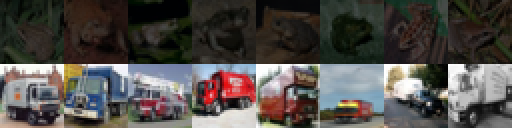

In [ ]:
import hashlib
import json
import os
import time
from pathlib import Path

os.makedirs('outputs', exist_ok=True)
OUTPUTS = Path('outputs')
DATA_DIR = Path('data')

PER_CLASS = 200  # @param {type:"integer"}
DATASET_SEED = 0  # @param {type:"integer"}
EPOCHS = 5  # @param {type:"integer"}

archive_info = fetch_sample_archive(DATA_DIR, allow_download=True)
print({k: archive_info[k] for k in ('dataset_id', 'revision', 'license', 'bytes', 'sha256', 'fetched')})
records = read_class_archive(DATA_DIR / SAMPLE_DATASET_FILE, classes=SAMPLE_CLASSES, max_per_class=PER_CLASS, seed=DATASET_SEED)
dataset_manifest = validate_dataset(records, SAMPLE_CLASSES, epochs=EPOCHS)
print(json.dumps(dataset_manifest, indent=2))

# DEIT-M2: copies of one photograph (pixel-identical or darkened) share a group key; Section 5 splits by it.
records, duplicate_summary = assign_duplicate_groups(records)
print(json.dumps(duplicate_summary, indent=2))

preview = Image.new('RGB', (8 * 64, 2 * 64))
for row, label in enumerate(SAMPLE_CLASSES):
    for col, record in enumerate([r for r in records if r['label'] == label][:8]):
        preview.paste(record['image'].resize((64, 64), Image.NEAREST), (64 * col, 64 * row))
preview

**What to notice (Section 4):** `duplicate_groups` in the manifest, and `groups`, `exact_copies` and `near_duplicate_links` in the grouping summary.

<details><summary>Check your reasoning</summary>In the recorded run (local CPU run of this revision, 2026-10-04, real weights, every field at its default) `validate_dataset` reported `duplicate_groups: 100` — the 100 pixel-identical pairs — and the grouping summary read 400 records → **200 groups**, every one of them a pair: 100 `exact_copies` and 100 `near_duplicate_links` (the darkened copies), with no group mixing two labels. The sample therefore holds 200 photographs, not 400, and a split by single images would put copies of many of them on both sides.</details>

## 5. Split by group, and measure two baselines before any training

The records are split per class with a fixed seed, **by group**: whole groups are shuffled and cut so that about 70% of the images train, and the rest is halved, again by group, into a **held-out** split, which scores every method below, and an **unseen** split, used only in Section 10. No hyperparameter is chosen on either. The cell then checks the result from the pixels, independently of the group keys: `cross_split_duplicates` counts held-out and unseen images that have a pixel-identical copy or a near duplicate in the training split, and the cell stops if any count is above 0. A split by single images would not be valid here, because the archive's copies are not independent; images that share a photograph, a scene or a camera session must always be split by that group.

Two baselines give the fine-tune something to beat:

- **Majority class:** always answer the most frequent training label. On a balanced split this is 50%, and any useful model must clear it.
- **Zero-shot ImageNet mapping:** the pretrained 1000-class head already has frog and truck classes. `zero_shot_evaluate` sums the softmax mass over ImageNet's three frog classes and over its big-truck classes (fire engine, garbage truck, moving van, tow truck, trailer truck; CIFAR-10's `truck` excludes pickups), and answers whichever group is larger. No weight changes.

The cell also prints ImageNet top-5 predictions for four images and a `sample-sanity` evaluation report: does the true group appear in the top-1 or the top-5?

**Predict before running:** will the ImageNet head put a frog class at top-1 for the frog thumbnails? And how far above the 50% majority baseline will the zero-shot mapping land on the held-out split?

In [ ]:
SEED = 0  # @param {type:"integer"}
TOP_K = 5  # @param {type:"integer"}

train_records, rest = split_dataset(records, train_fraction=0.7, seed=SEED, group_key='group')
held_out, unseen = split_dataset(rest, train_fraction=0.5, seed=SEED, group_key='group')
ids = [{r['id'] for r in part} for part in (train_records, held_out, unseen)]
assert not (ids[0] & ids[1] or ids[0] & ids[2] or ids[1] & ids[2]), 'split leaked records'
leakage = cross_split_duplicates(train_records, {'held_out': held_out, 'unseen': unseen})
leakage['unseen_vs_held_out'] = cross_split_duplicates(held_out, {'unseen': unseen})['unseen']
if any(row['pixel_copy_in_reference'] or row['near_duplicate_in_reference'] for row in leakage.values()):
    raise RuntimeError(f'copies of one photograph straddle the split: {leakage}; split with group_key="group" after assign_duplicate_groups')
TRAIN_MAJORITY = majority_class(train_records)
print(json.dumps({'train': len(train_records), 'held_out': len(held_out), 'unseen': len(unseen), 'train_majority': TRAIN_MAJORITY,
                  'duplicates_across_splits': leakage}, indent=2))

sample = held_out[:2] + held_out[-2:]
input_manifest = validate_inputs([r['image'] for r in sample], top_k=TOP_K, names=[r['id'] for r in sample])
try:
    validate_inputs([r['image'] for r in sample], top_k=0)
except ValueError as exc:
    input_manifest['findings'].append({'probe': 'top_k=0', 'rejected': str(exc)})
imagenet_result = pipe.predict([r['image'] for r in sample], top_k=TOP_K)
for record, pred in zip(sample, imagenet_result['predictions'], strict=True):
    print(record['label'], '->', [(item['label'].split(',')[0], round(item['score'], 3)) for item in pred['top_k']])
imagenet_report = evaluation_report(imagenet_result, [r['label'] for r in sample], groups=IMAGENET_GROUPS, sample_kind='sample')
print({'verdict': imagenet_report['verdict'], 'metrics': [(m['k'], m['value']) for m in imagenet_report['metrics']]})

zero_shot = pipe.zero_shot_evaluate(held_out, IMAGENET_GROUPS, majority=TRAIN_MAJORITY)
print(json.dumps({k: zero_shot[k] for k in ('accuracy', 'balanced_accuracy', 'majority_baseline_accuracy', 'mean_group_mass', 'per_class_recall')}, indent=2))

{
  "train": 280,
  "held_out": 60,
  "unseen": 60,
  "train_majority": "frog",
  "duplicates_across_splits": {
    "held_out": {
      "records": 60,
      "pixel_copy_in_reference": 0,
      "near_duplicate_in_reference": 0
    },
    "unseen": {
      "records": 60,
      "pixel_copy_in_reference": 0,
      "near_duplicate_in_reference": 0
    },
    "unseen_vs_held_out": {
      "records": 60,
      "pixel_copy_in_reference": 0,
      "near_duplicate_in_reference": 0
    }
  }
}


frog -> [('fox squirrel', 0.387), ('tailed frog', 0.197), ('frilled lizard', 0.028), ('wood rabbit', 0.017), ('marmoset', 0.007)]
frog -> [('fox squirrel', 0.571), ('tailed frog', 0.056), ('marmoset', 0.039), ('frilled lizard', 0.015), ('wood rabbit', 0.013)]
truck -> [('revolver', 0.306), ('moving van', 0.161), ('snowplow', 0.054), ('mobile home', 0.049), ('boathouse', 0.019)]
truck -> [('revolver', 0.306), ('moving van', 0.161), ('snowplow', 0.054), ('mobile home', 0.049), ('boathouse', 0.019)]
{'verdict': 'sample-sanity', 'metrics': [(1, 0.0), (5, 1.0)]}


{
  "accuracy": 0.9833333333333333,
  "balanced_accuracy": 0.9833333333333334,
  "majority_baseline_accuracy": 0.5,
  "mean_group_mass": 0.4399060904979706,
  "per_class_recall": {
    "frog": 0.9666666666666667,
    "truck": 1.0
  }
}


**What to notice (Section 5):** the split sizes, the four zeros under `duplicates_across_splits`, the top-1 label of each sample image, and the zero-shot `accuracy`.

<details><summary>Check your reasoning</summary>The recorded run split 280 / 60 / 60 (train majority `frog`: the classes tie, and the tie goes to the first name) and all four cross-split counts were 0 (also for `SEED` 0–4). Before this fix a split by single images with the same seed left 25 of the 60 held-out and 19 of the 60 unseen images with a pixel-identical copy in training, and 46 and 36 with a copy of either kind. Both frog thumbnails got `fox squirrel` at top-1 (0.387 and 0.571; `tailed frog` second in both) and both truck thumbnails `revolver` 0.306, with `moving van` second — identical lists, because those two are the two copies of one photograph, kept together in the held-out split; `sample-sanity` read top-1 0.0, top-5 1.0. The ImageNet top-1 labels look wrong on 32 px thumbnails, yet the zero-shot mapping, which adds up the scores of all frog classes and of all truck classes, scored 0.983 (59 of 60; recall frog 0.967, truck 1.000), far above the 0.500 majority baseline: the pretrained head already separates these two classes.</details>

## 6. Degenerate input probes: blank canvas and noise

A closed-set classifier has no "none of these" answer: every image gets one of its classes, with a score that sums to 1 across them. The cell shows what the ImageNet head answers for a white image and for uniform noise, and how high its top score is.

**What to look for:** a confident label on structure-free input is a property of softmax classification, not evidence about the image. The same probe is repeated on the adapted two-class model in Section 10.

**Predict before running:** with 1000 classes to spread over, will the top score for a blank image be above or below 0.1?

In [ ]:
degenerate = {}
for name, image in (('blank', blank_image()), ('noise', noise_image(0))):
    pred = pipe.predict(image, top_k=3)['predictions'][0]
    degenerate[name] = [(item['label'].split(',')[0], round(item['score'], 3)) for item in pred['top_k']]
print(json.dumps(degenerate, indent=2))

{
  "blank": [
    [
      "face powder",
      0.006
    ],
    [
      "hook",
      0.005
    ],
    [
      "rule",
      0.005
    ]
  ],
  "noise": [
    [
      "kite",
      0.083
    ],
    [
      "bald eagle",
      0.042
    ],
    [
      "nematode",
      0.029
    ]
  ]
}


**What to notice (Section 6):** the top label and score for each probe.

<details><summary>Check your reasoning</summary>Blank: `nematode` 0.002, `switch` 0.002, `hook` 0.002 — far below 0.1, spread thinly over 1000 classes. Noise: `jellyfish` 0.016, `nematode` 0.015, `kite` 0.013 (the same values as the Kaggle T4 record of the earlier revision). The labels are meaningless; the head must answer something, and here it answers with almost no confidence.</details>

## 7. Replace the head and measure the untrained two-class model

`from_pretrained(class_names=SAMPLE_CLASSES)` loads the verified checkpoint again and replaces only the classification layer (`classifier`, 384 features to 1000 classes) with a new 384-to-2 layer initialised under `SEED`. Every other weight keeps its ImageNet value.

**An untrained head is not a chance baseline.** Its weights are random, so it knows nothing about which label is which — but it reads the network's strong pretrained features, so a random direction through them can separate frogs from trucks by accident, in either direction. Its accuracy can land well below or well above 50%, and it changes with `SEED`. This row says what the starting point of the fine-tune looks like; it is not evidence that the fine-tune, rather than the pretrained features, solved the task. The zero-shot row of Section 5 is the baseline that answers that question.

**Predict before running:** will the untrained head score exactly 50%, below it, or above it?

In [ ]:
adapter = DeiTPipeline.from_pretrained(weights_dir=WEIGHTS_DIR, class_names=SAMPLE_CLASSES, seed=SEED)
print({'class_names': list(adapter.class_names), 'reinitialised': list(adapter.reinitialised), 'device': adapter.device})
untrained = adapter.evaluate(held_out, majority=TRAIN_MAJORITY)
print({k: untrained[k] for k in ('accuracy', 'balanced_accuracy', 'per_class_recall')})

{'class_names': ['frog', 'truck'], 'reinitialised': ['classifier.'], 'device': 'cuda:0'}


{'accuracy': 0.6, 'balanced_accuracy': 0.6, 'per_class_recall': {'frog': 0.6666666666666666, 'truck': 0.5333333333333333}}


**What to notice (Section 7):** the untrained head's `accuracy` and its per-class recall.

<details><summary>Check your reasoning</summary>The recorded run (local CPU run of this revision, 2026-10-04, real weights, every field at its default) measured 0.600 (36 of 60; recall frog 0.667, truck 0.533) at `SEED = 0` — above the 0.500 majority baseline, with no training at all. Across `SEED` 0–4 on the same split the untrained head scored 0.600, 0.200, 0.933, 0.400 and 0.517: a random head carries no information about the task and can land well below (or above) 50%, depending only on the random direction it starts from.</details>

## 8. Bounded fine-tuning

This cell runs the real adaptation step in this runtime: gradient fine-tuning with cross-entropy over the two classes.

- **What trains:** with `FREEZE_BACKBONE = False` (the default) every weight trains. With `True`, only the new head trains and the transformer (`vit.`) keeps its weights; ViT normalises with LayerNorm, so there are no running statistics to hold. The cell prints the trainable and total parameter counts.
- **Schedule:** `EPOCHS` epochs of AdamW at learning rate `1e-4` with weight decay `0.01`, batch size 16, float32, seed `SEED`, and no data augmentation: training images go through the same evaluation transform as test images.
- **Adaptation always starts from the re-headed model.** `finetune` changes the model in place. If you re-run this cell after the model has been fine-tuned — for example after changing `FREEZE_BACKBONE` — it first rebuilds `adapter` from the verified snapshot with the same `SEED` (the same fresh head that Section 7 measured), so a changed setting is compared from the same starting point instead of training an already adapted model further.

**Read the loss as optimisation evidence only.** A falling training loss says the optimizer is fitting the training images; the held-out comparison in the next section is the task evidence.

**Predict before running:** will the first epoch's loss be above or below 0.5, and how close to zero will the fifth be?

In [ ]:
LEARNING_RATE = 1e-4  # @param {type:"number"}
BATCH_SIZE = 16  # @param {type:"integer"}
FREEZE_BACKBONE = False  # @param {type:"boolean"}

if adapter.adapted:
    # A re-run: start again from the re-headed base (same SEED, same head as the Section 7 baseline).
    adapter = DeiTPipeline.from_pretrained(weights_dir=WEIGHTS_DIR, class_names=SAMPLE_CLASSES, seed=SEED)
    print({'rebuilt_from_verified_snapshot': True, 'adapted': adapter.adapted})
train_started = time.perf_counter()
run = adapter.finetune(
    train_records,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    seed=SEED,
    freeze_backbone=FREEZE_BACKBONE,
    progress=lambda row: print(f"epoch {row['epoch']}/{row['epochs']}  loss {row['loss']:.4f}"),
)
train_seconds = round(time.perf_counter() - train_started, 1)
print(json.dumps({**{key: run[key] for key in ('freeze_backbone', 'trainable_parameters', 'total_parameters', 'epochs',
                                             'batch_size', 'learning_rate', 'optimizer', 'augmentation', 'precision', 'device')},
                  'train_seconds': train_seconds}, indent=2))

epoch 1/5  loss 0.1379


epoch 2/5  loss 0.0681


epoch 3/5  loss 0.0062


epoch 4/5  loss 0.0003


epoch 5/5  loss 0.0003
{
  "freeze_backbone": false,
  "trainable_parameters": 21666434,
  "total_parameters": 21666434,
  "epochs": 5,
  "batch_size": 16,
  "learning_rate": 0.0001,
  "optimizer": "AdamW",
  "augmentation": "none (evaluation transform)",
  "precision": "float32",
  "device": "cuda:0",
  "train_seconds": 15.9
}


**What to notice (Section 8):** `trainable_parameters` against `total_parameters`, the five epoch losses, and `train_seconds`.

<details><summary>Check your reasoning</summary>The recorded run (local CPU run of this revision, 2026-10-04, real weights, every field at its default) trained all 21,666,434 of 21,666,434 parameters; the losses were 0.1378, 0.0684, 0.0062, 0.0003 and 0.0003, and `train_seconds` was 215.7 on a shared 24-thread CPU (the Kaggle T4 record of the earlier revision took about 15 s). The loss falls to almost zero: the network fits its 280 training images nearly perfectly, which is optimisation evidence only; whether the model now classifies new images well is Section 9's question.</details>

## 9. Evaluate on the held-out split, and read the comparison honestly

All four rows are scored on the same held-out images. Each row shows how many images it answered correctly out of how many, the `accuracy` that count gives, its **95% Wilson interval**, and `balanced_accuracy`, the mean of the per-class recalls, which cannot be inflated by favouring the larger class. The Wilson interval is the range of true accuracies that are compatible with the count at the 95% level; with a few dozen images one image moves the accuracy by a few points, so read rows whose intervals overlap as indistinguishable on this split. The majority-class row is the baseline every method must clear. The confusion matrix shows which way the errors go. These are tutorial metrics from one seeded split and one training run.

**The comparison that matters is fine-tuned against zero-shot**, not fine-tuned against the untrained head: the untrained head is the fine-tune's starting point, while the zero-shot mapping is what the pretrained model already does without any training. The cell computes a reading from the counts, not a fixed conclusion: when the zero-shot mapping already gets every held-out image right (or all but one), the comparison is **at ceiling** — the fine-tune can only tie, and the run measures no fine-tuning gain, whatever it prints for the fine-tuned row; otherwise it says whether the two Wilson intervals overlap.

Each run of this cell also adds a row to `RUN_HISTORY`, so the Section 14 activity can put two settings side by side.

**Predict before running:** will the fine-tuned row beat the zero-shot row, tie it, or fall below it?

In [ ]:
adapted = adapter.evaluate(held_out, majority=TRAIN_MAJORITY)
N_HELD = adapted['n']
comparison = {
    'majority class': {'accuracy': adapted['majority_baseline_accuracy'], 'balanced_accuracy': 1 / len(SAMPLE_CLASSES)},
    'zero-shot ImageNet mapping': zero_shot,
    'untrained two-class head': untrained,
    'fine-tuned': adapted,
}
held_out_intervals = {}
print(f"{'method':<28s} {'correct':>9s} {'accuracy':>9s} {'95% Wilson':>15s} {'balanced':>9s}")
for name, row in comparison.items():
    correct = round(row['accuracy'] * N_HELD)
    low, high = wilson_interval(correct, N_HELD)
    held_out_intervals[name] = {'correct': correct, 'n': N_HELD, 'accuracy': row['accuracy'], 'wilson_95': [round(low, 4), round(high, 4)]}
    print(f"{name:<28s} {f'{correct}/{N_HELD}':>9s} {row['accuracy']:>9.3f} {f'[{low:.3f}, {high:.3f}]':>15s} {row['balanced_accuracy']:>9.3f}")
print('confusion (rows true, columns predicted):', adapted['confusion_matrix'])

# DEIT-m2: a reading computed from the counts and intervals, not a fixed conclusion.
zs, ft = held_out_intervals['zero-shot ImageNet mapping'], held_out_intervals['fine-tuned']
if zs['correct'] >= N_HELD - 1:
    comparison_verdict = (f"at ceiling: the zero-shot mapping already answers {zs['correct']}/{N_HELD} held-out images correctly, "
                          f"so the fine-tune ({ft['correct']}/{N_HELD}) can at best tie it; this run measures no fine-tuning gain")
elif ft['wilson_95'][0] > zs['wilson_95'][1]:
    comparison_verdict = f"fine-tuned ({ft['correct']}/{N_HELD}) is above zero-shot ({zs['correct']}/{N_HELD}): the 95% Wilson intervals do not overlap"
elif ft['wilson_95'][1] < zs['wilson_95'][0]:
    comparison_verdict = f"fine-tuned ({ft['correct']}/{N_HELD}) is below zero-shot ({zs['correct']}/{N_HELD}): the 95% Wilson intervals do not overlap"
else:
    comparison_verdict = f"fine-tuned {ft['correct']}/{N_HELD} and zero-shot {zs['correct']}/{N_HELD}: the 95% Wilson intervals overlap, so this split cannot tell them apart"
print('reading:', comparison_verdict)

RUN_HISTORY = globals().get('RUN_HISTORY', [])
RUN_HISTORY.append({'run': len(RUN_HISTORY), 'freeze_backbone': run['freeze_backbone'], 'per_class': PER_CLASS, 'epochs': EPOCHS,
                    'learning_rate': LEARNING_RATE, 'trainable_parameters': run['trainable_parameters'], 'held_out_n': adapted['n'],
                    'zero_shot_accuracy': round(zero_shot['accuracy'], 4), 'fine_tuned_accuracy': round(adapted['accuracy'], 4),
                    'final_loss': round(run['final_loss'], 4), 'train_seconds': train_seconds})
for row in RUN_HISTORY:
    print(row)

method                         correct  accuracy      95% Wilson  balanced
majority class                   30/60     0.500  [0.377, 0.623]     0.500
zero-shot ImageNet mapping       59/60     0.983  [0.911, 0.997]     0.983
untrained two-class head         36/60     0.600  [0.474, 0.714]     0.600
fine-tuned                       60/60     1.000  [0.940, 1.000]     1.000
confusion (rows true, columns predicted): {'labels': ['frog', 'truck'], 'rows_true_cols_predicted': [[30, 0], [0, 30]]}
reading: at ceiling: the zero-shot mapping already answers 59/60 held-out images correctly, so the fine-tune (60/60) can at best tie it; this run measures no fine-tuning gain
{'run': 0, 'freeze_backbone': False, 'per_class': 200, 'epochs': 5, 'learning_rate': 0.0001, 'trainable_parameters': 21666434, 'held_out_n': 60, 'zero_shot_accuracy': 0.9833, 'fine_tuned_accuracy': 1.0, 'final_loss': 0.0003, 'train_seconds': 15.9}


**What to notice (Section 9):** the four rows with their counts and Wilson intervals, the confusion matrix and the reading line.

<details><summary>Check your reasoning</summary>The recorded run (local CPU run of this revision, 2026-10-04, real weights, every field at its default): majority class 30/60, 0.500 [0.377, 0.623]; zero-shot 59/60, 0.983 [0.911, 0.997]; untrained head 36/60, 0.600 [0.474, 0.714]; fine-tuned 60/60, 1.000 [0.940, 1.000], confusion `[[30, 0], [0, 30]]`. The reading was **at ceiling**: the zero-shot mapping already answers 59 of 60, so the fine-tune can at best tie it, and this run measures no fine-tuning gain. The fine-tune is far above the majority baseline and the untrained head, but its one-image edge over the zero-shot mapping is not evidence of a gain. A GPU run can differ by an image, which does not change that reading.</details>

## 10. Inference on the unseen split and the degenerate probes again

The unseen split was never used for training or for any comparison above, and no photograph in it has a copy in the training or held-out split (Section 5 checked). The adapted pipeline classifies it, and the cell repeats the blank and noise probes: the two-class model must now answer `frog` or `truck` for them, whatever they contain.

**Predict before running:** what will the adapted model answer for the blank image, and with a score near 0.5 or near 1?

In [ ]:
unseen_metrics = adapter.evaluate(unseen, majority=TRAIN_MAJORITY)
unseen_correct = round(unseen_metrics['accuracy'] * unseen_metrics['n'])
unseen_metrics['wilson_95'] = [round(v, 4) for v in wilson_interval(unseen_correct, unseen_metrics['n'])]
print({'correct': unseen_correct, **{k: unseen_metrics[k] for k in ('n', 'accuracy', 'wilson_95', 'balanced_accuracy')}})
unseen_rows = []
for record, pred in zip(unseen, adapter.predict([r['image'] for r in unseen[:MAX_BATCH]], top_k=2)['predictions'], strict=False):
    unseen_rows.append({'id': record['id'], 'truth': record['label'], 'predicted': pred['predicted_label'], 'score': round(pred['top_k'][0]['score'], 4)})
print(json.dumps(unseen_rows[:6], indent=2))
adapted_degenerate = {name: adapter.predict(image, top_k=2)['predictions'][0]['top_k'] for name, image in (('blank', blank_image()), ('noise', noise_image(0)))}
print({name: [(i['label'], round(i['score'], 3)) for i in top] for name, top in adapted_degenerate.items()})

{'correct': 60, 'n': 60, 'accuracy': 1.0, 'wilson_95': [0.9398, 1.0], 'balanced_accuracy': 1.0}


[
  {
    "id": "CIFAR-10-subset/darkened_images/frog/image_15.png",
    "truth": "frog",
    "predicted": "frog",
    "score": 0.9999
  },
  {
    "id": "CIFAR-10-subset/original_images/frog/image_15.png",
    "truth": "frog",
    "predicted": "frog",
    "score": 0.9996
  },
  {
    "id": "CIFAR-10-subset/darkened_images/frog/image_75.png",
    "truth": "frog",
    "predicted": "frog",
    "score": 0.9993
  },
  {
    "id": "CIFAR-10-subset/original_images/frog/image_75.png",
    "truth": "frog",
    "predicted": "frog",
    "score": 0.9981
  },
  {
    "id": "CIFAR-10-subset/darkened_images/frog/image_58.png",
    "truth": "frog",
    "predicted": "frog",
    "score": 0.9999
  },
  {
    "id": "CIFAR-10-subset/original_images/frog/image_58.png",
    "truth": "frog",
    "predicted": "frog",
    "score": 0.9998
  }
]
{'blank': [('truck', 0.542), ('frog', 0.458)], 'noise': [('frog', 0.851), ('truck', 0.149)]}


**What to notice (Section 10):** the unseen `accuracy`, and the label and score the adapted model gives the blank and noise images.

<details><summary>Check your reasoning</summary>The recorded run (local CPU run of this revision, 2026-10-04, real weights, every field at its default) classified the unseen split 60/60, 1.000 [0.940, 1.000]. The adapted head answered `truck` 0.547 for the blank image and `frog` 0.851 for noise (the Kaggle T4 record of the earlier revision: `frog` 0.598 and `frog` 0.912). A two-class head has no 'neither' answer, so it must pick one of its two classes for a white square, and which one can change from run to run.</details>

## 11. Adapter export, fresh reload, and equivalence check

`save_artifact` writes `outputs/deit_adapter.safetensors`: every tensor the fine-tune could change, plus a metadata header naming the base model, its pinned revision, the base `pytorch_model.bin` SHA-256, the class names and the frozen prefixes. With the default full fine-tune that is the whole state dict; with `FREEZE_BACKBONE = True` it is the head only.

`load_artifact` then builds a **fresh** pipeline from the verified base snapshot, loads the adapter tensors onto it, and refuses an adapter whose format, base identity, base digest or tensor set does not fit. `reload_equivalence` compares the reloaded predictions with the in-memory model's on the unseen split, with a stated tolerance: loading succeeding is not the check, reproducing the predictions is. A mismatch stops the cell with a message naming the image, the two answers and what to do next. The same helper checks the BYOD adapter in Section 13.

In [ ]:
artifact_path = OUTPUTS / 'deit_adapter.safetensors'
descriptor = adapter.save_artifact(artifact_path, notes='DeiT-Small CIFAR-10 frog/truck tutorial adapter')
print(json.dumps(descriptor, indent=2))

reloaded = DeiTPipeline.load_artifact(artifact_path, weights_dir=WEIGHTS_DIR)
print({'reloaded_source': reloaded.source, 'adapted': reloaded.adapted, 'class_names': list(reloaded.class_names)})

TOLERANCE = 1e-4

def reload_equivalence(first, second, images, tolerance=TOLERANCE):
    """Both pipelines must give every image the same label and a top score within `tolerance`."""
    advice = ('the export does not reproduce the evaluated model. If you changed a Section 8 field, re-run from Section 8 '
              '(Runtime -> Run after) so the adapter is exported from the model that was evaluated; otherwise restart the '
              'session and choose Run all')
    first_preds = first.predict(images, top_k=2)['predictions']
    second_preds = second.predict(images, top_k=2)['predictions']
    for index, (a, b) in enumerate(zip(first_preds, second_preds, strict=True)):
        if a['predicted_label'] != b['predicted_label']:
            raise RuntimeError(f"image {index}: the reloaded adapter answers {b['predicted_label']!r}, the in-memory model {a['predicted_label']!r}: {advice}")
        if abs(a['top_k'][0]['score'] - b['top_k'][0]['score']) > tolerance:
            raise RuntimeError(f"image {index}: top score {b['top_k'][0]['score']:.6f} after reload against {a['top_k'][0]['score']:.6f}, beyond tolerance {tolerance}: {advice}")
    return {'images_compared': len(images), 'tolerance': tolerance, 'equivalent': True}

reload_check = reload_equivalence(adapter, reloaded, [r['image'] for r in unseen[:MAX_BATCH]])
print(reload_check)

{
  "path": "outputs/deit_adapter.safetensors",
  "bytes": 86688984,
  "sha256": "84b67a1aa5506b0cfa28ea5949ededb19bdcbc7ceda9b50fe6e665af53d4da46",
  "format": "deit-adapter-v1",
  "class_names": [
    "frog",
    "truck"
  ],
  "tensors": 200,
  "frozen_prefixes": [],
  "base_state_digest": "7eadf70de01e439569e1bbba8b5ef233b4bf70f25a98d9b33460095672bce38c",
  "model_id": "facebook/deit-small-patch16-224",
  "model_revision": "164deee347853469b97442b3817f22eece80c7e3"
}


{'reloaded_source': 'artifact:deit_adapter.safetensors', 'adapted': True, 'class_names': ['frog', 'truck']}


{'images_compared': 60, 'tolerance': 0.0001, 'equivalent': True}


**What to notice (Section 11):** the number of tensors in the adapter, its size, and `equivalent: True`.

<details><summary>Check your reasoning</summary>The recorded run (local CPU run of this revision, 2026-10-04, real weights, every field at its default) wrote 200 tensors (the whole network, 86,688,984 bytes) and the reload check compared 60 unseen images within 1e-4: `equivalent: True`. The header's `base_state_digest` is `7eadf70de01e…`, the SHA-256 of the base `pytorch_model.bin` in the Section 3 manifest. With `FREEZE_BACKBONE = True` the adapter holds only the 2 head tensors (3,632 bytes).</details>

## 12. Write machine-readable outputs and provenance

The cell writes:
- `outputs/deit_classification_input_manifest.json`
- `outputs/deit_classification_evaluation_report.json`
- `outputs/deit_classification_result.json` (identity, runtime versions, device, dataset provenance and manifest, the duplicate grouping and the cross-split duplicate counts, split, baselines, fine-tuning configuration and time, held-out and unseen metrics with their Wilson intervals, the comparison reading, the run history, adapter descriptor and reload check)
- `outputs/deit_classification_predictions.csv`
- `outputs/deit_adapter.safetensors` (written in Section 11)

In [ ]:
import csv

with open(OUTPUTS / 'deit_classification_input_manifest.json', 'w', encoding='utf-8') as f:
    json.dump(input_manifest, f, indent=2)

with open(OUTPUTS / 'deit_classification_evaluation_report.json', 'w', encoding='utf-8') as f:
    json.dump(imagenet_report, f, indent=2)

def write_predictions(path, pipeline, parts):
    with open(path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['split', 'id', 'group', 'truth', 'predicted', 'score'])
        for split_name, part in parts:
            for start in range(0, len(part), MAX_BATCH):
                chunk = part[start:start + MAX_BATCH]
                for record, pred in zip(chunk, pipeline.predict([r['image'] for r in chunk], top_k=1)['predictions'], strict=True):
                    writer.writerow([split_name, record['id'], record.get('group', ''), record['label'], pred['predicted_label'], f"{pred['top_k'][0]['score']:.4f}"])

write_predictions(OUTPUTS / 'deit_classification_predictions.csv', adapter, (('held_out', held_out), ('unseen', unseen)))

result_export = {
    'notebook_source': NOTEBOOK_SOURCE,
    'repository_revision': NOTEBOOK_SOURCE['repository_revision'],
    'model_id': MODEL_ID,
    'model_revision': MODEL_REVISION,
    'model_license': MODEL_LICENSE,
    'runtime': {'python': platform.python_version(), 'torch': torch.__version__, 'torchvision': torchvision.__version__,
                'transformers': transformers.__version__, 'cuda': torch.cuda.is_available()},
    'device': pipe.device,
    'dataset': {'archive': archive_info, 'manifest': dataset_manifest, 'per_class': PER_CLASS, 'seed': DATASET_SEED,
                'duplicate_groups': duplicate_summary},
    'split': {'train': len(train_records), 'held_out': len(held_out), 'unseen': len(unseen), 'seed': SEED, 'train_majority': TRAIN_MAJORITY,
              'group_key': 'group', 'duplicates_across_splits': leakage},
    'imagenet_top_k': imagenet_result['predictions'],
    'degenerate_probes': {'imagenet_head': degenerate, 'adapted': adapted_degenerate},
    'baselines': {'zero_shot': zero_shot, 'untrained_head': untrained},
    'finetune': {**run, 'train_seconds': train_seconds},
    'held_out': adapted,
    'comparison_verdict': comparison_verdict,
    'held_out_intervals': held_out_intervals,
    'run_history': RUN_HISTORY,
    'unseen': unseen_metrics,
    'artifact': descriptor,
    'reload_check': reload_check,
}
with open(OUTPUTS / 'deit_classification_result.json', 'w', encoding='utf-8') as f:
    json.dump(result_export, f, indent=2, default=str)

for p in sorted(OUTPUTS.iterdir()):
    if p.is_file():
        print(f'  {p.name:<48s} {p.stat().st_size:>12,d} bytes')

  deit_adapter.safetensors                           86,688,984 bytes
  deit_classification_evaluation_report.json                794 bytes
  deit_classification_input_manifest.json                 1,347 bytes
  deit_classification_predictions.csv                    15,366 bytes
  deit_classification_result.json                        13,342 bytes


## 13. Optional: Bring Your Own Data (BYOD)

Both branches are off by default, so `Run all` never stops here. Before you turn one on, read the contract:

- **Image branch** (`USE_BYOD_IMAGE`): one image file PIL can open, each side between `MIN_IMAGE_SIDE` (8) and `MAX_IMAGE_SIDE` (4096) px. It runs through `validate_inputs`, the ImageNet head's `predict` and `evaluation_report`; the report is `not-measurable`, because no label comes with the image.
- **Dataset branch** (`USE_BYOD_DATASET`): a directory or a `.zip` of class folders, `<class>/<image>`, with at least 2 classes and at least 2 images per class that are not copies of each other, at most 5,000 images. Archive members must stay inside the archive; folder files must not link outside the directory. The class names are the folder names; images directly at the top level are ignored, and the cell says how many. A layout with `train/` and `val/` folders is **merged by class name and re-split**, and the cell says so. The branch runs the same validate → group duplicates → split by group → baselines → fine-tune → evaluate → export → reload-and-compare stages as the sample, and classifies an unseen split when every class has enough independent images for one (4 or more); the zero-shot ImageNet baseline needs a class-to-ImageNet mapping, so it is skipped here. It writes `outputs/byod/byod_deit_classification_result.json` and `outputs/byod/byod_deit_classification_predictions.csv`.

Set `BYOD_IMAGE_PATH` or `BYOD_DATASET_PATH` to read from a mounted or local location; leave them empty on Colab to get an upload dialog instead (outside Colab an empty location stops with a message naming the field to set). Uploaded files are written under `outputs/byod/` in this runtime, a new upload replaces the previous one, and nothing is sent anywhere else. The first lines of the cell show the validator refusing two malformed inputs with messages that name the failed rule.

In [ ]:
import shutil

USE_BYOD_IMAGE = False  # @param {type:"boolean"}
BYOD_IMAGE_PATH = ""  # @param {type:"string"}
USE_BYOD_DATASET = False  # @param {type:"boolean"}
BYOD_DATASET_PATH = ""  # @param {type:"string"}

for desc, probe in (
    ('non-image object', lambda: validate_inputs('/not/an/image.png')),
    ('class with one image', lambda: validate_dataset([{'image': blank_image(32, 32), 'label': 'frog'}, {'image': noise_image(1, 32, 32), 'label': 'truck'}], SAMPLE_CLASSES)),
):
    try:
        probe()
    except (TypeError, ValueError) as exc:
        print(f'refused as expected: {desc} -> {type(exc).__name__}: {exc}')

BYOD_DIR = OUTPUTS / 'byod'

def _upload_into(target, field):
    try:
        from google.colab import files  # type: ignore[import-not-found]
    except ImportError:
        raise FileNotFoundError(f'{field} is empty and this runtime has no Colab upload dialog: set {field} to a local path') from None
    shutil.rmtree(target, ignore_errors=True)  # a new upload replaces the previous one
    target.mkdir(parents=True, exist_ok=True)
    for name, data in files.upload().items():
        (target / Path(name).name).write_bytes(data)
    uploaded = sorted(target.iterdir())
    if not uploaded:
        raise FileNotFoundError(f'nothing was uploaded; upload a file or set {field}')
    return uploaded[0]

if USE_BYOD_IMAGE:
    image_path = Path(BYOD_IMAGE_PATH) if BYOD_IMAGE_PATH else _upload_into(BYOD_DIR / 'image', 'BYOD_IMAGE_PATH')
    try:
        with Image.open(image_path) as handle:
            byod_image = handle.convert('RGB')
    except (OSError, SyntaxError) as exc:
        raise ValueError(f'{image_path} is not an image PIL can open ({exc}); set BYOD_IMAGE_PATH to a .png, .jpg, .bmp or .webp file') from None
    print(validate_inputs(byod_image, top_k=TOP_K, names=[image_path.name])['verdict'])
    byod_result = pipe.predict(byod_image, top_k=TOP_K)
    print([(item['label'].split(',')[0], round(item['score'], 3)) for item in byod_result['predictions'][0]['top_k']])
    print(evaluation_report(byod_result, None, sample_kind='byod')['verdict'])
else:
    print('BYOD image branch is off; set USE_BYOD_IMAGE = True to classify your own image.')

def _byod_layout(source):
    """Top-level image files (ignored) and top-level folder names of a class-folder directory or .zip."""
    if source.is_dir():
        names = [p.name + ('/' if p.is_dir() else '') for p in source.iterdir()]
    else:
        import zipfile
        with zipfile.ZipFile(source) as archive:
            names = sorted({n.split('/')[0] + ('/' if '/' in n else '') for n in archive.namelist()})
    loose = [n for n in names if not n.endswith('/') and Path(n).suffix.lower() in IMAGE_SUFFIXES]
    folders = sorted(n.rstrip('/') for n in names if n.endswith('/'))
    return loose, folders

if USE_BYOD_DATASET:
    source = Path(BYOD_DATASET_PATH) if BYOD_DATASET_PATH else _upload_into(BYOD_DIR / 'dataset', 'BYOD_DATASET_PATH')
    if not source.exists():
        raise FileNotFoundError(f'{source} does not exist; set BYOD_DATASET_PATH to a directory or a .zip of class folders')
    if source.is_file() and source.suffix.lower() != '.zip':
        raise ValueError(f'{source.name} is not a .zip: the dataset must be a directory or a .zip of <class>/<image> folders (unpack or re-zip a .tar)')
    loose, folders = _byod_layout(source)
    if loose:
        print(f'note: {len(loose)} image(s) at the top level were ignored (e.g. {loose[:3]}); only images inside class folders are read')
    if {f.lower() for f in folders} & {'train', 'val', 'valid', 'validation', 'test'}:
        print(f'note: top-level folders {folders} look like a pre-made split; images are merged by class name and re-split by group below')
    byod_records = read_class_archive(source) if source.suffix.lower() == '.zip' else read_class_folder(source)
    byod_names = sorted({r['label'] for r in byod_records})
    if len(byod_names) < 2:
        raise ValueError(f'the dataset needs at least 2 class folders (<class>/<image>); found {byod_names}' + (f' and {len(loose)} loose top-level image(s); move them into class folders' if loose else ''))
    byod_manifest = validate_dataset(byod_records, byod_names, epochs=EPOCHS)
    byod_records, byod_duplicates = assign_duplicate_groups(byod_records)
    print(json.dumps({'manifest': byod_manifest, 'duplicate_groups': byod_duplicates}, indent=2))
    byod_train, byod_rest = split_dataset(byod_records, train_fraction=0.7, seed=SEED, group_key='group')
    try:
        byod_held, byod_unseen = split_dataset(byod_rest, train_fraction=0.5, seed=SEED, group_key='group')
    except ValueError as exc:
        byod_held, byod_unseen = byod_rest, []
        print(f'note: no unseen split ({exc}); every class needs 4 or more independent images for one')
    byod_parts = {'held_out': byod_held, **({'unseen': byod_unseen} if byod_unseen else {})}
    byod_leakage = cross_split_duplicates(byod_train, byod_parts)
    print({'train': len(byod_train), **{name: len(part) for name, part in byod_parts.items()}, 'duplicates_across_splits': byod_leakage})
    byod_majority = majority_class(byod_train)
    byod_pipe = DeiTPipeline.from_pretrained(weights_dir=WEIGHTS_DIR, class_names=byod_names, seed=SEED)
    byod_before = byod_pipe.evaluate(byod_held, majority=byod_majority)
    byod_run = byod_pipe.finetune(byod_train, epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE, seed=SEED, freeze_backbone=FREEZE_BACKBONE)
    byod_after = byod_pipe.evaluate(byod_held, majority=byod_majority)
    byod_unseen_metrics = byod_pipe.evaluate(byod_unseen, majority=byod_majority) if byod_unseen else None
    print(f"{'held-out (n=' + str(byod_after['n']) + ')':<28s} {'accuracy':>9s} {'balanced':>9s}")
    for name, acc, bal in (('majority class', byod_after['majority_baseline_accuracy'], 1 / len(byod_names)),
                           ('untrained head', byod_before['accuracy'], byod_before['balanced_accuracy']),
                           ('fine-tuned', byod_after['accuracy'], byod_after['balanced_accuracy'])):
        print(f'{name:<28s} {acc:>9.3f} {bal:>9.3f}')
    if byod_unseen_metrics:
        print({'unseen_accuracy': byod_unseen_metrics['accuracy'], 'unseen_balanced_accuracy': byod_unseen_metrics['balanced_accuracy'], 'n': byod_unseen_metrics['n']})
    (BYOD_DIR).mkdir(parents=True, exist_ok=True)
    byod_artifact = BYOD_DIR / 'byod_deit_adapter.safetensors'
    byod_descriptor = byod_pipe.save_artifact(byod_artifact, notes='BYOD adaptation adapter')
    byod_reloaded = DeiTPipeline.load_artifact(byod_artifact, weights_dir=WEIGHTS_DIR)
    byod_reload_check = reload_equivalence(byod_pipe, byod_reloaded, [r['image'] for r in (byod_unseen or byod_held)[:MAX_BATCH]])
    write_predictions(BYOD_DIR / 'byod_deit_classification_predictions.csv', byod_pipe, tuple(byod_parts.items()))
    byod_export = {
        'notebook_source': NOTEBOOK_SOURCE, 'model_id': MODEL_ID, 'model_revision': MODEL_REVISION, 'model_license': MODEL_LICENSE,
        'source': source.name, 'class_names': byod_names, 'manifest': byod_manifest, 'duplicate_groups': byod_duplicates,
        'ignored_top_level_images': len(loose),
        'split': {'train': len(byod_train), **{name: len(part) for name, part in byod_parts.items()}, 'seed': SEED, 'group_key': 'group',
                  'duplicates_across_splits': byod_leakage},
        'baselines': {'majority_class_accuracy': byod_after['majority_baseline_accuracy'], 'untrained_head': byod_before},
        'finetune': byod_run, 'held_out': byod_after, 'unseen': byod_unseen_metrics,
        'artifact': byod_descriptor, 'reload_check': byod_reload_check,
    }
    with open(BYOD_DIR / 'byod_deit_classification_result.json', 'w', encoding='utf-8') as f:
        json.dump(byod_export, f, indent=2, default=str)
    print('BYOD adapter exported, reloaded and compared:', byod_reload_check, byod_descriptor['sha256'][:16])
else:
    print('BYOD dataset branch is off; set USE_BYOD_DATASET = True to adapt DeiT-Small on your own class folders.')

refused as expected: non-image object -> TypeError: images must be a PIL.Image.Image or a sequence of them
refused as expected: class with one image -> ValueError: every class needs at least 2 images to split; short classes: {'frog': 1, 'truck': 1}
BYOD image branch is off; set USE_BYOD_IMAGE = True to classify your own image.
BYOD dataset branch is off; set USE_BYOD_DATASET = True to adapt DeiT-Small on your own class folders.


## 14. Your turn — change one thing: freeze the backbone

Optional; **Predict → Change → Run → Observe → Explain**. It re-runs the fine-tune with only the new head trainable.

1. **Predict:** with `FREEZE_BACKBONE = True`, will held-out accuracy go up, stay or go down against the default run, and will the fine-tune take more or less time? Write your guess next to row 0 of the Section 9 run history.
2. **Change:** in Section 8 set `FREEZE_BACKBONE = True`. Change nothing else.
3. **Run:** select the Section 8 cell and choose **Runtime → Run after**. Section 8 rebuilds the re-headed model from the verified snapshot before training (it prints `rebuilt_from_verified_snapshot`), Section 9 adds a row to the run history, and Sections 10–12 re-run on the new adapter. (If you re-run only the Section 8 cell, it still trains from the re-headed model; re-run Sections 9–12 afterwards so the comparison, the export and the outputs describe the same model.)
4. **Observe:** in Section 8, `trainable_parameters` falls from every parameter to the head alone. In Section 9, compare rows 0 and 1 of the run history: `fine_tuned_accuracy`, `zero_shot_accuracy`, `final_loss` and `train_seconds`. In Section 11, count the adapter's tensors.
5. **Explain:** in one sentence, why can training 0.004% of the parameters reach nearly the same held-out accuracy as training all of them on this task?

<details><summary>Check your reasoning</summary>In a local CPU run of this revision (2026-10-04, real weights, `FREEZE_BACKBONE = True` and Section 8 re-run after the default run, every other field at its default) Section 8 printed `rebuilt_from_verified_snapshot`, trained 770 of 21,666,434 parameters (0.004%), and its losses went 0.6671 → 0.2374 (the full fine-tune: 0.1378 → 0.0003). Section 11 straight after exported 2 tensors and reloaded equivalently. The run history then read: full fine-tune 60/60 held-out in 215.7 s; head only 60/60 [0.940, 1.000] in 50.9 s; zero-shot 59/60 in both rows; on the unseen split the head-only model scored 59/60. The pretrained features already separate frogs from trucks — the zero-shot row is at ceiling — so a linear head on top of them matches the full fine-tune on this split in five short epochs, in about a quarter of the time; the much higher final loss says the head-only model is less confident on the training images, not that it classifies worse. Identical held-out scores at the ceiling cannot rank the two runs.</details>

## Interpretation and limits

Start from your own run: the Section 9 table and its reading line, the Section 4 grouping summary and the Section 5 cross-split counts. Then read the reference answer.

<details><summary>Reference answer from the recorded runs</summary>The ImageNet head gave the sample thumbnails non-frog, non-truck top-1 labels at 32 px, yet its summed frog and truck classes separated the two labels, and it spread its scores thinly over blank and noise images. The archive's 400 images are 200 photographs, each held twice; grouped, they split 280 / 60 / 60 with no copy across splits. On the 60 held-out images the zero-shot mapping scored 59/60 [0.911, 0.997]; the untrained head 36/60, which moves with the seed between 0.200 and 0.933; the full fine-tune and the head-only fine-tune both 60/60 [0.940, 1.000] — at ceiling, every interval overlaps the zero-shot one, so this run measures **no reliable fine-tuning gain** over what the pretrained model already does. The unseen split scored 60/60 and the adapter reloaded to the same predictions within 1e-4 (local CPU run of this revision, 2026-10-04; the Kaggle T4 run of the earlier revision, whose split was not duplicate-aware, also scored zero-shot 0.983 and fine-tuned 1.000 there).</details>

**What this notebook established, in this runtime.** The pinned `facebook/deit-small-patch16-224` snapshot was verified against a committed SHA-256 manifest before loading, and the pinned CIFAR-10 subset was verified against its recorded digest before it was read. Its duplicate and darkened copies were grouped, the split kept every group on one side, and the held-out and unseen splits were checked from the pixels to hold no copy of a training image. The ImageNet head was run on sample thumbnails and on two structure-free probes, and its frog and truck classes gave a zero-shot baseline. The head was then replaced for the two tutorial classes and fine-tuned, and the result was compared with the majority-class, zero-shot and untrained baselines on the same held-out split and checked on an unseen split. The adapter was exported, reloaded onto a fresh base model and checked against the in-memory predictions.

**What the comparison shows.** On frog versus truck the pretrained model is already at or near ceiling: the zero-shot mapping classifies 59 of the 60 held-out images correctly without any training, and the fine-tune's 60 of 60 is a one-image difference inside overlapping 95% intervals. This run shows that the fine-tune *works* — it trains, it matches the zero-shot result with a dedicated two-class head, and it exports faithfully — but not that it *improves* on what the pretrained model already does. The untrained head's score is a property of a random starting point, not a floor that the fine-tune lifts the model from. Measuring a fine-tuning gain needs a task the pretrained head does not already solve: your own classes through the BYOD dataset branch, for example.

**What a green run proves.** Successful execution proves that the recorded repository revision, the pinned dependency set, the pinned checkpoint and the pinned dataset together reproduce these stages in a fresh runtime, without the repository being cloned or installed and without any DIMER worker or service. It does **not** establish benchmark superiority, fitness for any deployment, or that the adapted model recognises frogs or trucks outside CIFAR-10's 32×32 thumbnails. The held-out scores come from a few dozen images and carry no dispersion estimate. The scores are not calibrated probabilities, and there is no reject option.

**Reproducibility.** Seeds are form fields (`DATASET_SEED`, `SEED`), the run is float32 with no data augmentation, and the new head is initialised under `SEED`. GPU kernels are not forced to be deterministic, so repeated GPU runs can differ in the last digits of the loss and the scores.

**More experiments (optional).** Each one names the field to change and where to re-run from; a re-run of Section 8 always starts from the re-headed model, and Section 9's run history keeps the earlier rows.

- **A smaller sample:** set `PER_CLASS = 10` in Section 4, select Section 4 and choose **Runtime → Run after**. With 10 images per class the grouping finds 19 groups (one darkened pair), the split is 14 / 2 / 4, and the held-out split holds 2 images, so one image is worth 50 points of accuracy. Does the fine-tune still beat zero-shot? If both score 2/2, the 95% Wilson interval of each is [0.342, 1.000]: a perfect score that says almost nothing (this split was measured locally; the scores at this size were not). Watch the interval, not the accuracy.
- **A different starting point:** set `SEED = 1` in Section 5 and **Run after** from Section 5. The split, the untrained head and the fine-tune all change with it; compare how far the untrained row moves with how far the zero-shot and fine-tuned rows move.
- **Your own classes:** turn on `USE_BYOD_DATASET` in Section 13 and re-run that cell only. Pick classes the ImageNet head does not already name, so the untrained-to-fine-tuned change has room to mean something.

## Troubleshooting

- **Section 1 stops with "needs a Linux x86_64 runtime".** The locked environment is built from manylinux wheels; use Google Colab, Kaggle or a Linux Jupyter server.
- **Section 1 fails while downloading.** The `uv` wheel, the managed Python and the locked packages come from PyPI and python-build-standalone; run the cell again. A size or SHA-256 mismatch is refused on purpose — if it repeats, the download is being altered.
- **A restart prompt.** This notebook never needs one: nothing is installed into the kernel. If the isolated process exits (usually out of memory), restart the session and choose **Run all**.
- **Section 3 or 4 stops on a download or a digest mismatch.** The checkpoint and the sample archive are fetched from the Hugging Face Hub at pinned revisions and re-hashed; a mismatch is never loaded. Run the cell again; if it repeats, delete `weights/` or `data/` and run from that section.
- **Section 5 stops with "copies of one photograph straddle the split".** The split was made without `group_key='group'` or before Section 4 grouped the records; run from Section 4.
- **Out of memory in Section 8.** Lower `BATCH_SIZE` to 8 in Section 8, or set `FREEZE_BACKBONE = True`, and **Run after** from Section 8. On a CPU runtime the fine-tune is slow, not broken.
- **Section 11 stops with "the export does not reproduce the evaluated model".** The model in memory was changed after it was evaluated; re-run from Section 8 (**Runtime → Run after**).
- **BYOD is refused.** Each refusal names the rule: fewer than 2 class folders, a class with fewer than 2 independent images, a path with `..`, an undecodable image, an image side outside 8..4,096 px, a file that is not a directory or a `.zip`, or an empty location outside Colab. Fix the input or the location field, then re-run Section 13.

## Glossary

- **DeiT / patch embedding / `[CLS]` token:** a Vision Transformer (ViT) that cuts the 224 px image into 196 patches of 16×16 px, projects each to a 384-wide token, adds position embeddings and one extra learned `[CLS]` token, and passes the sequence through 12 transformer layers; the head reads only the final `[CLS]` token.
- **Data-efficient training:** DeiT's recipe (strong augmentation and regularisation) for training a ViT on ImageNet-1k alone, without a larger pre-training set. The DeiT paper also adds a distillation token; this checkpoint is the plain DeiT-Small without it.
- **Softmax score:** the head's output turned into numbers that sum to 1 over its classes; the label is the largest. Not a calibrated probability, and never "none of these".
- **Zero-shot mapping:** using the ImageNet head unchanged, adding its scores for the ImageNet classes that correspond to each task label; no weight changes.
- **Re-heading:** replacing the 1000-class layer with a freshly initialised one for the task's classes.
- **Duplicate group:** records that are pixel-identical or near duplicates of one photograph; a split keeps each group on one side.
- **Held-out split:** images never shown to the optimizer, never used to choose a setting, and with no copy in the training split; the task evidence.
- **Accuracy / balanced accuracy:** the fraction answered correctly, and the mean of the per-class recalls.
- **At ceiling:** a baseline already scores (nearly) every test image correctly, so no method can measurably beat it on that test set.
- **Cross-entropy / AdamW:** the training loss for one label per image, and the optimizer that minimises it with decoupled weight decay.
- **Adapter / reload equivalence:** the SafeTensors file of the tensors the fine-tune changed, and the check that a fresh base model with the adapter loaded gives the same predictions.

## Conclusion (your notes)

Optional. Fill in from your own run, one sentence each:

1. The 400 records formed ___ groups; ___ held-out images had a copy in the training split after the group split.
2. The zero-shot mapping scored ___ on the held-out split, the untrained head ___, and the fine-tuned head ___ (with Wilson intervals ___); the reading line said ___.
3. From these numbers, the fine-tune's measured gain over zero-shot is ___, because ___.
4. In Section 14, freezing the backbone changed held-out accuracy by ___ and the training time by ___.
5. What I would need before claiming a fine-tuning gain: ___.

## References

- Touvron, H., Cord, M., Douze, M., Massa, F., Sablayrolles, A. and Jégou, H. (2021). *Training data-efficient image transformers & distillation through attention.* ICML 2021. [arXiv:2012.12877](https://arxiv.org/abs/2012.12877).
- Dosovitskiy, A. et al. (2021). *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale.* ICLR 2021. [arXiv:2010.11929](https://arxiv.org/abs/2010.11929).
- Hugging Face checkpoint: [facebook/deit-small-patch16-224](https://huggingface.co/facebook/deit-small-patch16-224) — Apache-2.0; code: [facebookresearch/deit](https://github.com/facebookresearch/deit).
- Krizhevsky, A. (2009). *Learning Multiple Layers of Features from Tiny Images.* Technical report, University of Toronto — the CIFAR-10 dataset.
- Sample archive: [Cleanlab/cifar-10-subset](https://huggingface.co/datasets/Cleanlab/cifar-10-subset) — MIT licence.
- Repository model card: https://github.com/kurtvalcorza/deit-classification-pipeline/blob/main/MODEL_CARD.md
- [`kurtvalcorza/deit-classification-pipeline`](https://github.com/kurtvalcorza/deit-classification-pipeline) — source repository for this pipeline.